# 03 — Canonical Mask Generation

**Origin:** Existing Notebook 03  
**Refactor status:** Finished      
**Validation status:** Finished  
**Completion gate passed:** Yes  
**Output root:** `outputs/03_canonical_mask_generation/`  
**Depends on:** Notebook 02 — Image Preprocessing

## Purpose

Generate the canonical binary missing-region masks for the main controlled restoration experiment.

This notebook will:

- generate one mask from each configured family for every accepted painting;
- implement mask families as versioned numerical presets;
- record lower, target, and upper damaged-content fractions;
- record generator parameters, retry policy, maximum attempts, morphology settings, and configuration version;
- derive deterministic global, per-painting, per-mask, and per-retry seeds;
- restrict every damaged pixel to the authoritative Notebook 02 painting-content region;
- save masks as grayscale PNG files containing only exact values `0` and `255`;
- record damaged areas relative to both painting content and the complete model canvas;
- record bounding boxes, dimensions, fill ratios, connected components, component-area statistics, density, elongation, aspect, perimeter, and compactness;
- record boundary-touch, distance-to-boundary, and padding-overlap evidence;
- validate that the five families remain morphologically meaningful and geometrically non-equivalent;
- reload every saved mask and reconcile its checksum and morphology;
- detect missing, stale, duplicate, cross-family-equivalent, and orphaned masks;
- regenerate every mask in memory for deterministic replay validation;
- produce normalized audit, validation, manifest, figure, and protocol artifacts.

## Canonical mask families

The configured families are:

- `zero_control`
- `scratch_thin`
- `loss_small`
- `loss_large`
- `mixed_damage`

All scientific parameters are owned by:

```text
config/masks/canonical_binary.yaml
```

## Spatial and encoding contract

All masks use:

- a 768 × 768 canvas;
- zero-based xyxy coordinates with exclusive maximum values;
- Notebook 02 content bounds as the only eligible damage region;
- grayscale mode L;
- PNG encoding;
- exact pixel values 0 and 255;
- repository-relative persisted paths;
- deterministic configuration-derived seeds.
- Padding is technical model-canvas support and is never eligible for damage.

## Interpretation boundary

These masks are controlled synthetic evaluation instruments. They do not claim to reproduce the complete physical, chemical, historical, or conservation complexity of real painting damage.

Visual plausibility is not evidence of historical correctness or conservation approval.

## Explicit exclusions

This notebook does not model:

- blur;
- fading;
- discolouration;
- dirt or dust;
- stains;
- partial transparency;
- other non-binary degradation.

Those experiment families belong to later dedicated notebooks.

## Batch 1 — Contract, Initialization, and Output Preflight

This batch:

- initializes the notebook execution identity;
- loads the approved canonical-mask configuration;
- resolves the explicit Notebook 02 handoff;
- loads the current project inventory and artifact registry;
- declares the complete input and output contracts;
- performs exactly 10 consolidated preflight checks;
- rejects incorrectly owned, legacy, or undeclared outputs;
- creates only the required Notebook 03 output directories.

No mask, metric, figure, report, manifest, or other canonical scientific artifact is written in this batch.

In [1]:
### Cell 2 — Code

from pathlib import Path
import json
import platform
import re
import sys

import pandas as pd
import PIL
import yaml


# ---------------------------------------------------------------------------
# Minimal import bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIRECTORY,
    *CURRENT_DIRECTORY.parents,
]

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in PROJECT_ROOT_CANDIDATES
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.masks import (
    CANONICAL_MASK_CONFIG_SCHEMA_VERSION,
    GENERATOR_VERSION,
    MASKS_MODULE_VERSION,
    SUPPORTED_MASK_TYPES,
    load_mask_config,
    resolve_mask_inputs,
    validate_mask_config,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    PROJECT_PATHS_MARKDOWN_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CANONICAL_MASKS_SCHEMA,
    MASK_AUDIT_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "03"
NOTEBOOK_STEM = "03_canonical_mask_generation"
NOTEBOOK_NAME = "Canonical Mask Generation"
ORIGIN = "Existing Notebook 03"

UPSTREAM_NOTEBOOK_STEM = "02_image_preprocessing"

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "regions": REGIONS_MODULE_VERSION,
    "masks": MASKS_MODULE_VERSION,
}

print("Notebook:", f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}")
print("Repository root:", PROJECT_ROOT)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("Pillow:", PIL.__version__)
print("PyYAML:", yaml.__version__)
print("Mask generator:", GENERATOR_VERSION)

Notebook: 03 - Canonical Mask Generation
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-18T11:12:50.552543Z
Python: 3.12.6
pandas: 2.3.3
Pillow: 9.5.0
PyYAML: 6.0.3
Mask generator: 3.0.0


In [2]:
# ---------------------------------------------------------------------------
# Approved configuration and explicit Notebook 02 paths
# ---------------------------------------------------------------------------

MASK_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "masks"
    / "canonical_binary.yaml"
)

mask_config = load_mask_config(MASK_CONFIG_PATH)

mask_input_paths = resolve_mask_inputs(
    mask_config,
    PROJECT_ROOT,
    must_exist=True,
)

UPSTREAM_GEOMETRY_PATH = mask_input_paths["geometry_path"]
UPSTREAM_CLEAN_IMAGE_DIRECTORY = mask_input_paths["clean_images_path"]
UPSTREAM_ARTIFACT_MANIFEST_PATH = mask_input_paths["artifacts_path"]
UPSTREAM_RUN_MANIFEST_PATH = mask_input_paths["run_manifest_path"]

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "03_canonical_mask_generation.ipynb"
)


# ---------------------------------------------------------------------------
# Current inventory and global artifact registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_run_file:
    inventory_run = json.load(inventory_run_file)

project_paths_registry = load_project_paths_registry(PROJECT_ROOT)


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

MASK_IMAGE_DIRECTORY = (
    OUTPUT_ROOT
    / mask_config["output"]["image_directory"]
)

OUTPUT_PATHS = {
    "canonical_masks": (
        OUTPUT_ROOT
        / mask_config["output"]["table_path"]
    ),
    "mask_images": MASK_IMAGE_DIRECTORY,
    "mask_audit": (
        OUTPUT_ROOT
        / mask_config["output"]["audit_path"]
    ),
    "mask_morphology_figure": (
        OUTPUT_ROOT
        / mask_config["output"]["morphology_figure_path"]
    ),
    "mask_examples_figure": (
        OUTPUT_ROOT
        / mask_config["output"]["examples_figure_path"]
    ),
    "mask_protocol": (
        OUTPUT_ROOT
        / mask_config["output"]["protocol_path"]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / "validation"
        / "checks.csv"
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "artifacts.csv"
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "run_manifest.json"
    ),
}

POST_GATE_PATHS = {
    "project_paths_json": PROJECT_PATHS_JSON_PATH,
    "project_paths_markdown": PROJECT_PATHS_MARKDOWN_PATH,
}


# ---------------------------------------------------------------------------
# Expected controlled-experiment cardinalities
# ---------------------------------------------------------------------------

EXPECTED_PAINTING_COUNT = int(
    mask_config["expected"]["painting_count"]
)

EXPECTED_FAMILY_COUNT = int(
    mask_config["expected"]["family_count"]
)

EXPECTED_MASK_COUNT = int(
    mask_config["expected"]["mask_count"]
)

EXPECTED_AUDIT_ROW_COUNT = int(
    mask_config["expected"]["audit_row_count"]
)

EXPECTED_VALIDATION_ROW_COUNT = int(
    mask_config["expected"]["validation_row_count"]
)

EXPECTED_ARTIFACT_RECORD_COUNT = int(
    mask_config["expected"]["artifact_record_count"]
)

EXPECTED_MASK_TYPES = tuple(
    mask_config["expected"]["mask_types"]
)


# ---------------------------------------------------------------------------
# Complete explicit input contract
# ---------------------------------------------------------------------------

INPUTS = {
    "canonical_mask_config": {
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            MASK_CONFIG_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": CANONICAL_MASK_CONFIG_SCHEMA_VERSION,
        "expected_cardinality": 1,
    },
    "preprocessed_images": {
        "producer": UPSTREAM_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": PREPROCESSED_IMAGES_SCHEMA.version,
        "expected_cardinality": EXPECTED_PAINTING_COUNT,
    },
    "clean_images": {
        "producer": UPSTREAM_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_CLEAN_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "png_collection",
        "schema_version": "clean_image_collection.v1",
        "expected_cardinality": EXPECTED_PAINTING_COUNT,
    },
    "upstream_artifact_manifest": {
        "producer": UPSTREAM_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_ARTIFACT_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "expected_cardinality": 5,
    },
    "upstream_run_manifest": {
        "producer": UPSTREAM_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_RUN_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
    },
    "project_inventory": {
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            PROJECT_FILE_INVENTORY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": "project_file_inventory.v1",
        "expected_cardinality": int(len(inventory_df)),
    },
    "inventory_run": {
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            INVENTORY_RUN_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "inventory_run.v1",
        "expected_cardinality": 1,
    },
    "project_paths_registry": {
        "producer": "validated notebook handoffs",
        "relative_path": to_repo_relative(
            PROJECT_PATHS_JSON_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "project_paths.v1",
        "expected_cardinality": 1,
    },
}


# ---------------------------------------------------------------------------
# Complete explicit output contract
# ---------------------------------------------------------------------------

OUTPUTS = {
    "canonical_masks": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["canonical_masks"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": CANONICAL_MASKS_SCHEMA.version,
        "expected_cardinality": EXPECTED_MASK_COUNT,
        "artifact_role": "primary_downstream",
    },
    "mask_images": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["mask_images"],
            PROJECT_ROOT,
        ),
        "format": "png_collection",
        "schema_version": "canonical_mask_collection.v1",
        "expected_cardinality": EXPECTED_MASK_COUNT,
        "artifact_role": "primary_downstream",
    },
    "mask_audit": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["mask_audit"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": MASK_AUDIT_SCHEMA.version,
        "expected_cardinality": EXPECTED_AUDIT_ROW_COUNT,
        "artifact_role": "audit_reporting",
    },
    "mask_morphology_figure": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["mask_morphology_figure"],
            PROJECT_ROOT,
        ),
        "format": "png",
        "schema_version": "figure.mask_morphology.v1",
        "expected_cardinality": 1,
        "artifact_role": "thesis_reporting",
    },
    "mask_examples_figure": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["mask_examples_figure"],
            PROJECT_ROOT,
        ),
        "format": "png",
        "schema_version": "figure.mask_examples.v1",
        "expected_cardinality": 1,
        "artifact_role": "qa_reporting",
    },
    "mask_protocol": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["mask_protocol"],
            PROJECT_ROOT,
        ),
        "format": "markdown",
        "schema_version": "mask_protocol.v1",
        "expected_cardinality": 1,
        "artifact_role": "methodology_reporting",
    },
    "validation_checks": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["validation_checks"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": VALIDATION_CHECKS_SCHEMA.version,
        "expected_cardinality": EXPECTED_VALIDATION_ROW_COUNT,
        "artifact_role": "validation",
    },
    "artifact_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["artifact_manifest"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "expected_cardinality": EXPECTED_ARTIFACT_RECORD_COUNT,
        "artifact_role": "handoff",
    },
    "run_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["run_manifest"],
            PROJECT_ROOT,
        ),
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
        "artifact_role": "reproducibility",
    },
}

print("Dataset scope:", mask_config["dataset"]["dataset_scope"])
print("Execution profile:", mask_config["dataset"]["execution_profile"])
print("Experiment:", mask_config["dataset"]["experiment_id"])
print("Configuration version:", mask_config["config_version"])
print("Mask families:", EXPECTED_MASK_TYPES)
print("Expected paintings:", EXPECTED_PAINTING_COUNT)
print("Expected masks:", EXPECTED_MASK_COUNT)
print("Inventory run:", inventory_run["inventory_run_id"])
print("Inventory records:", len(inventory_df))
print(
    "Registered upstream artifacts:",
    len(project_paths_registry["artifacts"]),
)
print("Notebook output root:", OUTPUT_ROOT)

Dataset scope: controlled_50
Execution profile: controlled_50
Experiment: canonical_missing_region
Configuration version: 1.0.0
Mask families: ('zero_control', 'scratch_thin', 'loss_small', 'loss_large', 'mixed_damage')
Expected paintings: 50
Expected masks: 250
Inventory run: inventory_20260818T085309Z_86038434
Inventory records: 10771
Registered upstream artifacts: 17
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\03_canonical_mask_generation


In [3]:
# ---------------------------------------------------------------------------
# Batch 1 preflight validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


# 1. Repository root and notebook identity

root_passed = (
    (PROJECT_ROOT / ".git").exists()
    and (PROJECT_ROOT / "src" / "restoration_eval").is_dir()
    and (PROJECT_ROOT / "notebooks").is_dir()
    and NOTEBOOK_PATH.is_file()
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="project_root",
    check_description=(
        "Repository root and the correctly named Notebook 03 file exist."
    ),
    severity="blocking",
    expected=True,
    observed=root_passed,
    passed=root_passed,
    details=to_repo_relative(NOTEBOOK_PATH, PROJECT_ROOT),
)


# 2. Python version

python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

python_version_passed = (
    python_minor in SUPPORTED_PYTHON_MINORS
)

python_version_details = (
    "Python 3.11 is the provisional project default."
    if python_minor == (3, 11)
    else (
        "Python 3.12 is conditionally permitted; compatibility "
        "will continue to be verified during execution."
        if python_minor == (3, 12)
        else "Unsupported Python minor version."
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="python_version",
    check_description=(
        "Python minor version is supported for Notebook 03."
    ),
    severity=(
        "warning"
        if python_minor == (3, 12)
        else "blocking"
    ),
    expected="3.11 provisional; 3.12 conditionally permitted",
    observed=platform.python_version(),
    passed=python_version_passed,
    details=python_version_details,
)


# 3. Canonical-mask configuration

mask_config_errors = validate_mask_config(mask_config)

mask_config_passed = not mask_config_errors

VALIDATION.add(
    validation_stage="preflight",
    check_id="canonical_mask_config",
    check_description=(
        "Canonical binary-mask configuration satisfies "
        "canonical_mask_config.v1."
    ),
    severity="blocking",
    expected="zero configuration errors",
    observed=len(mask_config_errors),
    passed=mask_config_passed,
    details=mask_config_errors,
)


# 4. Inventory run and schema consistency

required_inventory_columns = {
    "inventory_schema_version",
    "inventory_run_id",
    "relative_path",
    "file_kind",
    "format",
    "size_bytes",
    "hash_mode",
    "hash_algorithm",
    "hash_value",
    "read_error_count",
}

missing_inventory_columns = sorted(
    required_inventory_columns
    - set(inventory_df.columns)
)

inventory_run_ids = (
    set(
        inventory_df["inventory_run_id"]
        .dropna()
        .astype(str)
    )
    if "inventory_run_id" in inventory_df.columns
    else set()
)

inventory_read_error_count = int(
    pd.to_numeric(
        inventory_df.get(
            "read_error_count",
            pd.Series(dtype="float64"),
        ),
        errors="coerce",
    )
    .fillna(0)
    .sum()
)

inventory_run_passed = (
    inventory_run.get("status") == "completed"
    and inventory_run.get(
        "inventory_schema_version"
    ) == "project_file_inventory.v1"
    and inventory_run.get(
        "run_schema_version"
    ) == "inventory_run.v1"
    and inventory_run_ids
    == {inventory_run["inventory_run_id"]}
    and not missing_inventory_columns
    and inventory_read_error_count == 0
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_run",
    check_description=(
        "Inventory run is completed, internally consistent, "
        "and contains no recorded read errors."
    ),
    severity="blocking",
    expected={
        "status": "completed",
        "inventory_schema": "project_file_inventory.v1",
        "run_schema": "inventory_run.v1",
        "read_errors": 0,
    },
    observed={
        "status": inventory_run.get("status"),
        "inventory_schema": inventory_run.get(
            "inventory_schema_version"
        ),
        "run_schema": inventory_run.get(
            "run_schema_version"
        ),
        "inventory_run_ids": sorted(inventory_run_ids),
        "missing_columns": missing_inventory_columns,
        "read_errors": inventory_read_error_count,
    },
    passed=inventory_run_passed,
)


# 5. Inventory checksum

observed_inventory_checksum = sha256_file(
    PROJECT_FILE_INVENTORY_PATH
)

expected_inventory_checksum = inventory_run.get(
    "inventory_sha256",
    "",
)

inventory_checksum_passed = (
    observed_inventory_checksum
    == expected_inventory_checksum
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_checksum",
    check_description=(
        "Inventory CSV checksum matches its run manifest."
    ),
    severity="blocking",
    expected=expected_inventory_checksum,
    observed=observed_inventory_checksum,
    passed=inventory_checksum_passed,
)


# 6. Declared input and preparation coverage in inventory

known_inventory_paths = (
    set(
        inventory_df["relative_path"]
        .dropna()
        .astype(str)
    )
    if "relative_path" in inventory_df.columns
    else set()
)

declared_inventory_files = {
    to_repo_relative(
        MASK_CONFIG_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_GEOMETRY_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_ARTIFACT_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_RUN_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        PROJECT_PATHS_JSON_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        NOTEBOOK_PATH,
        PROJECT_ROOT,
    ),
    "src/restoration_eval/masks.py",
    "src/restoration_eval/regions.py",
    "src/restoration_eval/schemas.py",
    "src/restoration_eval/paths.py",
    "src/restoration_eval/manifests.py",
    "src/restoration_eval/validation.py",
    "tests/test_masks.py",
}

missing_declared_inventory_files = sorted(
    declared_inventory_files
    - known_inventory_paths
)

clean_image_prefix = (
    to_repo_relative(
        UPSTREAM_CLEAN_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ).rstrip("/")
    + "/"
)

inventory_clean_image_paths = sorted(
    path
    for path in known_inventory_paths
    if (
        path.startswith(clean_image_prefix)
        and path.lower().endswith(".png")
    )
)

legacy_flat_mask_pattern = re.compile(
    r"^data/processed/masks/"
    r"p\d{3}_.+_mask\.png$",
    flags=re.IGNORECASE,
)

legacy_inventory_hits = sorted(
    path
    for path in known_inventory_paths
    if (
        "03_mask_generation" in path.lower()
        or "metadata_masks" in path.lower()
        or legacy_flat_mask_pattern.fullmatch(path) is not None
    )
)

inventory_coverage_passed = (
    not missing_declared_inventory_files
    and len(inventory_clean_image_paths)
    == EXPECTED_PAINTING_COUNT
    and not legacy_inventory_hits
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_input_coverage",
    check_description=(
        "The inventory contains every declared Notebook 03 input, "
        "helper, test, notebook, and clean image while excluding "
        "targeted legacy Notebook 03 artifacts."
    ),
    severity="blocking",
    expected={
        "missing_declared_files": 0,
        "clean_image_count": EXPECTED_PAINTING_COUNT,
        "legacy_hits": 0,
    },
    observed={
        "missing_declared_files": (
            missing_declared_inventory_files
        ),
        "clean_image_count": len(
            inventory_clean_image_paths
        ),
        "legacy_hits": legacy_inventory_hits,
    },
    passed=inventory_coverage_passed,
    details=(
        "The inventory CSV and inventory_run.json are intentionally "
        "excluded from inventory self-indexing and are validated directly."
    ),
)


# 7. Project paths registry structure

registry_errors = validate_project_paths_registry(
    project_paths_registry
)

registry_passed = not registry_errors

VALIDATION.add(
    validation_stage="preflight",
    check_id="registry_schema",
    check_description=(
        "The global project paths registry satisfies project_paths.v1."
    ),
    severity="blocking",
    expected="zero registry errors",
    observed=len(registry_errors),
    passed=registry_passed,
    details=registry_errors,
)


# 8. Notebook 02 output ownership

UPSTREAM_OUTPUT_ROOT = notebook_output_root(
    UPSTREAM_NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

upstream_ownership_errors = []

for input_key, upstream_path in {
    "preprocessed_images": UPSTREAM_GEOMETRY_PATH,
    "clean_images": UPSTREAM_CLEAN_IMAGE_DIRECTORY,
    "upstream_artifact_manifest": (
        UPSTREAM_ARTIFACT_MANIFEST_PATH
    ),
    "upstream_run_manifest": UPSTREAM_RUN_MANIFEST_PATH,
}.items():
    try:
        upstream_path.resolve().relative_to(
            UPSTREAM_OUTPUT_ROOT.resolve()
        )
    except ValueError:
        upstream_ownership_errors.append(
            {
                "input_key": input_key,
                "path": str(upstream_path),
                "expected_parent": str(
                    UPSTREAM_OUTPUT_ROOT
                ),
            }
        )

upstream_ownership_passed = (
    not upstream_ownership_errors
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="upstream_output_ownership",
    check_description=(
        "Every declared Notebook 02 handoff remains inside the "
        "Notebook 02 output root."
    ),
    severity="blocking",
    expected="zero upstream ownership violations",
    observed=len(upstream_ownership_errors),
    passed=upstream_ownership_passed,
    details=upstream_ownership_errors,
)


# 9. Notebook 03 output ownership

output_ownership_errors = []

for artifact_key, output_path in OUTPUT_PATHS.items():
    try:
        require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exception:
        output_ownership_errors.append(
            {
                "artifact_key": artifact_key,
                "error": str(exception),
            }
        )

output_ownership_passed = (
    not output_ownership_errors
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="output_ownership",
    check_description=(
        "Every declared canonical output belongs to the exact "
        "Notebook 03 output root."
    ),
    severity="blocking",
    expected="zero ownership violations",
    observed=len(output_ownership_errors),
    passed=output_ownership_passed,
    details=output_ownership_errors,
)


# 10. Unexpected, stale, or legacy existing outputs

declared_output_files = {
    path.resolve()
    for output_key, path in OUTPUT_PATHS.items()
    if output_key != "mask_images"
}

painting_directory_pattern = re.compile(
    r"^p\d{3}$"
)

expected_mask_filenames = {
    f"{mask_type}.png"
    for mask_type in EXPECTED_MASK_TYPES
}

existing_output_files = (
    {
        path.resolve()
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    }
    if OUTPUT_ROOT.exists()
    else set()
)

unexpected_existing_files = []

for existing_path in sorted(existing_output_files):
    if existing_path in declared_output_files:
        continue

    is_declared_mask_image = False

    try:
        mask_relative_path = existing_path.relative_to(
            MASK_IMAGE_DIRECTORY.resolve()
        )

        is_declared_mask_image = (
            len(mask_relative_path.parts) == 2
            and painting_directory_pattern.fullmatch(
                mask_relative_path.parts[0]
            )
            is not None
            and mask_relative_path.parts[1]
            in expected_mask_filenames
        )
    except ValueError:
        is_declared_mask_image = False

    if not is_declared_mask_image:
        unexpected_existing_files.append(
            to_repo_relative(
                existing_path,
                PROJECT_ROOT,
            )
        )

stale_output_passed = (
    not unexpected_existing_files
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="stale_outputs",
    check_description=(
        "The Notebook 03 output root contains no undeclared, "
        "legacy-named, incorrectly nested, or temporary files."
    ),
    severity="blocking",
    expected="zero undeclared existing files",
    observed=len(unexpected_existing_files),
    passed=stale_output_passed,
    details=unexpected_existing_files,
)


# ---------------------------------------------------------------------------
# Stop before creating folders if a blocking check failed
# ---------------------------------------------------------------------------

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Create only the required Notebook 03 directories
# ---------------------------------------------------------------------------

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "data",
        "images",
        "metrics",
        "figures",
        "reports",
        "manifests",
        "validation",
    ),
    PROJECT_ROOT,
)

require_notebook_output_path(
    MASK_IMAGE_DIRECTORY,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
).mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_DIRECTORIES["mask_images"] = (
    MASK_IMAGE_DIRECTORY
)


# ---------------------------------------------------------------------------
# Concise preflight and contract summaries
# ---------------------------------------------------------------------------

preflight_checks_df = VALIDATION.to_dataframe()

if len(preflight_checks_df) != 10:
    raise RuntimeError(
        "Batch 1 should produce exactly 10 preflight checks; "
        f"found {len(preflight_checks_df)}."
    )

print("Batch 1 preflight checks:")
display(
    preflight_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

input_contract_df = pd.DataFrame.from_dict(
    INPUTS,
    orient="index",
).reset_index(
    names="input_key"
)

output_contract_df = pd.DataFrame.from_dict(
    OUTPUTS,
    orient="index",
).reset_index(
    names="output_key"
)

print("\nDeclared inputs:")
display(
    input_contract_df[
        [
            "input_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
        ]
    ]
)

print("\nDeclared outputs:")
display(
    output_contract_df[
        [
            "output_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
            "artifact_role",
        ]
    ]
)

print("\nCreated/verified output directories:")
for directory_key, directory_path in (
    OUTPUT_DIRECTORIES.items()
):
    print(
        f"  {directory_key}: "
        f"{to_repo_relative(directory_path, PROJECT_ROOT)}"
    )

print("\nBatch 1 completed successfully.")
print("Preflight checks:", len(preflight_checks_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("Expected mask families:", EXPECTED_FAMILY_COUNT)
print("Expected canonical masks:", EXPECTED_MASK_COUNT)
print("No canonical scientific artifact has been written yet.")
print(
    "Next approved stage: Batch 2 - "
    "Notebook 02 handoff and configuration validation."
)

Batch 1 preflight checks:


,check_id,severity,expected,observed,passed
0,project_root,blocking,True,True,True
1,python_version,warning,3.11 provisional; 3.12 conditionally permitted,3.12.6,True
2,canonical_mask_config,blocking,zero configuration errors,0,True
3,inventory_run,blocking,"{""inventory_schema"": ""project_file_inventory.v...","{""inventory_run_ids"": [""inventory_20260818T085...",True
4,inventory_checksum,blocking,40864842b931464dff7f492804238f88c6a30cc0554ddb...,40864842b931464dff7f492804238f88c6a30cc0554ddb...,True
5,inventory_input_coverage,blocking,"{""clean_image_count"": 50, ""legacy_hits"": 0, ""m...","{""clean_image_count"": 50, ""legacy_hits"": [], ""...",True
6,registry_schema,blocking,zero registry errors,0,True
7,upstream_output_ownership,blocking,zero upstream ownership violations,0,True
8,output_ownership,blocking,zero ownership violations,0,True
9,stale_outputs,blocking,zero undeclared existing files,0,True



Declared inputs:


,input_key,relative_path,format,schema_version,expected_cardinality
0,canonical_mask_config,config/masks/canonical_binary.yaml,yaml,canonical_mask_config.v1,1
1,preprocessed_images,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,50
2,clean_images,outputs/02_image_preprocessing/images/clean,png_collection,clean_image_collection.v1,50
3,upstream_artifact_manifest,outputs/02_image_preprocessing/manifests/artif...,csv,artifact_manifest.v1,5
4,upstream_run_manifest,outputs/02_image_preprocessing/manifests/run_m...,json,run_manifest.v1,1
5,project_inventory,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,10771
6,inventory_run,outputs/inventory/inventory_run.json,json,inventory_run.v1,1
7,project_paths_registry,outputs/inventory/project_paths.json,json,project_paths.v1,1



Declared outputs:


,output_key,relative_path,format,schema_version,expected_cardinality,artifact_role
0,canonical_masks,outputs/03_canonical_mask_generation/data/mask...,csv,canonical_masks.v1,250,primary_downstream
1,mask_images,outputs/03_canonical_mask_generation/images/masks,png_collection,canonical_mask_collection.v1,250,primary_downstream
2,mask_audit,outputs/03_canonical_mask_generation/metrics/m...,csv,mask_audit.v1,105,audit_reporting
3,mask_morphology_figure,outputs/03_canonical_mask_generation/figures/m...,png,figure.mask_morphology.v1,1,thesis_reporting
4,mask_examples_figure,outputs/03_canonical_mask_generation/figures/m...,png,figure.mask_examples.v1,1,qa_reporting
5,mask_protocol,outputs/03_canonical_mask_generation/reports/m...,markdown,mask_protocol.v1,1,methodology_reporting
6,validation_checks,outputs/03_canonical_mask_generation/validatio...,csv,validation_checks.v1,50,validation
7,artifact_manifest,outputs/03_canonical_mask_generation/manifests...,csv,artifact_manifest.v1,7,handoff
8,run_manifest,outputs/03_canonical_mask_generation/manifests...,json,run_manifest.v1,1,reproducibility



Created/verified output directories:
  data: outputs/03_canonical_mask_generation/data
  images: outputs/03_canonical_mask_generation/images
  metrics: outputs/03_canonical_mask_generation/metrics
  figures: outputs/03_canonical_mask_generation/figures
  reports: outputs/03_canonical_mask_generation/reports
  manifests: outputs/03_canonical_mask_generation/manifests
  validation: outputs/03_canonical_mask_generation/validation
  mask_images: outputs/03_canonical_mask_generation/images/masks

Batch 1 completed successfully.
Preflight checks: 10
Blocking failures: 0
Expected mask families: 5
Expected canonical masks: 250
No canonical scientific artifact has been written yet.
Next approved stage: Batch 2 - Notebook 02 handoff and configuration validation.


## Batch 2 — Notebook 02 Handoff and Clean-Image Contract Validation

This batch loads and validates the normalized Notebook 02 handoff before any mask is generated.

Validation covers:

- Notebook 02 run-manifest structure and completion status;
- upstream notebook identity, dataset version, scope, schemas, and content fingerprint;
- upstream artifact-manifest schema and five-record cardinality;
- the local `preprocessed_images` and `clean_images` artifact records;
- the global `preprocessing.geometry` and `preprocessing.clean_images` registry records;
- agreement between configured, run-manifested, locally manifested, and globally registered paths;
- full SHA-256 reconciliation of `preprocessed_images.csv`;
- aggregate SHA-256 reconciliation of the clean-image collection;
- exact `preprocessed_images.v1` schema compliance;
- the mask helper's normalized Notebook 02 handoff contract;
- deterministic painting identities and authoritative content geometry;
- safe, unique, existing clean-image paths;
- per-file dimensions, mode, format, size, and SHA-256 reconciliation;
- missing, unexpected, or incorrectly nested clean-image files.

This batch adds exactly 12 checks to the 10 Batch 1 checks, producing 22 cumulative validation checks.

No mask or canonical output artifact is written.

In [4]:
# ---------------------------------------------------------------------------
# Batch 2 imports
# ---------------------------------------------------------------------------

from PIL import Image, UnidentifiedImageError

from restoration_eval.manifests import (
    sha256_path,
)

from restoration_eval.masks import (
    validate_preprocessed_handoff,
)

from restoration_eval.paths import (
    resolve_repo_path,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
    validate_dataframe,
    validate_mapping_keys,
)


# ---------------------------------------------------------------------------
# Load the explicit Notebook 02 handoff
# ---------------------------------------------------------------------------

with UPSTREAM_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as upstream_run_file:
    upstream_run_manifest = json.load(upstream_run_file)

upstream_artifacts_df = pd.read_csv(
    UPSTREAM_ARTIFACT_MANIFEST_PATH
)

preprocessed_df = pd.read_csv(
    UPSTREAM_GEOMETRY_PATH,
    dtype={
        "processed_image_id": "string",
        "painting_id": "string",
        "source_path": "string",
        "source_sha256": "string",
        "processed_filename": "string",
        "processed_path": "string",
        "sha256": "string",
    },
)

UPSTREAM_PREPROCESSED_SHA256 = sha256_file(
    UPSTREAM_GEOMETRY_PATH
)

UPSTREAM_CLEAN_IMAGES_SHA256 = sha256_path(
    UPSTREAM_CLEAN_IMAGE_DIRECTORY
)

print("Notebook 02 handoff loaded.")
print(
    "Run manifest:",
    to_repo_relative(
        UPSTREAM_RUN_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
)
print(
    "Artifact manifest:",
    to_repo_relative(
        UPSTREAM_ARTIFACT_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
)
print(
    "Preprocessed geometry:",
    to_repo_relative(
        UPSTREAM_GEOMETRY_PATH,
        PROJECT_ROOT,
    ),
)
print(
    "Clean-image directory:",
    to_repo_relative(
        UPSTREAM_CLEAN_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ),
)
print("Upstream run status:", upstream_run_manifest.get("run_status"))
print("Artifact records:", len(upstream_artifacts_df))
print("Preprocessed rows:", len(preprocessed_df))
print(
    "Preprocessed table SHA-256:",
    UPSTREAM_PREPROCESSED_SHA256,
)
print(
    "Clean-image collection SHA-256:",
    UPSTREAM_CLEAN_IMAGES_SHA256,
)

Notebook 02 handoff loaded.
Run manifest: outputs/02_image_preprocessing/manifests/run_manifest.json
Artifact manifest: outputs/02_image_preprocessing/manifests/artifacts.csv
Preprocessed geometry: outputs/02_image_preprocessing/data/preprocessed_images.csv
Clean-image directory: outputs/02_image_preprocessing/images/clean
Upstream run status: completed
Artifact records: 5
Preprocessed rows: 50
Preprocessed table SHA-256: b6f29c2c71450403042b1bb6c522ea6e50942a940428918b89dac466e0b7152f
Clean-image collection SHA-256: 287a4a24bcbc1ff6c2aca29e0900cf592ac67ceed920bd997a8dcf531bad347a


In [5]:
# ---------------------------------------------------------------------------
# Batch 2 Notebook 02 handoff validation
# ---------------------------------------------------------------------------

UPSTREAM_VALIDATION_STAGE = "upstream_handoff"


# 1. Upstream run-manifest schema

missing_upstream_run_keys = validate_mapping_keys(
    upstream_run_manifest,
    RUN_MANIFEST_REQUIRED_KEYS,
)

upstream_run_schema_passed = (
    not missing_upstream_run_keys
    and upstream_run_manifest.get(
        "manifest_schema_version"
    ) == "run_manifest.v1"
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_run_schema",
    check_description=(
        "Notebook 02 run manifest contains the universal required "
        "fields and declares run_manifest.v1."
    ),
    severity="blocking",
    expected={
        "missing_required_keys": 0,
        "manifest_schema_version": "run_manifest.v1",
    },
    observed={
        "missing_required_keys": list(
            missing_upstream_run_keys
        ),
        "manifest_schema_version": (
            upstream_run_manifest.get(
                "manifest_schema_version"
            )
        ),
    },
    passed=upstream_run_schema_passed,
)


# 2. Upstream completion state

required_upstream_status = mask_config[
    "inputs"
]["required_upstream_run_status"]

upstream_completion_passed = (
    upstream_run_manifest.get("run_status")
    == required_upstream_status
    and upstream_run_manifest.get(
        "validation_status"
    ) == "passed"
    and upstream_run_manifest.get(
        "completion_gate_passed"
    ) is True
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_run_completion",
    check_description=(
        "Notebook 02 completed successfully and passed its "
        "validation and completion gates."
    ),
    severity="blocking",
    expected={
        "run_status": required_upstream_status,
        "validation_status": "passed",
        "completion_gate_passed": True,
    },
    observed={
        "run_status": upstream_run_manifest.get(
            "run_status"
        ),
        "validation_status": upstream_run_manifest.get(
            "validation_status"
        ),
        "completion_gate_passed": (
            upstream_run_manifest.get(
                "completion_gate_passed"
            )
        ),
    },
    passed=upstream_completion_passed,
)


# 3. Upstream notebook, dataset, and declared-output identity

upstream_dataset_versions = upstream_run_manifest.get(
    "dataset_versions",
    {},
)

upstream_output_records = {
    str(record.get("output_key")): record
    for record in upstream_run_manifest.get("outputs", [])
    if isinstance(record, dict)
}

upstream_geometry_output = upstream_output_records.get(
    "preprocessed_images",
    {},
)

upstream_clean_output = upstream_output_records.get(
    "clean_images",
    {},
)

upstream_identity_passed = (
    upstream_run_manifest.get("notebook_id") == "02"
    and upstream_run_manifest.get("notebook_name")
    == "Image Preprocessing"
    and upstream_dataset_versions.get("dataset_id")
    == mask_config["dataset"]["dataset_id"]
    and upstream_dataset_versions.get("dataset_version")
    == mask_config["dataset"]["dataset_version"]
    and upstream_dataset_versions.get("dataset_scope")
    == mask_config["dataset"]["dataset_scope"]
    and upstream_dataset_versions.get(
        "execution_profile"
    )
    == mask_config["dataset"]["execution_profile"]
    and upstream_dataset_versions.get(
        "preprocessed_images_schema"
    )
    == PREPROCESSED_IMAGES_SCHEMA.version
    and upstream_dataset_versions.get(
        "clean_image_collection_schema"
    )
    == "clean_image_collection.v1"
    and bool(
        upstream_dataset_versions.get(
            "content_fingerprint"
        )
    )
    and upstream_geometry_output.get(
        "relative_path"
    )
    == to_repo_relative(
        UPSTREAM_GEOMETRY_PATH,
        PROJECT_ROOT,
    )
    and upstream_geometry_output.get(
        "schema_version"
    )
    == PREPROCESSED_IMAGES_SCHEMA.version
    and upstream_clean_output.get(
        "relative_path"
    )
    == to_repo_relative(
        UPSTREAM_CLEAN_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    )
    and upstream_clean_output.get(
        "schema_version"
    )
    == "clean_image_collection.v1"
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_run_identity_scope",
    check_description=(
        "Notebook 02 identity, dataset scope, content fingerprint, "
        "and declared geometry and image outputs match Notebook 03."
    ),
    severity="blocking",
    expected={
        "notebook_id": "02",
        "notebook_name": "Image Preprocessing",
        "dataset_id": mask_config[
            "dataset"
        ]["dataset_id"],
        "dataset_version": mask_config[
            "dataset"
        ]["dataset_version"],
        "dataset_scope": mask_config[
            "dataset"
        ]["dataset_scope"],
        "execution_profile": mask_config[
            "dataset"
        ]["execution_profile"],
        "geometry_schema": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "clean_image_schema": (
            "clean_image_collection.v1"
        ),
        "content_fingerprint_present": True,
    },
    observed={
        "notebook_id": upstream_run_manifest.get(
            "notebook_id"
        ),
        "notebook_name": upstream_run_manifest.get(
            "notebook_name"
        ),
        "dataset_id": upstream_dataset_versions.get(
            "dataset_id"
        ),
        "dataset_version": upstream_dataset_versions.get(
            "dataset_version"
        ),
        "dataset_scope": upstream_dataset_versions.get(
            "dataset_scope"
        ),
        "execution_profile": upstream_dataset_versions.get(
            "execution_profile"
        ),
        "geometry_schema": upstream_dataset_versions.get(
            "preprocessed_images_schema"
        ),
        "clean_image_schema": upstream_dataset_versions.get(
            "clean_image_collection_schema"
        ),
        "content_fingerprint_present": bool(
            upstream_dataset_versions.get(
                "content_fingerprint"
            )
        ),
        "geometry_output": upstream_geometry_output,
        "clean_image_output": upstream_clean_output,
    },
    passed=upstream_identity_passed,
)


# 4. Upstream artifact-manifest schema

upstream_artifact_schema_result = validate_dataframe(
    upstream_artifacts_df,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)

upstream_artifact_schema_passed = (
    upstream_artifact_schema_result.passed
    and not upstream_artifact_schema_result.unexpected_columns
    and len(upstream_artifacts_df) == 5
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_artifact_schema",
    check_description=(
        "Notebook 02 artifact manifest satisfies "
        "artifact_manifest.v1 with five records."
    ),
    severity="blocking",
    expected={
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "row_count": 5,
        "missing_columns": [],
        "unexpected_columns": [],
    },
    observed={
        "schema_version": (
            upstream_artifact_schema_result.schema_version
        ),
        "row_count": len(upstream_artifacts_df),
        "missing_columns": list(
            upstream_artifact_schema_result.missing_columns
        ),
        "unexpected_columns": list(
            upstream_artifact_schema_result.unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            upstream_artifact_schema_result
            .duplicate_primary_key_rows
        ),
    },
    passed=upstream_artifact_schema_passed,
)


# ---------------------------------------------------------------------------
# Resolve the two required local artifact records
# ---------------------------------------------------------------------------

required_local_artifact_keys = tuple(
    mask_config["inputs"]["required_artifact_keys"]
)

local_geometry_rows = upstream_artifacts_df.loc[
    upstream_artifacts_df["artifact_key"]
    .astype(str)
    .eq("preprocessed_images")
]

local_clean_rows = upstream_artifacts_df.loc[
    upstream_artifacts_df["artifact_key"]
    .astype(str)
    .eq("clean_images")
]

local_geometry_record = (
    local_geometry_rows.iloc[0].to_dict()
    if len(local_geometry_rows) == 1
    else {}
)

local_clean_record = (
    local_clean_rows.iloc[0].to_dict()
    if len(local_clean_rows) == 1
    else {}
)


# 5. Local preprocessed-images artifact record

local_geometry_row_count = (
    int(float(local_geometry_record["row_count"]))
    if local_geometry_record
    and pd.notna(local_geometry_record.get("row_count"))
    else None
)

local_geometry_file_count = (
    int(float(local_geometry_record["file_count"]))
    if local_geometry_record
    and pd.notna(local_geometry_record.get("file_count"))
    else None
)

local_geometry_artifact_passed = (
    "preprocessed_images"
    in required_local_artifact_keys
    and len(local_geometry_rows) == 1
    and local_geometry_record.get(
        "producer_notebook"
    ) == UPSTREAM_NOTEBOOK_STEM
    and local_geometry_record.get(
        "relative_path"
    ) == to_repo_relative(
        UPSTREAM_GEOMETRY_PATH,
        PROJECT_ROOT,
    )
    and local_geometry_record.get(
        "schema_version"
    ) == PREPROCESSED_IMAGES_SCHEMA.version
    and local_geometry_record.get(
        "artifact_role"
    ) == "primary_downstream"
    and local_geometry_record.get(
        "validation_status"
    ) == "passed"
    and local_geometry_row_count
    == EXPECTED_PAINTING_COUNT
    and local_geometry_file_count == 1
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_geometry_artifact",
    check_description=(
        "Notebook 02 declares exactly one passed preprocessed-images "
        "artifact with the expected path and cardinality."
    ),
    severity="blocking",
    expected={
        "artifact_key": "preprocessed_images",
        "record_count": 1,
        "schema_version": PREPROCESSED_IMAGES_SCHEMA.version,
        "row_count": EXPECTED_PAINTING_COUNT,
        "file_count": 1,
        "validation_status": "passed",
    },
    observed={
        "artifact_key": local_geometry_record.get(
            "artifact_key"
        ),
        "record_count": len(local_geometry_rows),
        "schema_version": local_geometry_record.get(
            "schema_version"
        ),
        "row_count": local_geometry_row_count,
        "file_count": local_geometry_file_count,
        "validation_status": local_geometry_record.get(
            "validation_status"
        ),
    },
    passed=local_geometry_artifact_passed,
)


# 6. Local clean-image artifact record

local_clean_row_count = (
    int(float(local_clean_record["row_count"]))
    if local_clean_record
    and pd.notna(local_clean_record.get("row_count"))
    else None
)

local_clean_file_count = (
    int(float(local_clean_record["file_count"]))
    if local_clean_record
    and pd.notna(local_clean_record.get("file_count"))
    else None
)

local_clean_artifact_passed = (
    "clean_images" in required_local_artifact_keys
    and len(local_clean_rows) == 1
    and local_clean_record.get(
        "producer_notebook"
    ) == UPSTREAM_NOTEBOOK_STEM
    and local_clean_record.get(
        "relative_path"
    ) == to_repo_relative(
        UPSTREAM_CLEAN_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    )
    and local_clean_record.get(
        "schema_version"
    ) == "clean_image_collection.v1"
    and local_clean_record.get(
        "artifact_role"
    ) == "primary_downstream"
    and local_clean_record.get(
        "validation_status"
    ) == "passed"
    and local_clean_row_count
    == EXPECTED_PAINTING_COUNT
    and local_clean_file_count
    == EXPECTED_PAINTING_COUNT
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_clean_image_artifact",
    check_description=(
        "Notebook 02 declares exactly one passed clean-image "
        "collection with 50 image files."
    ),
    severity="blocking",
    expected={
        "artifact_key": "clean_images",
        "record_count": 1,
        "schema_version": "clean_image_collection.v1",
        "row_count": EXPECTED_PAINTING_COUNT,
        "file_count": EXPECTED_PAINTING_COUNT,
        "validation_status": "passed",
    },
    observed={
        "artifact_key": local_clean_record.get(
            "artifact_key"
        ),
        "record_count": len(local_clean_rows),
        "schema_version": local_clean_record.get(
            "schema_version"
        ),
        "row_count": local_clean_row_count,
        "file_count": local_clean_file_count,
        "validation_status": local_clean_record.get(
            "validation_status"
        ),
    },
    passed=local_clean_artifact_passed,
)


# ---------------------------------------------------------------------------
# Resolve the two required global registry records
# ---------------------------------------------------------------------------

required_registry_keys = tuple(
    mask_config["inputs"]["required_registry_keys"]
)

registry_geometry_rows = [
    dict(record)
    for record in project_paths_registry["artifacts"]
    if record.get("artifact_key")
    == "preprocessing.geometry"
]

registry_clean_rows = [
    dict(record)
    for record in project_paths_registry["artifacts"]
    if record.get("artifact_key")
    == "preprocessing.clean_images"
]

registry_geometry_record = (
    registry_geometry_rows[0]
    if len(registry_geometry_rows) == 1
    else {}
)

registry_clean_record = (
    registry_clean_rows[0]
    if len(registry_clean_rows) == 1
    else {}
)


# 7. Global preprocessing-geometry registry record

registry_geometry_passed = (
    "preprocessing.geometry" in required_registry_keys
    and len(registry_geometry_rows) == 1
    and registry_geometry_record.get(
        "producer_notebook"
    ) == UPSTREAM_NOTEBOOK_STEM
    and registry_geometry_record.get(
        "relative_path"
    ) == to_repo_relative(
        UPSTREAM_GEOMETRY_PATH,
        PROJECT_ROOT,
    )
    and registry_geometry_record.get(
        "schema_version"
    ) == PREPROCESSED_IMAGES_SCHEMA.version
    and registry_geometry_record.get(
        "validation_status"
    ) == "passed"
    and int(
        registry_geometry_record.get(
            "row_count",
            -1,
        )
    ) == EXPECTED_PAINTING_COUNT
    and int(
        registry_geometry_record.get(
            "file_count",
            -1,
        )
    ) == 1
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="registry_geometry_artifact",
    check_description=(
        "The global registry contains exactly one passed "
        "preprocessing.geometry handoff from Notebook 02."
    ),
    severity="blocking",
    expected={
        "artifact_key": "preprocessing.geometry",
        "record_count": 1,
        "schema_version": PREPROCESSED_IMAGES_SCHEMA.version,
        "row_count": EXPECTED_PAINTING_COUNT,
        "file_count": 1,
        "validation_status": "passed",
    },
    observed={
        "artifact_key": registry_geometry_record.get(
            "artifact_key"
        ),
        "record_count": len(registry_geometry_rows),
        "schema_version": registry_geometry_record.get(
            "schema_version"
        ),
        "row_count": registry_geometry_record.get(
            "row_count"
        ),
        "file_count": registry_geometry_record.get(
            "file_count"
        ),
        "validation_status": registry_geometry_record.get(
            "validation_status"
        ),
    },
    passed=registry_geometry_passed,
)


# 8. Global clean-image registry record

registry_clean_passed = (
    "preprocessing.clean_images" in required_registry_keys
    and len(registry_clean_rows) == 1
    and registry_clean_record.get(
        "producer_notebook"
    ) == UPSTREAM_NOTEBOOK_STEM
    and registry_clean_record.get(
        "relative_path"
    ) == to_repo_relative(
        UPSTREAM_CLEAN_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    )
    and registry_clean_record.get(
        "schema_version"
    ) == "clean_image_collection.v1"
    and registry_clean_record.get(
        "validation_status"
    ) == "passed"
    and int(
        registry_clean_record.get(
            "row_count",
            -1,
        )
    ) == EXPECTED_PAINTING_COUNT
    and int(
        registry_clean_record.get(
            "file_count",
            -1,
        )
    ) == EXPECTED_PAINTING_COUNT
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="registry_clean_image_artifact",
    check_description=(
        "The global registry contains exactly one passed "
        "preprocessing.clean_images handoff from Notebook 02."
    ),
    severity="blocking",
    expected={
        "artifact_key": "preprocessing.clean_images",
        "record_count": 1,
        "schema_version": "clean_image_collection.v1",
        "row_count": EXPECTED_PAINTING_COUNT,
        "file_count": EXPECTED_PAINTING_COUNT,
        "validation_status": "passed",
    },
    observed={
        "artifact_key": registry_clean_record.get(
            "artifact_key"
        ),
        "record_count": len(registry_clean_rows),
        "schema_version": registry_clean_record.get(
            "schema_version"
        ),
        "row_count": registry_clean_record.get(
            "row_count"
        ),
        "file_count": registry_clean_record.get(
            "file_count"
        ),
        "validation_status": registry_clean_record.get(
            "validation_status"
        ),
    },
    passed=registry_clean_passed,
)


# 9. Path and checksum reconciliation

configured_geometry_path = to_repo_relative(
    UPSTREAM_GEOMETRY_PATH,
    PROJECT_ROOT,
)

configured_clean_path = to_repo_relative(
    UPSTREAM_CLEAN_IMAGE_DIRECTORY,
    PROJECT_ROOT,
)

geometry_path_values = {
    "configured": configured_geometry_path,
    "run_manifest": upstream_geometry_output.get(
        "relative_path"
    ),
    "artifact_manifest": local_geometry_record.get(
        "relative_path"
    ),
    "registry": registry_geometry_record.get(
        "relative_path"
    ),
}

clean_path_values = {
    "configured": configured_clean_path,
    "run_manifest": upstream_clean_output.get(
        "relative_path"
    ),
    "artifact_manifest": local_clean_record.get(
        "relative_path"
    ),
    "registry": registry_clean_record.get(
        "relative_path"
    ),
}

geometry_checksum_values = {
    "current": UPSTREAM_PREPROCESSED_SHA256,
    "artifact_manifest": str(
        local_geometry_record.get(
            "checksum",
            "",
        )
    ),
    "registry": str(
        registry_geometry_record.get(
            "checksum",
            "",
        )
    ),
}

clean_checksum_values = {
    "current": UPSTREAM_CLEAN_IMAGES_SHA256,
    "artifact_manifest": str(
        local_clean_record.get(
            "checksum",
            "",
        )
    ),
    "registry": str(
        registry_clean_record.get(
            "checksum",
            "",
        )
    ),
}

path_checksum_reconciliation_passed = (
    len(set(geometry_path_values.values())) == 1
    and len(set(clean_path_values.values())) == 1
    and len(set(geometry_checksum_values.values())) == 1
    and len(set(clean_checksum_values.values())) == 1
    and len(UPSTREAM_PREPROCESSED_SHA256) == 64
    and len(UPSTREAM_CLEAN_IMAGES_SHA256) == 64
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_path_checksum_reconciliation",
    check_description=(
        "Configured, run-manifested, locally manifested, and "
        "registered paths agree, and current checksums reconcile."
    ),
    severity="blocking",
    expected={
        "geometry_path_variants": 1,
        "clean_path_variants": 1,
        "geometry_checksum_variants": 1,
        "clean_checksum_variants": 1,
    },
    observed={
        "geometry_paths": geometry_path_values,
        "clean_paths": clean_path_values,
        "geometry_checksums": geometry_checksum_values,
        "clean_checksums": clean_checksum_values,
    },
    passed=path_checksum_reconciliation_passed,
)


# 10. Exact schema and mask-helper handoff contract

preprocessed_schema_result = validate_dataframe(
    preprocessed_df,
    PREPROCESSED_IMAGES_SCHEMA,
    allow_extra_columns=False,
)

preprocessed_handoff_errors = (
    validate_preprocessed_handoff(
        preprocessed_df,
        mask_config,
    )
)

preprocessed_schema_handoff_passed = (
    preprocessed_schema_result.passed
    and not preprocessed_schema_result.unexpected_columns
    and not preprocessed_handoff_errors
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="preprocessed_schema_handoff",
    check_description=(
        "Notebook 02 rows satisfy the exact preprocessed_images.v1 "
        "schema and the canonical-mask helper handoff contract."
    ),
    severity="blocking",
    expected={
        "schema_version": PREPROCESSED_IMAGES_SCHEMA.version,
        "missing_columns": [],
        "unexpected_columns": [],
        "duplicate_primary_key_rows": 0,
        "handoff_errors": 0,
    },
    observed={
        "schema_version": (
            preprocessed_schema_result.schema_version
        ),
        "row_count": preprocessed_schema_result.row_count,
        "column_count": (
            preprocessed_schema_result.column_count
        ),
        "missing_columns": list(
            preprocessed_schema_result.missing_columns
        ),
        "unexpected_columns": list(
            preprocessed_schema_result.unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            preprocessed_schema_result
            .duplicate_primary_key_rows
        ),
        "null_counts": dict(
            preprocessed_schema_result.null_counts
        ),
        "invalid_value_counts": dict(
            preprocessed_schema_result.invalid_value_counts
        ),
        "handoff_errors": preprocessed_handoff_errors,
    },
    passed=preprocessed_schema_handoff_passed,
)


# 11. Painting identities and authoritative content geometry

normalized_preprocessed_df = (
    preprocessed_df.sort_values(
        [
            "dataset_sort_index",
            "painting_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

expected_sort_indexes = list(
    range(
        1,
        EXPECTED_PAINTING_COUNT + 1,
    )
)

observed_sort_indexes = (
    normalized_preprocessed_df[
        "dataset_sort_index"
    ]
    .astype(int)
    .tolist()
)

expected_processed_filenames = (
    normalized_preprocessed_df[
        "painting_id"
    ]
    .astype(str)
    .map(lambda value: f"{value}.png")
)

content_width_matches = (
    normalized_preprocessed_df[
        "content_width"
    ].astype(int)
    == (
        normalized_preprocessed_df[
            "content_x_max"
        ].astype(int)
        - normalized_preprocessed_df[
            "content_x_min"
        ].astype(int)
    )
)

content_height_matches = (
    normalized_preprocessed_df[
        "content_height"
    ].astype(int)
    == (
        normalized_preprocessed_df[
            "content_y_max"
        ].astype(int)
        - normalized_preprocessed_df[
            "content_y_min"
        ].astype(int)
    )
)

content_area_matches = (
    normalized_preprocessed_df[
        "content_area_pixels"
    ].astype(int)
    == (
        normalized_preprocessed_df[
            "content_width"
        ].astype(int)
        * normalized_preprocessed_df[
            "content_height"
        ].astype(int)
    )
)

canvas_area_matches = (
    normalized_preprocessed_df[
        "canvas_area_pixels"
    ].astype(int)
    == 768 * 768
)

area_partition_matches = (
    normalized_preprocessed_df[
        "content_area_pixels"
    ].astype(int)
    + normalized_preprocessed_df[
        "padding_area_pixels"
    ].astype(int)
    == normalized_preprocessed_df[
        "canvas_area_pixels"
    ].astype(int)
)

fraction_partition_matches = (
    (
        normalized_preprocessed_df[
            "content_area_fraction"
        ].astype(float)
        + normalized_preprocessed_df[
            "padding_area_fraction"
        ].astype(float)
        - 1.0
    )
    .abs()
    .le(1e-9)
)

content_bounds_valid = (
    normalized_preprocessed_df[
        "content_x_min"
    ].astype(int).ge(0)
    & normalized_preprocessed_df[
        "content_y_min"
    ].astype(int).ge(0)
    & normalized_preprocessed_df[
        "content_x_max"
    ].astype(int).le(768)
    & normalized_preprocessed_df[
        "content_y_max"
    ].astype(int).le(768)
    & normalized_preprocessed_df[
        "content_x_min"
    ].astype(int).lt(
        normalized_preprocessed_df[
            "content_x_max"
        ].astype(int)
    )
    & normalized_preprocessed_df[
        "content_y_min"
    ].astype(int).lt(
        normalized_preprocessed_df[
            "content_y_max"
        ].astype(int)
    )
)

identity_geometry_passed = (
    len(normalized_preprocessed_df)
    == EXPECTED_PAINTING_COUNT
    and normalized_preprocessed_df[
        "painting_id"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and normalized_preprocessed_df[
        "processed_image_id"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and normalized_preprocessed_df[
        "processed_path"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and observed_sort_indexes
    == expected_sort_indexes
    and normalized_preprocessed_df[
        "processed_filename"
    ].astype(str).eq(
        expected_processed_filenames
    ).all()
    and normalized_preprocessed_df[
        "width"
    ].astype(int).eq(768).all()
    and normalized_preprocessed_df[
        "height"
    ].astype(int).eq(768).all()
    and normalized_preprocessed_df[
        "coordinate_convention"
    ].astype(str).eq(
        "xyxy_exclusive_zero_based"
    ).all()
    and content_width_matches.all()
    and content_height_matches.all()
    and content_area_matches.all()
    and canvas_area_matches.all()
    and area_partition_matches.all()
    and fraction_partition_matches.all()
    and content_bounds_valid.all()
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="preprocessed_identity_geometry",
    check_description=(
        "Painting identities, ordering, filenames, canvas dimensions, "
        "and exclusive content geometry are complete and deterministic."
    ),
    severity="blocking",
    expected={
        "row_count": EXPECTED_PAINTING_COUNT,
        "unique_painting_ids": EXPECTED_PAINTING_COUNT,
        "unique_processed_ids": EXPECTED_PAINTING_COUNT,
        "unique_processed_paths": EXPECTED_PAINTING_COUNT,
        "sort_index_range": [
            1,
            EXPECTED_PAINTING_COUNT,
        ],
        "canvas_size": [768, 768],
        "coordinate_convention": (
            "xyxy_exclusive_zero_based"
        ),
        "geometry_failures": 0,
    },
    observed={
        "row_count": len(
            normalized_preprocessed_df
        ),
        "unique_painting_ids": int(
            normalized_preprocessed_df[
                "painting_id"
            ].nunique()
        ),
        "unique_processed_ids": int(
            normalized_preprocessed_df[
                "processed_image_id"
            ].nunique()
        ),
        "unique_processed_paths": int(
            normalized_preprocessed_df[
                "processed_path"
            ].nunique()
        ),
        "sort_index_range": (
            [
                min(observed_sort_indexes),
                max(observed_sort_indexes),
            ]
            if observed_sort_indexes
            else []
        ),
        "filename_mismatches": int(
            (
                ~normalized_preprocessed_df[
                    "processed_filename"
                ].astype(str).eq(
                    expected_processed_filenames
                )
            ).sum()
        ),
        "canvas_size_mismatches": int(
            (
                ~(
                    normalized_preprocessed_df[
                        "width"
                    ].astype(int).eq(768)
                    & normalized_preprocessed_df[
                        "height"
                    ].astype(int).eq(768)
                )
            ).sum()
        ),
        "content_width_mismatches": int(
            (~content_width_matches).sum()
        ),
        "content_height_mismatches": int(
            (~content_height_matches).sum()
        ),
        "content_area_mismatches": int(
            (~content_area_matches).sum()
        ),
        "canvas_area_mismatches": int(
            (~canvas_area_matches).sum()
        ),
        "area_partition_mismatches": int(
            (~area_partition_matches).sum()
        ),
        "fraction_partition_mismatches": int(
            (~fraction_partition_matches).sum()
        ),
        "invalid_content_bounds": int(
            (~content_bounds_valid).sum()
        ),
    },
    passed=identity_geometry_passed,
)


# 12. Saved clean-image collection reconciliation

clean_file_records = []
expected_clean_paths = set()

for preprocessed_row in (
    normalized_preprocessed_df.to_dict(
        orient="records"
    )
):
    painting_id = str(
        preprocessed_row["painting_id"]
    )

    file_record = {
        "painting_id": painting_id,
        "processed_path": str(
            preprocessed_row["processed_path"]
        ),
        "resolved_path": "",
        "path_inside_collection": False,
        "file_exists": False,
        "size_matches": False,
        "sha256_matches": False,
        "width_matches": False,
        "height_matches": False,
        "mode_matches": False,
        "format_matches": False,
        "actual_size_bytes": None,
        "actual_sha256": "",
        "actual_width": None,
        "actual_height": None,
        "actual_mode": "",
        "actual_format": "",
        "issue": "",
    }

    try:
        clean_path = resolve_repo_path(
            preprocessed_row["processed_path"],
            PROJECT_ROOT,
            must_exist=False,
        )

        file_record["resolved_path"] = (
            to_repo_relative(
                clean_path,
                PROJECT_ROOT,
            )
        )

        expected_clean_paths.add(
            clean_path.resolve()
        )

        try:
            clean_path.resolve().relative_to(
                UPSTREAM_CLEAN_IMAGE_DIRECTORY.resolve()
            )
            file_record[
                "path_inside_collection"
            ] = True
        except ValueError:
            file_record[
                "path_inside_collection"
            ] = False

        file_record["file_exists"] = (
            clean_path.is_file()
        )

        if file_record["file_exists"]:
            file_record["actual_size_bytes"] = int(
                clean_path.stat().st_size
            )

            file_record["size_matches"] = (
                file_record["actual_size_bytes"]
                == int(
                    preprocessed_row["size_bytes"]
                )
            )

            file_record["actual_sha256"] = (
                sha256_file(clean_path)
            )

            file_record["sha256_matches"] = (
                file_record["actual_sha256"]
                == str(
                    preprocessed_row["sha256"]
                )
            )

            with Image.open(clean_path) as clean_image:
                clean_image.load()

                file_record["actual_width"] = int(
                    clean_image.width
                )
                file_record["actual_height"] = int(
                    clean_image.height
                )
                file_record["actual_mode"] = str(
                    clean_image.mode
                )
                file_record["actual_format"] = str(
                    clean_image.format
                )

            file_record["width_matches"] = (
                file_record["actual_width"]
                == int(
                    preprocessed_row["width"]
                )
                == 768
            )

            file_record["height_matches"] = (
                file_record["actual_height"]
                == int(
                    preprocessed_row["height"]
                )
                == 768
            )

            file_record["mode_matches"] = (
                file_record["actual_mode"]
                == str(
                    preprocessed_row["mode"]
                )
                == "RGB"
            )

            file_record["format_matches"] = (
                file_record["actual_format"]
                == str(
                    preprocessed_row["format"]
                )
                == "PNG"
            )

    except (
        FileNotFoundError,
        UnidentifiedImageError,
        ValueError,
        OSError,
    ) as exception:
        file_record["issue"] = (
            f"{type(exception).__name__}: {exception}"
        )

    clean_file_records.append(file_record)

clean_file_checks_df = pd.DataFrame(
    clean_file_records
)

actual_clean_paths = {
    path.resolve()
    for path in UPSTREAM_CLEAN_IMAGE_DIRECTORY.rglob("*")
    if path.is_file()
}

missing_clean_paths = sorted(
    to_repo_relative(path, PROJECT_ROOT)
    for path in (
        expected_clean_paths
        - actual_clean_paths
    )
)

unexpected_clean_paths = sorted(
    to_repo_relative(path, PROJECT_ROOT)
    for path in (
        actual_clean_paths
        - expected_clean_paths
    )
)

clean_collection_passed = (
    len(clean_file_checks_df)
    == EXPECTED_PAINTING_COUNT
    and clean_file_checks_df[
        "processed_path"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and clean_file_checks_df[
        "resolved_path"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and clean_file_checks_df[
        "path_inside_collection"
    ].all()
    and clean_file_checks_df[
        "file_exists"
    ].all()
    and clean_file_checks_df[
        "size_matches"
    ].all()
    and clean_file_checks_df[
        "sha256_matches"
    ].all()
    and clean_file_checks_df[
        "width_matches"
    ].all()
    and clean_file_checks_df[
        "height_matches"
    ].all()
    and clean_file_checks_df[
        "mode_matches"
    ].all()
    and clean_file_checks_df[
        "format_matches"
    ].all()
    and not clean_file_checks_df[
        "issue"
    ].astype(bool).any()
    and not missing_clean_paths
    and not unexpected_clean_paths
    and UPSTREAM_CLEAN_IMAGES_SHA256
    == str(
        local_clean_record.get(
            "checksum",
            "",
        )
    )
    == str(
        registry_clean_record.get(
            "checksum",
            "",
        )
    )
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="clean_image_collection",
    check_description=(
        "All 50 clean images remain safe, unique, present, "
        "checksum-stable, reloadable, correctly encoded, and "
        "exactly represented by the upstream collection."
    ),
    severity="blocking",
    expected={
        "image_count": EXPECTED_PAINTING_COUNT,
        "unique_paths": EXPECTED_PAINTING_COUNT,
        "missing_files": 0,
        "unexpected_files": 0,
        "size_mismatches": 0,
        "sha256_mismatches": 0,
        "dimension_mismatches": 0,
        "mode_mismatches": 0,
        "format_mismatches": 0,
        "collection_checksum_match": True,
    },
    observed={
        "image_count": len(
            clean_file_checks_df
        ),
        "unique_paths": int(
            clean_file_checks_df[
                "resolved_path"
            ].nunique()
        ),
        "missing_files": len(
            missing_clean_paths
        ),
        "unexpected_files": len(
            unexpected_clean_paths
        ),
        "outside_collection": int(
            (
                ~clean_file_checks_df[
                    "path_inside_collection"
                ]
            ).sum()
        ),
        "size_mismatches": int(
            (
                ~clean_file_checks_df[
                    "size_matches"
                ]
            ).sum()
        ),
        "sha256_mismatches": int(
            (
                ~clean_file_checks_df[
                    "sha256_matches"
                ]
            ).sum()
        ),
        "dimension_mismatches": int(
            (
                ~(
                    clean_file_checks_df[
                        "width_matches"
                    ]
                    & clean_file_checks_df[
                        "height_matches"
                    ]
                )
            ).sum()
        ),
        "mode_mismatches": int(
            (
                ~clean_file_checks_df[
                    "mode_matches"
                ]
            ).sum()
        ),
        "format_mismatches": int(
            (
                ~clean_file_checks_df[
                    "format_matches"
                ]
            ).sum()
        ),
        "collection_checksum_match": (
            UPSTREAM_CLEAN_IMAGES_SHA256
            == str(
                local_clean_record.get(
                    "checksum",
                    "",
                )
            )
            == str(
                registry_clean_record.get(
                    "checksum",
                    "",
                )
            )
        ),
        "missing_paths": missing_clean_paths,
        "unexpected_paths": unexpected_clean_paths,
        "issues": clean_file_checks_df.loc[
            clean_file_checks_df[
                "issue"
            ].astype(bool),
            [
                "painting_id",
                "processed_path",
                "issue",
            ],
        ].to_dict(
            orient="records"
        ),
    },
    passed=clean_collection_passed,
)


# ---------------------------------------------------------------------------
# Batch 2 validation and compact handoff summaries
# ---------------------------------------------------------------------------

cumulative_checks_df = VALIDATION.to_dataframe()

batch2_checks_df = cumulative_checks_df.loc[
    cumulative_checks_df["validation_stage"]
    == UPSTREAM_VALIDATION_STAGE
].reset_index(drop=True)

if len(batch2_checks_df) != 12:
    raise RuntimeError(
        "Batch 2 should add exactly 12 upstream-handoff checks; "
        f"found {len(batch2_checks_df)}."
    )

if len(cumulative_checks_df) != 22:
    raise RuntimeError(
        "Batches 1 and 2 should contain exactly 22 cumulative checks; "
        f"found {len(cumulative_checks_df)}."
    )

print("Batch 2 upstream-handoff checks:")
display(
    batch2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nAuthoritative content-geometry preview:")
display(
    normalized_preprocessed_df[
        [
            "dataset_sort_index",
            "painting_id",
            "processed_image_id",
            "processed_path",
            "width",
            "height",
            "content_x_min",
            "content_y_min",
            "content_x_max",
            "content_y_max",
            "content_area_fraction",
            "padding_area_fraction",
            "coordinate_convention",
            "status",
        ]
    ].head(10)
)

print("\nClean-image reconciliation summary:")
display(
    pd.DataFrame(
        [
            {
                "image_count": len(
                    clean_file_checks_df
                ),
                "unique_paths": (
                    clean_file_checks_df[
                        "resolved_path"
                    ].nunique()
                ),
                "missing_files": len(
                    missing_clean_paths
                ),
                "unexpected_files": len(
                    unexpected_clean_paths
                ),
                "outside_collection": (
                    ~clean_file_checks_df[
                        "path_inside_collection"
                    ]
                ).sum(),
                "size_mismatches": (
                    ~clean_file_checks_df[
                        "size_matches"
                    ]
                ).sum(),
                "sha256_mismatches": (
                    ~clean_file_checks_df[
                        "sha256_matches"
                    ]
                ).sum(),
                "dimension_mismatches": (
                    ~(
                        clean_file_checks_df[
                            "width_matches"
                        ]
                        & clean_file_checks_df[
                            "height_matches"
                        ]
                    )
                ).sum(),
                "mode_mismatches": (
                    ~clean_file_checks_df[
                        "mode_matches"
                    ]
                ).sum(),
                "format_mismatches": (
                    ~clean_file_checks_df[
                        "format_matches"
                    ]
                ).sum(),
                "collection_checksum_match": (
                    UPSTREAM_CLEAN_IMAGES_SHA256
                    == str(
                        local_clean_record.get(
                            "checksum",
                            "",
                        )
                    )
                    == str(
                        registry_clean_record.get(
                            "checksum",
                            "",
                        )
                    )
                ),
            }
        ]
    )
)

VALIDATION.raise_for_blocking()

print("\nBatch 2 completed successfully.")
print("Batch 2 checks:", len(batch2_checks_df))
print("Cumulative checks:", len(cumulative_checks_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("No canonical mask artifact has been written.")
print(
    "Next approved stage: Batch 3 - "
    "deterministic in-memory mask smoke test."
)

Batch 2 upstream-handoff checks:


,check_id,severity,expected,observed,passed
0,upstream_run_schema,blocking,"{""manifest_schema_version"": ""run_manifest.v1"",...","{""manifest_schema_version"": ""run_manifest.v1"",...",True
1,upstream_run_completion,blocking,"{""completion_gate_passed"": true, ""run_status"":...","{""completion_gate_passed"": true, ""run_status"":...",True
2,upstream_run_identity_scope,blocking,"{""clean_image_schema"": ""clean_image_collection...","{""clean_image_output"": {""artifact_role"": ""prim...",True
3,upstream_artifact_schema,blocking,"{""missing_columns"": [], ""row_count"": 5, ""schem...","{""duplicate_primary_key_rows"": 0, ""missing_col...",True
4,upstream_geometry_artifact,blocking,"{""artifact_key"": ""preprocessed_images"", ""file_...","{""artifact_key"": ""preprocessed_images"", ""file_...",True
5,upstream_clean_image_artifact,blocking,"{""artifact_key"": ""clean_images"", ""file_count"":...","{""artifact_key"": ""clean_images"", ""file_count"":...",True
6,registry_geometry_artifact,blocking,"{""artifact_key"": ""preprocessing.geometry"", ""fi...","{""artifact_key"": ""preprocessing.geometry"", ""fi...",True
7,registry_clean_image_artifact,blocking,"{""artifact_key"": ""preprocessing.clean_images"",...","{""artifact_key"": ""preprocessing.clean_images"",...",True
8,upstream_path_checksum_reconciliation,blocking,"{""clean_checksum_variants"": 1, ""clean_path_var...","{""clean_checksums"": {""artifact_manifest"": ""287...",True
9,preprocessed_schema_handoff,blocking,"{""duplicate_primary_key_rows"": 0, ""handoff_err...","{""column_count"": 50, ""duplicate_primary_key_ro...",True



Authoritative content-geometry preview:


,dataset_sort_index,painting_id,processed_image_id,processed_path,width,height,content_x_min,content_y_min,content_x_max,content_y_max,content_area_fraction,padding_area_fraction,coordinate_convention,status
0,1,p001,clean_p001,outputs/02_image_preprocessing/images/clean/p0...,768,768,52,0,715,768,0.863281,0.136719,xyxy_exclusive_zero_based,passed
1,2,p002,clean_p002,outputs/02_image_preprocessing/images/clean/p0...,768,768,159,0,608,768,0.584635,0.415365,xyxy_exclusive_zero_based,passed
2,3,p003,clean_p003,outputs/02_image_preprocessing/images/clean/p0...,768,768,77,0,691,768,0.799479,0.200521,xyxy_exclusive_zero_based,passed
3,4,p004,clean_p004,outputs/02_image_preprocessing/images/clean/p0...,768,768,0,71,768,696,0.813802,0.186198,xyxy_exclusive_zero_based,passed
4,5,p005,clean_p005,outputs/02_image_preprocessing/images/clean/p0...,768,768,99,0,668,768,0.740885,0.259115,xyxy_exclusive_zero_based,passed
5,6,p006,clean_p006,outputs/02_image_preprocessing/images/clean/p0...,768,768,96,0,672,768,0.750000,0.250000,xyxy_exclusive_zero_based,passed
6,7,p007,clean_p007,outputs/02_image_preprocessing/images/clean/p0...,768,768,94,0,674,768,0.755208,0.244792,xyxy_exclusive_zero_based,passed
7,8,p008,clean_p008,outputs/02_image_preprocessing/images/clean/p0...,768,768,101,0,667,768,0.736979,0.263021,xyxy_exclusive_zero_based,passed
8,9,p009,clean_p009,outputs/02_image_preprocessing/images/clean/p0...,768,768,75,0,692,768,0.803385,0.196615,xyxy_exclusive_zero_based,passed
9,10,p010,clean_p010,outputs/02_image_preprocessing/images/clean/p0...,768,768,0,36,768,731,0.904948,0.095052,xyxy_exclusive_zero_based,passed



Clean-image reconciliation summary:


,image_count,unique_paths,missing_files,unexpected_files,outside_collection,size_mismatches,sha256_mismatches,dimension_mismatches,mode_mismatches,format_mismatches,collection_checksum_match
0,50,50,0,0,0,0,0,0,0,0,True



Batch 2 completed successfully.
Batch 2 checks: 12
Cumulative checks: 22
Blocking failures: 0
No canonical mask artifact has been written.
Next approved stage: Batch 3 - deterministic in-memory mask smoke test.


## Batch 3 — Deterministic In-Memory Canonical-Mask Smoke Test

This batch selects exactly one painting using the configured median-content-area rule and generates all five canonical mask families entirely in memory.

The bounded smoke test verifies:

1. deterministic representative selection;
2. complete generation of all five configured families;
3. exact binary values and grayscale canvas encoding;
4. content-only spatial support with zero padding overlap;
5. configured area tolerances, retry limits, and zero/non-zero rules;
6. family-level morphology expectations and cross-family non-equivalence;
7. reconciliation between recorded and independently recomputed morphology;
8. deterministic pixel and metadata replay.

The eight smoke checks are retained separately from the final 50-row consolidated validation table.

A two-row diagnostic is rendered:

- top row: each mask overlaid on the representative clean image;
- bottom row: the corresponding binary mask.

No mask, table, figure, or other artifact is persisted.

In [6]:
# ---------------------------------------------------------------------------
# Batch 3 imports
# ---------------------------------------------------------------------------

import hashlib

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Rectangle

from restoration_eval.masks import (
    calculate_mask_morphology,
    evaluate_family_morphology,
    generate_mask_case,
    select_representative_row,
)

from restoration_eval.regions import (
    content_region,
)


# ---------------------------------------------------------------------------
# Deterministic representative selection
# ---------------------------------------------------------------------------

smoke_selection_df = select_representative_row(
    normalized_preprocessed_df,
    mask_config,
)

repeated_smoke_selection_df = select_representative_row(
    normalized_preprocessed_df,
    mask_config,
)

smoke_selection_deterministic = (
    smoke_selection_df["painting_id"].tolist()
    == repeated_smoke_selection_df[
        "painting_id"
    ].tolist()
)

content_fraction_median = float(
    normalized_preprocessed_df[
        "content_area_fraction"
    ].median()
)

all_selection_distances = (
    normalized_preprocessed_df[
        "content_area_fraction"
    ].astype(float)
    - content_fraction_median
).abs()

minimum_selection_distance = float(
    all_selection_distances.min()
)

observed_selection_distance = float(
    abs(
        float(
            smoke_selection_df.iloc[0][
                "content_area_fraction"
            ]
        )
        - content_fraction_median
    )
)

smoke_source_row = smoke_selection_df.iloc[0]

SMOKE_PAINTING_ID = str(
    smoke_source_row["painting_id"]
)

SMOKE_CLEAN_IMAGE_PATH = resolve_repo_path(
    smoke_source_row["processed_path"],
    PROJECT_ROOT,
    must_exist=True,
)

SMOKE_CONTENT_BBOX = (
    int(smoke_source_row["content_x_min"]),
    int(smoke_source_row["content_y_min"]),
    int(smoke_source_row["content_x_max"]),
    int(smoke_source_row["content_y_max"]),
)

with Image.open(
    SMOKE_CLEAN_IMAGE_PATH
) as smoke_clean_file:
    smoke_clean_file.load()
    smoke_clean_image = (
        smoke_clean_file.convert("RGB")
    )

smoke_clean_array = np.asarray(
    smoke_clean_image,
    dtype=np.uint8,
)

smoke_content_region = content_region(
    smoke_clean_array.shape[:2],
    SMOKE_CONTENT_BBOX,
)


# ---------------------------------------------------------------------------
# Generate every family twice, entirely in memory
# ---------------------------------------------------------------------------

smoke_case_results = {}
smoke_replay_results = {}
smoke_records = []
smoke_visuals = []

replay_metadata_fields = (
    "painting_seed",
    "mask_seed",
    "retry_seed",
    "generation_attempts",
    "accepted_attempt",
    "generator_parameters",
    "morphology_settings",
)

for mask_type in SUPPORTED_MASK_TYPES:
    first_result = generate_mask_case(
        smoke_source_row,
        mask_type,
        mask_config,
    )

    replay_result = generate_mask_case(
        smoke_source_row,
        mask_type,
        mask_config,
    )

    first_array = np.asarray(
        first_result.image,
        dtype=np.uint8,
    )

    replay_array = np.asarray(
        replay_result.image,
        dtype=np.uint8,
    )

    observed_unique_values = sorted(
        np.unique(first_array)
        .astype(int)
        .tolist()
    )

    first_pixel_sha256 = hashlib.sha256(
        first_array.tobytes()
    ).hexdigest()

    replay_pixel_sha256 = hashlib.sha256(
        replay_array.tobytes()
    ).hexdigest()

    recomputed_morphology = (
        calculate_mask_morphology(
            first_result.image,
            content_box=SMOKE_CONTENT_BBOX,
        )
    )

    morphology_field_matches = {}

    for field_name, recomputed_value in (
        recomputed_morphology.items()
    ):
        recorded_value = first_result.record[
            field_name
        ]

        if isinstance(
            recomputed_value,
            float,
        ):
            field_matches = bool(
                np.isclose(
                    float(recorded_value),
                    float(recomputed_value),
                    rtol=0,
                    atol=1e-9,
                )
            )
        else:
            field_matches = bool(
                recorded_value
                == recomputed_value
            )

        morphology_field_matches[
            field_name
        ] = field_matches

    morphology_reconciles = all(
        morphology_field_matches.values()
    )

    replay_metadata_matches = all(
        first_result.record[field_name]
        == replay_result.record[field_name]
        for field_name in replay_metadata_fields
    )

    replay_pixels_match = bool(
        np.array_equal(
            first_array,
            replay_array,
        )
    )

    case_record = {
        **dict(first_result.record),
        "observed_unique_values": (
            observed_unique_values
        ),
        "mask_pixel_sha256": (
            first_pixel_sha256
        ),
        "replay_pixel_sha256": (
            replay_pixel_sha256
        ),
        "morphology_reconciles": (
            morphology_reconciles
        ),
        "morphology_mismatch_fields": [
            field_name
            for field_name, matches
            in morphology_field_matches.items()
            if not matches
        ],
        "replay_pixels_match": (
            replay_pixels_match
        ),
        "replay_metadata_matches": (
            replay_metadata_matches
        ),
    }

    smoke_case_results[
        mask_type
    ] = first_result

    smoke_replay_results[
        mask_type
    ] = replay_result

    smoke_records.append(
        case_record
    )

    smoke_visuals.append(
        {
            "mask_type": mask_type,
            "mask_array": first_array,
            "record": case_record,
        }
    )

smoke_masks_df = pd.DataFrame(
    smoke_records
)

smoke_family_validation_df = (
    evaluate_family_morphology(
        smoke_masks_df,
        mask_config,
    )
)

print("In-memory canonical-mask generation completed.")
print("Representative painting:", SMOKE_PAINTING_ID)
print(
    "Representative clean image:",
    to_repo_relative(
        SMOKE_CLEAN_IMAGE_PATH,
        PROJECT_ROOT,
    ),
)
print(
    "Content-area fraction:",
    float(
        smoke_source_row[
            "content_area_fraction"
        ]
    ),
)
print("Content bounding box:", SMOKE_CONTENT_BBOX)
print(
    "Generated families:",
    smoke_masks_df["mask_type"].tolist(),
)

In-memory canonical-mask generation completed.
Representative painting: p050
Representative clean image: outputs/02_image_preprocessing/images/clean/p050.png
Content-area fraction: 0.7578125
Content bounding box: (93, 0, 675, 768)
Generated families: ['zero_control', 'scratch_thin', 'loss_small', 'loss_large', 'mixed_damage']


Batch 3 representative smoke checks:


,check_id,severity,expected,observed,passed
0,deterministic_selection,blocking,"{""minimum_distance_selected"": true, ""painting_...","{""content_fraction_median"": 0.7565104166666667...",True
1,family_generation,blocking,"{""families"": [""zero_control"", ""scratch_thin"", ...","{""families"": [""zero_control"", ""scratch_thin"", ...",True
2,binary_encoding,blocking,"{""allowed_values"": [0, 255], ""failures"": 0, ""n...","{""binary_failures"": [], ""nonzero_value_failure...",True
3,content_only_support,blocking,"{""content_geometry_match"": true, ""padding_over...","{""content_region_pixels"": 446976, ""padding_ove...",True
4,area_retry_zero_rules,blocking,"{""area_or_retry_failures"": 0, ""empty_nonzero_m...","{""area_or_retry_failures"": [], ""attempts_by_fa...",True
5,family_morphology,blocking,"{""failed_rules"": 0, ""morphology_rule_count"": 5...","{""failed_rules"": [], ""family_rules"": [{""mask_t...",True
6,morphology_reconciliation,blocking,zero morphology reconciliation failures,0,True
7,deterministic_replay,blocking,zero deterministic replay failures,0,True



Per-family generation and morphology evidence:


,mask_type,lower_damaged_content_fraction,target_damaged_content_fraction,upper_damaged_content_fraction,damaged_content_fraction,damaged_full_fraction,generation_attempts,connected_component_count,largest_component_fraction,bbox_fill_ratio,maximum_component_aspect_ratio,mask_perimeter_pixels,mask_compactness,touches_content_boundary,minimum_distance_to_content_boundary_pixels,padding_overlap_pixels
0,zero_control,0.00,0.000,0.00,0.000000,0.000000,1,0,0.000000,0.000000,0.000000,0,0.000000,False,-1,0
1,scratch_thin,0.01,0.020,0.03,0.028006,0.021223,1,4,0.576610,0.028526,3.417391,10010,0.001570,True,0,0
2,loss_small,0.03,0.045,0.06,0.040924,0.031013,2,7,0.177291,0.059078,1.245902,2024,0.056111,False,21,0
3,loss_large,0.10,0.125,0.15,0.100880,0.076448,2,1,1.000000,0.542474,1.148699,1546,0.237072,False,73,0
4,mixed_damage,0.08,0.115,0.15,0.091625,0.069434,1,9,0.502369,0.097462,4.949367,7784,0.008494,True,0,0



Family-level morphology expectations:


,mask_type,rule_id,observed,passed
0,zero_control,zero_control_empty,"{'maximum_pixels': 0, 'maximum_components': 0}",True
1,scratch_thin,scratch_thin_elongated,"{'median_bbox_fill_ratio': 0.028525983, 'media...",True
2,loss_small,loss_small_multicomponent,{'median_connected_component_count': 7.0},True
3,loss_large,loss_large_substantially_larger,{'median_fraction_ratio_to_loss_small': 2.4650...,True
4,mixed_damage,mixed_damage_combined_characteristics,"{'median_connected_component_count': 9.0, 'bou...",True


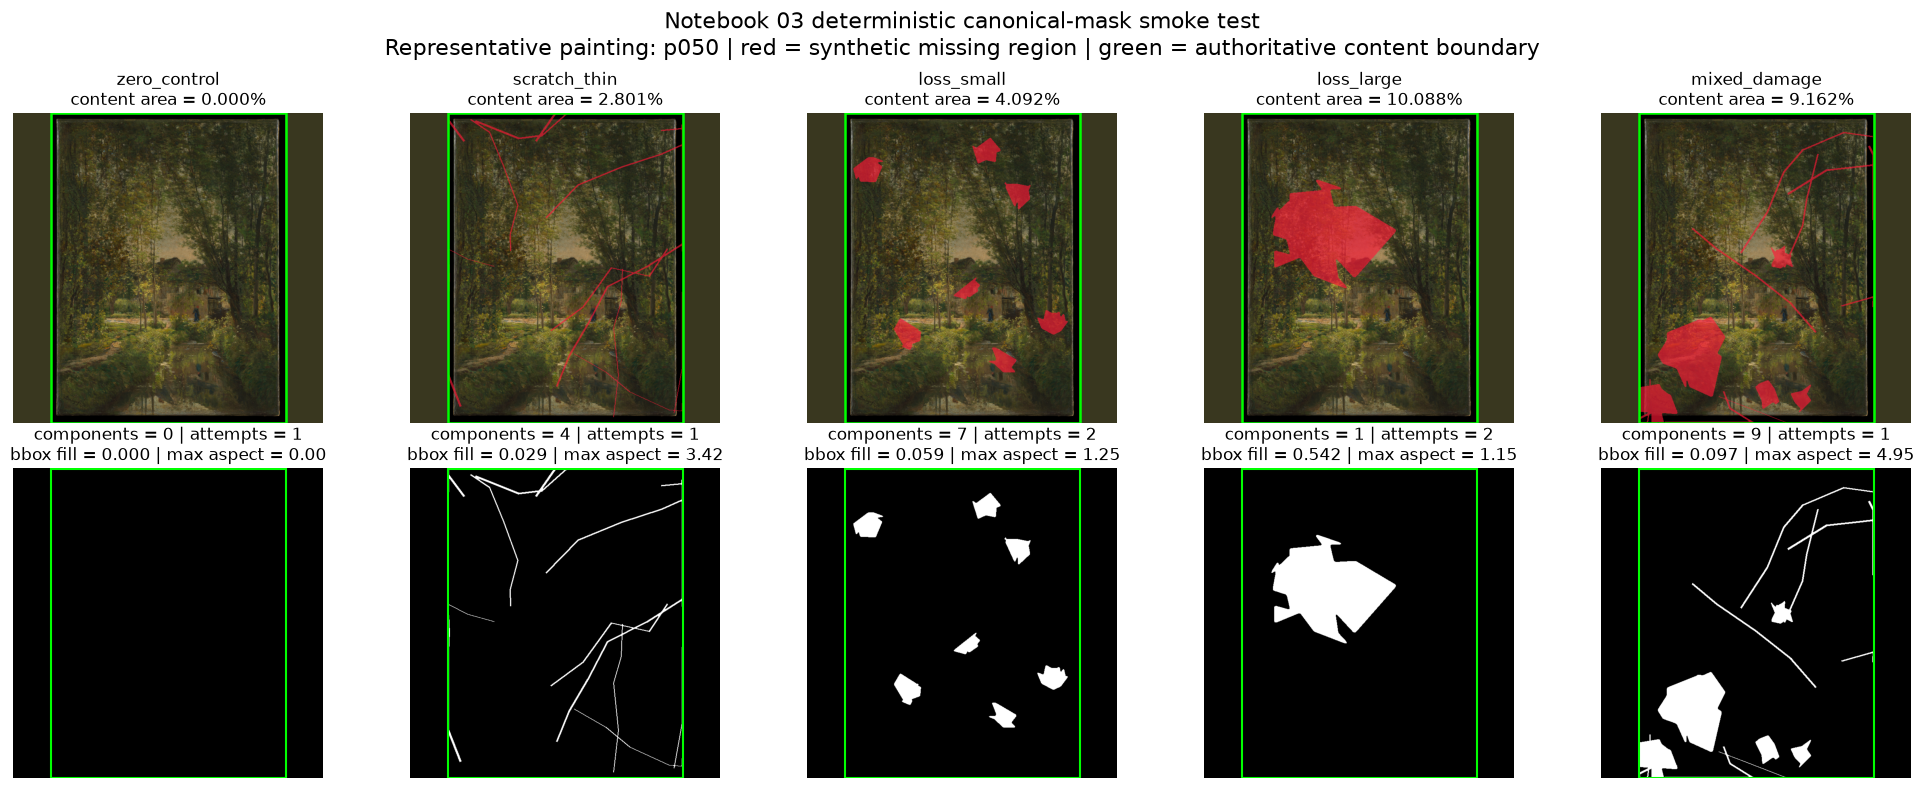

Batch 3 completed successfully.
Separate smoke checks: 8
Consolidated checks remain: 22
No output artifact has been written.
Next approved stage: Batch 4 - full 250-mask controlled execution.


In [7]:
# ---------------------------------------------------------------------------
# Eight separate smoke-test checks
# ---------------------------------------------------------------------------

SMOKE_VALIDATION = ValidationCollector()
SMOKE_VALIDATION_STAGE = "representative_smoke"


# 1. Deterministic representative selection

selection_rule = mask_config[
    "smoke"
]["selection_rule"]

selection_passed = (
    len(smoke_selection_df) == 1
    and smoke_selection_df[
        "painting_id"
    ].nunique()
    == 1
    and smoke_selection_deterministic
    and np.isclose(
        observed_selection_distance,
        minimum_selection_distance,
        rtol=0,
        atol=1e-12,
    )
    and selection_rule
    == (
        "closest_to_median_content_area_fraction"
        "_then_dataset_sort_index"
    )
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="deterministic_selection",
    check_description=(
        "Smoke selection deterministically chooses one painting "
        "nearest the median content-area fraction."
    ),
    severity="blocking",
    expected={
        "painting_count": 1,
        "unique_painting_ids": 1,
        "repeat_selection_matches": True,
        "minimum_distance_selected": True,
        "selection_rule": (
            "closest_to_median_content_area_fraction"
            "_then_dataset_sort_index"
        ),
    },
    observed={
        "painting_count": len(
            smoke_selection_df
        ),
        "painting_id": SMOKE_PAINTING_ID,
        "unique_painting_ids": int(
            smoke_selection_df[
                "painting_id"
            ].nunique()
        ),
        "repeat_selection_matches": (
            smoke_selection_deterministic
        ),
        "content_fraction_median": (
            content_fraction_median
        ),
        "observed_distance": (
            observed_selection_distance
        ),
        "minimum_distance": (
            minimum_selection_distance
        ),
        "selection_rule": selection_rule,
    },
    passed=selection_passed,
)


# 2. Complete five-family generation

observed_smoke_families = (
    smoke_masks_df["mask_type"]
    .astype(str)
    .tolist()
)

family_generation_passed = (
    len(smoke_masks_df)
    == EXPECTED_FAMILY_COUNT
    and observed_smoke_families
    == list(SUPPORTED_MASK_TYPES)
    and smoke_masks_df[
        "mask_type"
    ].nunique()
    == EXPECTED_FAMILY_COUNT
    and smoke_masks_df[
        "mask_id"
    ].nunique()
    == EXPECTED_FAMILY_COUNT
    and smoke_masks_df[
        "case_id"
    ].nunique()
    == EXPECTED_FAMILY_COUNT
    and all(
        result.image.size == (768, 768)
        and result.image.mode == "L"
        for result in smoke_case_results.values()
    )
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="family_generation",
    check_description=(
        "The representative painting produces exactly one "
        "768 × 768 grayscale mask from each canonical family."
    ),
    severity="blocking",
    expected={
        "family_count": EXPECTED_FAMILY_COUNT,
        "families": list(SUPPORTED_MASK_TYPES),
        "unique_mask_ids": EXPECTED_FAMILY_COUNT,
        "unique_case_ids": EXPECTED_FAMILY_COUNT,
        "size": [768, 768],
        "mode": "L",
    },
    observed={
        "family_count": len(
            smoke_masks_df
        ),
        "families": observed_smoke_families,
        "unique_mask_ids": int(
            smoke_masks_df[
                "mask_id"
            ].nunique()
        ),
        "unique_case_ids": int(
            smoke_masks_df[
                "case_id"
            ].nunique()
        ),
        "sizes": sorted(
            {
                result.image.size
                for result
                in smoke_case_results.values()
            }
        ),
        "modes": sorted(
            {
                result.image.mode
                for result
                in smoke_case_results.values()
            }
        ),
    },
    passed=family_generation_passed,
)


# 3. Binary pixel values and encoding

binary_failures = (
    smoke_masks_df.loc[
        ~smoke_masks_df[
            "binary_values_valid"
        ],
        [
            "mask_type",
            "observed_unique_values",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

zero_unique_values = (
    smoke_masks_df.loc[
        smoke_masks_df["mask_type"]
        == "zero_control",
        "observed_unique_values",
    ].iloc[0]
)

nonzero_unique_value_failures = (
    smoke_masks_df.loc[
        (
            smoke_masks_df["mask_type"]
            != "zero_control"
        )
        & (
            smoke_masks_df[
                "observed_unique_values"
            ].map(
                lambda values: values
                != [0, 255]
            )
        ),
        [
            "mask_type",
            "observed_unique_values",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

binary_encoding_passed = (
    not binary_failures
    and zero_unique_values == [0]
    and not nonzero_unique_value_failures
    and smoke_masks_df[
        "mask_unique_values"
    ].isin(
        {
            "0",
            "0|255",
        }
    ).all()
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="binary_encoding",
    check_description=(
        "Every in-memory mask contains only exact values 0 and 255; "
        "the zero control contains only 0."
    ),
    severity="blocking",
    expected={
        "allowed_values": [0, 255],
        "zero_control_values": [0],
        "nonzero_family_values": [0, 255],
        "failures": 0,
    },
    observed={
        "values_by_family": {
            row["mask_type"]: (
                row["observed_unique_values"]
            )
            for row in smoke_masks_df[
                [
                    "mask_type",
                    "observed_unique_values",
                ]
            ].to_dict(
                orient="records"
            )
        },
        "binary_failures": binary_failures,
        "nonzero_value_failures": (
            nonzero_unique_value_failures
        ),
    },
    passed=binary_encoding_passed,
)


# 4. Content-only support and zero padding overlap

content_bbox_columns = (
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
)

content_bbox_matches = (
    smoke_masks_df.loc[
        :,
        list(content_bbox_columns),
    ]
    .astype(int)
    .eq(
        pd.Series(
            SMOKE_CONTENT_BBOX,
            index=content_bbox_columns,
        ),
        axis="columns",
    )
    .all(
        axis=1
    )
)

content_support_failures = (
    smoke_masks_df.loc[
        ~(
            smoke_masks_df[
                "content_only_valid"
            ]
            & smoke_masks_df[
                "padding_overlap_pixels"
            ].eq(0)
            & smoke_masks_df[
                "damaged_pixel_count"
            ].eq(
                smoke_masks_df[
                    "damaged_content_pixel_count"
                ]
            )
            & content_bbox_matches
        ),
        [
            "mask_type",
            "damaged_pixel_count",
            "damaged_content_pixel_count",
            "padding_overlap_pixels",
            "content_only_valid",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

content_support_passed = (
    not content_support_failures
    and int(
        smoke_content_region.pixel_count
    )
    == int(
        smoke_source_row[
            "content_area_pixels"
        ]
    )
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="content_only_support",
    check_description=(
        "Every damaged pixel lies within the authoritative Notebook 02 "
        "content region and no mask overlaps padding."
    ),
    severity="blocking",
    expected={
        "support_failures": 0,
        "padding_overlap_pixels": 0,
        "content_geometry_match": True,
    },
    observed={
        "support_failures": (
            content_support_failures
        ),
        "content_region_pixels": int(
            smoke_content_region.pixel_count
        ),
        "upstream_content_pixels": int(
            smoke_source_row[
                "content_area_pixels"
            ]
        ),
        "padding_overlap_by_family": (
            smoke_masks_df.set_index(
                "mask_type"
            )[
                "padding_overlap_pixels"
            ].astype(int).to_dict()
        ),
    },
    passed=content_support_passed,
)


# 5. Area, retry, and zero/non-zero rules

zero_row = smoke_masks_df.loc[
    smoke_masks_df["mask_type"]
    == "zero_control"
].iloc[0]

nonzero_rows = smoke_masks_df.loc[
    smoke_masks_df["mask_type"]
    != "zero_control"
]

area_retry_failures = (
    smoke_masks_df.loc[
        ~(
            smoke_masks_df[
                "area_within_target_tolerance"
            ]
            & smoke_masks_df[
                "zero_control_rule_valid"
            ]
            & smoke_masks_df[
                "generation_attempts"
            ].astype(int).between(
                1,
                int(
                    mask_config[
                        "generator"
                    ][
                        "maximum_generation_attempts"
                    ]
                ),
                inclusive="both",
            )
            & smoke_masks_df[
                "distance_to_allowed_range_fraction"
            ].astype(float).eq(0.0)
        ),
        [
            "mask_type",
            "damaged_content_fraction",
            "lower_damaged_content_fraction",
            "target_damaged_content_fraction",
            "upper_damaged_content_fraction",
            "generation_attempts",
            "distance_to_allowed_range_fraction",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

area_retry_passed = (
    not area_retry_failures
    and int(
        zero_row["damaged_pixel_count"]
    ) == 0
    and nonzero_rows[
        "damaged_pixel_count"
    ].astype(int).gt(0).all()
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="area_retry_zero_rules",
    check_description=(
        "All realized areas are within configured bounds, retry limits "
        "are respected, zero control is empty, and other masks are non-empty."
    ),
    severity="blocking",
    expected={
        "area_or_retry_failures": 0,
        "zero_control_pixels": 0,
        "empty_nonzero_masks": 0,
        "maximum_attempts": int(
            mask_config[
                "generator"
            ][
                "maximum_generation_attempts"
            ]
        ),
    },
    observed={
        "area_or_retry_failures": (
            area_retry_failures
        ),
        "zero_control_pixels": int(
            zero_row[
                "damaged_pixel_count"
            ]
        ),
        "empty_nonzero_masks": int(
            nonzero_rows[
                "damaged_pixel_count"
            ].astype(int).eq(0).sum()
        ),
        "attempts_by_family": (
            smoke_masks_df.set_index(
                "mask_type"
            )[
                "generation_attempts"
            ].astype(int).to_dict()
        ),
        "fractions_by_family": (
            smoke_masks_df.set_index(
                "mask_type"
            )[
                "damaged_content_fraction"
            ].astype(float).to_dict()
        ),
    },
    passed=area_retry_passed,
)


# 6. Family morphology and cross-family non-equivalence

family_morphology_failures = (
    smoke_family_validation_df.loc[
        ~smoke_family_validation_df[
            "passed"
        ],
        [
            "mask_type",
            "rule_id",
            "expected",
            "observed",
            "details",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

unique_family_pixel_hashes = int(
    smoke_masks_df[
        "mask_pixel_sha256"
    ].nunique()
)

family_morphology_passed = (
    len(smoke_family_validation_df)
    == EXPECTED_FAMILY_COUNT
    and not family_morphology_failures
    and unique_family_pixel_hashes
    == EXPECTED_FAMILY_COUNT
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="family_morphology",
    check_description=(
        "All configured morphology expectations pass and no two "
        "canonical families are pixel-equivalent."
    ),
    severity="blocking",
    expected={
        "morphology_rule_count": EXPECTED_FAMILY_COUNT,
        "failed_rules": 0,
        "unique_family_pixel_hashes": (
            EXPECTED_FAMILY_COUNT
        ),
    },
    observed={
        "morphology_rule_count": len(
            smoke_family_validation_df
        ),
        "failed_rules": (
            family_morphology_failures
        ),
        "unique_family_pixel_hashes": (
            unique_family_pixel_hashes
        ),
        "family_rules": (
            smoke_family_validation_df[
                [
                    "mask_type",
                    "rule_id",
                    "observed",
                    "passed",
                ]
            ].to_dict(
                orient="records"
            )
        ),
    },
    passed=family_morphology_passed,
)


# 7. Independently recomputed morphology

morphology_reconciliation_failures = (
    smoke_masks_df.loc[
        ~smoke_masks_df[
            "morphology_reconciles"
        ],
        [
            "mask_type",
            "morphology_mismatch_fields",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

morphology_reconciliation_passed = (
    not morphology_reconciliation_failures
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="morphology_reconciliation",
    check_description=(
        "Recorded area, bounding-box, component, aspect, density, "
        "perimeter, compactness, and boundary metrics reconcile "
        "with an independent in-memory calculation."
    ),
    severity="blocking",
    expected="zero morphology reconciliation failures",
    observed=len(
        morphology_reconciliation_failures
    ),
    passed=morphology_reconciliation_passed,
    details=morphology_reconciliation_failures,
)


# 8. Deterministic replay

deterministic_replay_failures = (
    smoke_masks_df.loc[
        ~(
            smoke_masks_df[
                "replay_pixels_match"
            ]
            & smoke_masks_df[
                "replay_metadata_matches"
            ]
            & smoke_masks_df[
                "mask_pixel_sha256"
            ].eq(
                smoke_masks_df[
                    "replay_pixel_sha256"
                ]
            )
        ),
        [
            "mask_type",
            "mask_pixel_sha256",
            "replay_pixel_sha256",
            "replay_pixels_match",
            "replay_metadata_matches",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

deterministic_replay_passed = (
    not deterministic_replay_failures
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="deterministic_replay",
    check_description=(
        "Repeated generation produces identical pixels, seeds, "
        "retry evidence, parameters, and morphology settings."
    ),
    severity="blocking",
    expected="zero deterministic replay failures",
    observed=len(
        deterministic_replay_failures
    ),
    passed=deterministic_replay_passed,
    details=deterministic_replay_failures,
)


# ---------------------------------------------------------------------------
# Validate and display smoke evidence
# ---------------------------------------------------------------------------

smoke_checks_df = (
    SMOKE_VALIDATION.to_dataframe()
)

if len(smoke_checks_df) != 8:
    raise RuntimeError(
        "Batch 3 should produce exactly eight separate smoke checks; "
        f"found {len(smoke_checks_df)}."
    )

print("Batch 3 representative smoke checks:")
display(
    smoke_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nPer-family generation and morphology evidence:")
display(
    smoke_masks_df[
        [
            "mask_type",
            "lower_damaged_content_fraction",
            "target_damaged_content_fraction",
            "upper_damaged_content_fraction",
            "damaged_content_fraction",
            "damaged_full_fraction",
            "generation_attempts",
            "connected_component_count",
            "largest_component_fraction",
            "bbox_fill_ratio",
            "maximum_component_aspect_ratio",
            "mask_perimeter_pixels",
            "mask_compactness",
            "touches_content_boundary",
            "minimum_distance_to_content_boundary_pixels",
            "padding_overlap_pixels",
        ]
    ]
)

print("\nFamily-level morphology expectations:")
display(
    smoke_family_validation_df[
        [
            "mask_type",
            "rule_id",
            "observed",
            "passed",
        ]
    ]
)

SMOKE_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# In-notebook overlay and binary-mask diagnostic
# ---------------------------------------------------------------------------

smoke_figure, smoke_axes = plt.subplots(
    nrows=2,
    ncols=EXPECTED_FAMILY_COUNT,
    figsize=(20, 8),
    squeeze=False,
)

x_min, y_min, x_max, y_max = (
    SMOKE_CONTENT_BBOX
)

for column_index, visual in enumerate(
    smoke_visuals
):
    mask_type = visual["mask_type"]
    mask_array = visual["mask_array"]
    record = visual["record"]

    damaged_pixels = mask_array > 0

    overlay_array = (
        smoke_clean_array.astype(
            np.float32
        )
        .copy()
    )

    overlay_array[
        damaged_pixels
    ] = (
        0.35
        * overlay_array[
            damaged_pixels
        ]
        + 0.65
        * np.array(
            [
                255,
                25,
                55,
            ],
            dtype=np.float32,
        )
    )

    overlay_array = np.clip(
        overlay_array,
        0,
        255,
    ).astype(
        np.uint8
    )

    overlay_axis = smoke_axes[
        0,
        column_index,
    ]

    mask_axis = smoke_axes[
        1,
        column_index,
    ]

    overlay_axis.imshow(
        overlay_array
    )

    overlay_axis.add_patch(
        Rectangle(
            (
                x_min,
                y_min,
            ),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            edgecolor="lime",
            linewidth=1.8,
        )
    )

    overlay_axis.set_title(
        f"{mask_type}\n"
        f"content area = "
        f"{record['damaged_content_fraction']:.3%}"
    )

    mask_axis.imshow(
        mask_array,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    mask_axis.add_patch(
        Rectangle(
            (
                x_min,
                y_min,
            ),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            edgecolor="lime",
            linewidth=1.5,
        )
    )

    mask_axis.set_title(
        f"components = "
        f"{record['connected_component_count']} | "
        f"attempts = "
        f"{record['generation_attempts']}\n"
        f"bbox fill = "
        f"{record['bbox_fill_ratio']:.3f} | "
        f"max aspect = "
        f"{record['maximum_component_aspect_ratio']:.2f}"
    )

    overlay_axis.set_axis_off()
    mask_axis.set_axis_off()

smoke_figure.suptitle(
    "Notebook 03 deterministic canonical-mask smoke test\n"
    f"Representative painting: {SMOKE_PAINTING_ID} | "
    "red = synthetic missing region | "
    "green = authoritative content boundary",
    fontsize=16,
)

smoke_figure.tight_layout()
plt.show()
plt.close(smoke_figure)

print("Batch 3 completed successfully.")
print("Separate smoke checks:", len(smoke_checks_df))
print(
    "Consolidated checks remain:",
    len(VALIDATION.to_dataframe()),
)
print("No output artifact has been written.")
print(
    "Next approved stage: Batch 4 - "
    "full 250-mask controlled execution."
)

## Batch 4 — Full Controlled-50 Canonical-Mask Generation

This batch generates the complete canonical mask collection for all 50 validated paintings.

For every painting and each of the five configured families, it will:

- derive deterministic painting, mask, and retry seeds;
- generate the configured binary missing-region geometry;
- retry within the configured maximum-attempt limit until the area tolerance is met;
- restrict all damage to the authoritative Notebook 02 content region;
- calculate area, bounding-box, component, aspect, density, perimeter, compactness, and boundary evidence;
- save `images/masks/<painting_id>/<mask_type>.png` atomically;
- immediately reload the saved PNG;
- verify its `768 × 768`, grayscale, PNG, and binary encoding contract;
- record normalized mask metadata and runtime evidence in memory.

The 250 PNG files created here are provisional until Batch 5 completes full saved-mask reconciliation, deterministic replay, duplicate detection, and stale/orphan detection.

The canonical `data/masks.csv` table is not persisted until the later persistence batch. No metric table, figure, report, manifest, or validation table is written here.

In [8]:
# ---------------------------------------------------------------------------
# Batch 4 import and execution gates
# ---------------------------------------------------------------------------

from restoration_eval.masks import (
    generate_masks_for_dataset,
)


VALIDATION.raise_for_blocking()
SMOKE_VALIDATION.raise_for_blocking()

FULL_MASK_GENERATION_STARTED_AT_UTC = (
    utc_now_iso()
)

print("Starting full controlled-50 canonical-mask generation.")
print("Paintings:", len(normalized_preprocessed_df))
print("Mask families:", len(SUPPORTED_MASK_TYPES))
print("Expected masks:", EXPECTED_MASK_COUNT)
print(
    "Mask-image directory:",
    to_repo_relative(
        MASK_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ),
)


# ---------------------------------------------------------------------------
# Execute deterministic full mask generation
# ---------------------------------------------------------------------------

mask_generation_result = generate_masks_for_dataset(
    normalized_preprocessed_df,
    mask_config,
    PROJECT_ROOT,
)

canonical_masks_df = (
    mask_generation_result.masks.copy()
)

mask_runtimes_df = (
    mask_generation_result.runtimes.copy()
)

family_validation_df = (
    mask_generation_result.family_validation.copy()
)

FULL_MASK_GENERATION_COMPLETED_AT_UTC = (
    utc_now_iso()
)


# ---------------------------------------------------------------------------
# Immediate execution reconciliation
# ---------------------------------------------------------------------------

ordered_painting_ids = (
    normalized_preprocessed_df.sort_values(
        [
            "dataset_sort_index",
            "painting_id",
        ],
        kind="stable",
    )[
        "painting_id"
    ]
    .astype(str)
    .tolist()
)

expected_case_pairs = [
    (
        painting_id,
        mask_type,
    )
    for painting_id in ordered_painting_ids
    for mask_type in SUPPORTED_MASK_TYPES
]

observed_case_pairs = list(
    canonical_masks_df[
        [
            "painting_id",
            "mask_type",
        ]
    ]
    .astype(str)
    .itertuples(
        index=False,
        name=None,
    )
)

expected_mask_paths = {
    (
        MASK_IMAGE_DIRECTORY
        / painting_id
        / f"{mask_type}.png"
    ).resolve()
    for painting_id, mask_type
    in expected_case_pairs
}

recorded_mask_paths = {
    resolve_repo_path(
        mask_path,
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()
    for mask_path in canonical_masks_df[
        "mask_path"
    ].astype(str)
}

actual_mask_paths = {
    path.resolve()
    for path in MASK_IMAGE_DIRECTORY.rglob("*")
    if path.is_file()
}

missing_after_generation = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        expected_mask_paths
        - actual_mask_paths
    )
)

unexpected_after_generation = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        actual_mask_paths
        - expected_mask_paths
    )
)

recorded_path_mismatches = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        recorded_mask_paths
        ^ expected_mask_paths
    )
)

expected_mask_ids = set(
    canonical_masks_df[
        "mask_id"
    ].astype(str)
)

runtime_mask_ids = set(
    mask_runtimes_df[
        "mask_id"
    ].astype(str)
)

execution_reconciles = (
    len(canonical_masks_df)
    == EXPECTED_MASK_COUNT
    and len(mask_runtimes_df)
    == EXPECTED_MASK_COUNT
    and len(family_validation_df)
    == EXPECTED_FAMILY_COUNT
    and observed_case_pairs
    == expected_case_pairs
    and canonical_masks_df[
        "painting_id"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and canonical_masks_df[
        "mask_type"
    ].nunique()
    == EXPECTED_FAMILY_COUNT
    and canonical_masks_df[
        [
            "painting_id",
            "mask_type",
        ]
    ].duplicated().sum()
    == 0
    and canonical_masks_df[
        "case_id"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and canonical_masks_df[
        "mask_id"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and canonical_masks_df[
        "mask_path"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and mask_runtimes_df[
        "mask_id"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and runtime_mask_ids
    == expected_mask_ids
    and recorded_mask_paths
    == expected_mask_paths
    and not missing_after_generation
    and not unexpected_after_generation
    and not recorded_path_mismatches
    and canonical_masks_df[
        "generation_status"
    ].eq("passed").all()
    and canonical_masks_df[
        "morphology_status"
    ].eq("passed").all()
    and canonical_masks_df[
        "status"
    ].eq("passed").all()
    and family_validation_df[
        "passed"
    ].all()
)

if not execution_reconciles:
    raise RuntimeError(
        "Full canonical-mask generation did not reconcile: "
        f"mask_rows={len(canonical_masks_df)}, "
        f"runtime_rows={len(mask_runtimes_df)}, "
        f"family_checks={len(family_validation_df)}, "
        f"missing={missing_after_generation}, "
        f"unexpected={unexpected_after_generation}, "
        f"recorded_path_mismatches={recorded_path_mismatches}."
    )

print("Full canonical-mask generation completed.")
print(
    "Started:",
    FULL_MASK_GENERATION_STARTED_AT_UTC,
)
print(
    "Completed:",
    FULL_MASK_GENERATION_COMPLETED_AT_UTC,
)
print(
    "Canonical mask rows:",
    len(canonical_masks_df),
)
print(
    "Runtime rows:",
    len(mask_runtimes_df),
)
print(
    "Family morphology checks:",
    len(family_validation_df),
)
print(
    "Saved mask files:",
    len(actual_mask_paths),
)
print(
    "Missing expected files:",
    len(missing_after_generation),
)
print(
    "Unexpected files:",
    len(unexpected_after_generation),
)

Starting full controlled-50 canonical-mask generation.
Paintings: 50
Mask families: 5
Expected masks: 250
Mask-image directory: outputs/03_canonical_mask_generation/images/masks
Full canonical-mask generation completed.
Started: 2026-08-18T11:13:03.750630Z
Completed: 2026-08-18T11:15:43.621299Z
Canonical mask rows: 250
Runtime rows: 250
Family morphology checks: 5
Saved mask files: 250
Missing expected files: 0
Unexpected files: 0


In [9]:
# ---------------------------------------------------------------------------
# Compact provisional execution summaries
# ---------------------------------------------------------------------------

runtime_values = pd.to_numeric(
    mask_runtimes_df[
        "runtime_seconds"
    ],
    errors="raise",
)

runtime_summary_df = pd.DataFrame(
    [
        {
            "mask_count": len(
                mask_runtimes_df
            ),
            "total_runtime_seconds": float(
                runtime_values.sum()
            ),
            "mean_runtime_seconds": float(
                runtime_values.mean()
            ),
            "median_runtime_seconds": float(
                runtime_values.median()
            ),
            "p95_runtime_seconds": float(
                runtime_values.quantile(
                    0.95
                )
            ),
            "minimum_runtime_seconds": float(
                runtime_values.min()
            ),
            "maximum_runtime_seconds": float(
                runtime_values.max()
            ),
        }
    ]
)

mask_family_summary_df = (
    canonical_masks_df.groupby(
        "mask_type",
        sort=False,
        observed=True,
    )
    .agg(
        mask_count=(
            "mask_id",
            "size",
        ),
        minimum_content_fraction=(
            "damaged_content_fraction",
            "min",
        ),
        median_content_fraction=(
            "damaged_content_fraction",
            "median",
        ),
        mean_content_fraction=(
            "damaged_content_fraction",
            "mean",
        ),
        maximum_content_fraction=(
            "damaged_content_fraction",
            "max",
        ),
        median_full_fraction=(
            "damaged_full_fraction",
            "median",
        ),
        mean_generation_attempts=(
            "generation_attempts",
            "mean",
        ),
        maximum_generation_attempts=(
            "generation_attempts",
            "max",
        ),
        median_component_count=(
            "connected_component_count",
            "median",
        ),
        median_largest_component_fraction=(
            "largest_component_fraction",
            "median",
        ),
        median_bbox_fill_ratio=(
            "bbox_fill_ratio",
            "median",
        ),
        median_maximum_component_aspect_ratio=(
            "maximum_component_aspect_ratio",
            "median",
        ),
        median_mask_compactness=(
            "mask_compactness",
            "median",
        ),
        boundary_touch_fraction=(
            "touches_content_boundary",
            "mean",
        ),
        total_padding_overlap_pixels=(
            "padding_overlap_pixels",
            "sum",
        ),
    )
    .reindex(
        SUPPORTED_MASK_TYPES
    )
    .reset_index()
)

attempt_distribution_df = (
    canonical_masks_df.groupby(
        [
            "mask_type",
            "generation_attempts",
        ],
        sort=True,
        observed=True,
    )
    .size()
    .reset_index(
        name="mask_count"
    )
)

saved_size_summary_df = pd.DataFrame(
    [
        {
            "mask_file_count": len(
                actual_mask_paths
            ),
            "total_size_bytes": int(
                canonical_masks_df[
                    "mask_size_bytes"
                ].sum()
            ),
            "mean_size_bytes": float(
                canonical_masks_df[
                    "mask_size_bytes"
                ].mean()
            ),
            "minimum_size_bytes": int(
                canonical_masks_df[
                    "mask_size_bytes"
                ].min()
            ),
            "maximum_size_bytes": int(
                canonical_masks_df[
                    "mask_size_bytes"
                ].max()
            ),
        }
    ]
)

print("Provisional canonical-mask preview:")
display(
    canonical_masks_df[
        [
            "painting_id",
            "mask_type",
            "mask_path",
            "lower_damaged_content_fraction",
            "target_damaged_content_fraction",
            "upper_damaged_content_fraction",
            "damaged_content_fraction",
            "damaged_full_fraction",
            "generation_attempts",
            "connected_component_count",
            "largest_component_fraction",
            "bbox_fill_ratio",
            "maximum_component_aspect_ratio",
            "mask_compactness",
            "touches_content_boundary",
            "minimum_distance_to_content_boundary_pixels",
            "padding_overlap_pixels",
            "mask_size_bytes",
            "generation_status",
            "morphology_status",
            "status",
        ]
    ].head(10)
)

print("\nRuntime summary:")
display(runtime_summary_df)

print("\nPer-family morphology summary:")
display(mask_family_summary_df)

print("\nGeneration-attempt distribution:")
display(attempt_distribution_df)

print("\nFamily-level validation:")
display(
    family_validation_df[
        [
            "mask_type",
            "rule_id",
            "observed",
            "passed",
        ]
    ]
)

print("\nSaved-file size summary:")
display(saved_size_summary_df)

print("Batch 4 completed successfully.")
print(
    "Provisional canonical mask files written:",
    len(actual_mask_paths),
)
print(
    "Consolidated validation checks remain:",
    len(VALIDATION.to_dataframe()),
)
print(
    "No CSV, metric, figure, report, manifest, "
    "or validation artifact has been persisted."
)
print(
    "Next approved stage: Batch 5 - "
    "saved-mask reload, reconciliation, replay, "
    "duplicate, stale, and orphan validation."
)

Provisional canonical-mask preview:


,painting_id,mask_type,mask_path,lower_damaged_content_fraction,target_damaged_content_fraction,upper_damaged_content_fraction,damaged_content_fraction,damaged_full_fraction,generation_attempts,connected_component_count,...,bbox_fill_ratio,maximum_component_aspect_ratio,mask_compactness,touches_content_boundary,minimum_distance_to_content_boundary_pixels,padding_overlap_pixels,mask_size_bytes,generation_status,morphology_status,status
0,p001,zero_control,outputs/03_canonical_mask_generation/images/ma...,0.00,0.000,0.00,0.000000,0.000000,1,0,...,0.000000,0.000000,0.000000,False,-1,0,652,passed,passed,passed
1,p001,scratch_thin,outputs/03_canonical_mask_generation/images/ma...,0.01,0.020,0.03,0.021717,0.018748,1,9,...,0.021717,3.537313,0.001712,True,0,0,6754,passed,passed,passed
2,p001,loss_small,outputs/03_canonical_mask_generation/images/ma...,0.03,0.045,0.06,0.034149,0.029480,1,6,...,0.073808,1.470588,0.054955,False,40,0,3089,passed,passed,passed
3,p001,loss_large,outputs/03_canonical_mask_generation/images/ma...,0.10,0.125,0.15,0.139030,0.120022,1,1,...,0.525358,1.100000,0.273958,False,45,0,3004,passed,passed,passed
4,p001,mixed_damage,outputs/03_canonical_mask_generation/images/ma...,0.08,0.115,0.15,0.094345,0.081446,2,6,...,0.104556,8.750000,0.006179,True,0,0,8042,passed,passed,passed
5,p002,zero_control,outputs/03_canonical_mask_generation/images/ma...,0.00,0.000,0.00,0.000000,0.000000,1,0,...,0.000000,0.000000,0.000000,False,-1,0,652,passed,passed,passed
6,p002,scratch_thin,outputs/03_canonical_mask_generation/images/ma...,0.01,0.020,0.03,0.024328,0.014223,2,5,...,0.026204,17.166667,0.003342,True,0,0,5546,passed,passed,passed
7,p002,loss_small,outputs/03_canonical_mask_generation/images/ma...,0.03,0.045,0.06,0.054444,0.031830,1,6,...,0.084839,1.434783,0.064265,False,12,0,3044,passed,passed,passed
8,p002,loss_large,outputs/03_canonical_mask_generation/images/ma...,0.10,0.125,0.15,0.128425,0.075082,2,1,...,0.535969,1.039007,0.307168,False,36,0,2344,passed,passed,passed
9,p002,mixed_damage,outputs/03_canonical_mask_generation/images/ma...,0.08,0.115,0.15,0.118376,0.069207,1,8,...,0.118376,5.393939,0.006482,True,0,0,7448,passed,passed,passed



Runtime summary:


,mask_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,minimum_runtime_seconds,maximum_runtime_seconds
0,250,159.799673,0.639199,0.367872,2.24827,0.070631,4.699701



Per-family morphology summary:


...


Family-level validation:


,mask_type,rule_id,observed,passed
0,zero_control,zero_control_empty,"{'maximum_pixels': 0, 'maximum_components': 0}",True
1,scratch_thin,scratch_thin_elongated,"{'median_bbox_fill_ratio': 0.0244970255, 'medi...",True
2,loss_small,loss_small_multicomponent,{'median_connected_component_count': 6.0},True
3,loss_large,loss_large_substantially_larger,{'median_fraction_ratio_to_loss_small': 2.8038...,True
4,mixed_damage,mixed_damage_combined_characteristics,"{'median_connected_component_count': 8.0, 'bou...",True



Saved-file size summary:


,mask_file_count,total_size_bytes,mean_size_bytes,minimum_size_bytes,maximum_size_bytes
0,250,985721,3942.884,652,9175


Batch 4 completed successfully.
Provisional canonical mask files written: 250
Consolidated validation checks remain: 22
No CSV, metric, figure, report, manifest, or validation artifact has been persisted.
Next approved stage: Batch 5 - saved-mask reload, reconciliation, replay, duplicate, stale, and orphan validation.


## Batch 5 — Saved-Mask Reload, Reconciliation, and Replay Validation

This batch validates the complete provisional 250-mask collection from disk.

Validation covers:

- exact `canonical_masks.v1` schema compliance;
- expected case cardinality and unique identifiers;
- deterministic `(painting_id, mask_type)` ordering and path construction;
- exact saved-file-set reconciliation;
- saved width, height, mode, and format;
- exact binary pixel values;
- saved SHA-256 reconciliation and stale-file detection;
- zero-control and non-zero-family rules;
- content-only support and zero padding overlap;
- configured damaged-area tolerances;
- reconciliation of saved and recorded morphology;
- full-dataset family morphology expectations;
- deterministic regeneration of all 250 masks;
- duplicate identity detection;
- duplicate non-zero pixel-content detection;
- cross-family geometric-equivalence detection;
- generator, configuration, preset, retry, and seed evidence;
- Notebook 02 foreign-key, checksum, and geometry reconciliation;
- runtime-table alignment and validity.

This batch adds exactly 20 checks to the 22 existing consolidated checks, producing 42 cumulative validation checks.

All validation evidence remains in memory. No CSV, figure, report, manifest, or other canonical artifact is persisted.

In [10]:
# ---------------------------------------------------------------------------
# Batch 5 imports and execution gates
# ---------------------------------------------------------------------------

from restoration_eval.masks import (
    validate_deterministic_replay,
    validate_saved_masks,
)


VALIDATION.raise_for_blocking()
SMOKE_VALIDATION.raise_for_blocking()

SAVED_MASK_VALIDATION_STARTED_AT_UTC = (
    utc_now_iso()
)

print("Starting full saved-mask validation.")
print("Canonical rows:", len(canonical_masks_df))
print("Expected saved masks:", EXPECTED_MASK_COUNT)


# ---------------------------------------------------------------------------
# Reload and reconcile every saved mask
# ---------------------------------------------------------------------------

saved_mask_validation = validate_saved_masks(
    canonical_masks_df,
    mask_config,
    PROJECT_ROOT,
)

saved_mask_checks_df = (
    saved_mask_validation.mask_checks.copy()
)

saved_mask_summary = dict(
    saved_mask_validation.summary
)


# ---------------------------------------------------------------------------
# Regenerate and compare every mask deterministically
# ---------------------------------------------------------------------------

deterministic_replay_df = (
    validate_deterministic_replay(
        canonical_masks_df,
        normalized_preprocessed_df,
        mask_config,
        PROJECT_ROOT,
    )
)

SAVED_MASK_VALIDATION_COMPLETED_AT_UTC = (
    utc_now_iso()
)


# ---------------------------------------------------------------------------
# Exact canonical table schema
# ---------------------------------------------------------------------------

canonical_masks_schema_result = validate_dataframe(
    canonical_masks_df,
    CANONICAL_MASKS_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Deterministic case and path contracts
# ---------------------------------------------------------------------------

observed_case_pairs = list(
    canonical_masks_df[
        [
            "painting_id",
            "mask_type",
        ]
    ]
    .astype(str)
    .itertuples(
        index=False,
        name=None,
    )
)

canonical_path_failures = []

for mask_row in canonical_masks_df.to_dict(
    orient="records"
):
    expected_path = (
        MASK_IMAGE_DIRECTORY
        / str(mask_row["painting_id"])
        / f"{mask_row['mask_type']}.png"
    ).resolve()

    observed_path = resolve_repo_path(
        mask_row["mask_path"],
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()

    expected_filename = (
        f"{mask_row['mask_type']}.png"
    )

    if (
        observed_path != expected_path
        or str(mask_row["mask_filename"])
        != expected_filename
    ):
        canonical_path_failures.append(
            {
                "mask_id": mask_row["mask_id"],
                "painting_id": (
                    mask_row["painting_id"]
                ),
                "mask_type": mask_row["mask_type"],
                "expected_path": (
                    to_repo_relative(
                        expected_path,
                        PROJECT_ROOT,
                    )
                ),
                "observed_path": (
                    mask_row["mask_path"]
                ),
                "expected_filename": (
                    expected_filename
                ),
                "observed_filename": (
                    mask_row["mask_filename"]
                ),
            }
        )


# ---------------------------------------------------------------------------
# Current exact saved-file set
# ---------------------------------------------------------------------------

current_actual_mask_paths = {
    path.resolve()
    for path in MASK_IMAGE_DIRECTORY.rglob("*")
    if path.is_file()
}

current_missing_mask_paths = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        expected_mask_paths
        - current_actual_mask_paths
    )
)

current_unexpected_mask_paths = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        current_actual_mask_paths
        - expected_mask_paths
    )
)


# ---------------------------------------------------------------------------
# Notebook 02 foreign-key and geometry reconciliation
# ---------------------------------------------------------------------------

upstream_mask_contract_df = (
    normalized_preprocessed_df[
        [
            "painting_id",
            "processed_image_id",
            "processed_path",
            "sha256",
            "content_x_min",
            "content_y_min",
            "content_x_max",
            "content_y_max",
            "content_width",
            "content_height",
            "content_area_pixels",
            "padding_area_pixels",
            "canvas_area_pixels",
        ]
    ]
    .rename(
        columns={
            "processed_image_id": (
                "upstream_processed_image_id"
            ),
            "processed_path": (
                "upstream_processed_image_path"
            ),
            "sha256": (
                "upstream_processed_image_sha256"
            ),
            "content_x_min": (
                "upstream_content_x_min"
            ),
            "content_y_min": (
                "upstream_content_y_min"
            ),
            "content_x_max": (
                "upstream_content_x_max"
            ),
            "content_y_max": (
                "upstream_content_y_max"
            ),
            "content_width": (
                "upstream_content_width"
            ),
            "content_height": (
                "upstream_content_height"
            ),
            "content_area_pixels": (
                "upstream_content_area_pixels"
            ),
            "padding_area_pixels": (
                "upstream_padding_area_pixels"
            ),
            "canvas_area_pixels": (
                "upstream_canvas_area_pixels"
            ),
        }
    )
)

mask_upstream_join_df = (
    canonical_masks_df.merge(
        upstream_mask_contract_df,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
)

upstream_match_matrix = pd.DataFrame(
    {
        "processed_image_id": (
            mask_upstream_join_df[
                "processed_image_id"
            ].astype(str)
            == mask_upstream_join_df[
                "upstream_processed_image_id"
            ].astype(str)
        ),
        "processed_image_path": (
            mask_upstream_join_df[
                "processed_image_path"
            ].astype(str)
            == mask_upstream_join_df[
                "upstream_processed_image_path"
            ].astype(str)
        ),
        "processed_image_sha256": (
            mask_upstream_join_df[
                "processed_image_sha256"
            ].astype(str)
            == mask_upstream_join_df[
                "upstream_processed_image_sha256"
            ].astype(str)
        ),
        "content_x_min": (
            mask_upstream_join_df[
                "content_x_min"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_content_x_min"
            ].astype(int)
        ),
        "content_y_min": (
            mask_upstream_join_df[
                "content_y_min"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_content_y_min"
            ].astype(int)
        ),
        "content_x_max": (
            mask_upstream_join_df[
                "content_x_max"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_content_x_max"
            ].astype(int)
        ),
        "content_y_max": (
            mask_upstream_join_df[
                "content_y_max"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_content_y_max"
            ].astype(int)
        ),
        "content_width": (
            mask_upstream_join_df[
                "content_width"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_content_width"
            ].astype(int)
        ),
        "content_height": (
            mask_upstream_join_df[
                "content_height"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_content_height"
            ].astype(int)
        ),
        "content_area_pixels": (
            mask_upstream_join_df[
                "content_area_pixels"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_content_area_pixels"
            ].astype(int)
        ),
        "padding_area_pixels": (
            mask_upstream_join_df[
                "padding_area_pixels"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_padding_area_pixels"
            ].astype(int)
        ),
        "canvas_area_pixels": (
            mask_upstream_join_df[
                "canvas_area_pixels"
            ].astype(int)
            == mask_upstream_join_df[
                "upstream_canvas_area_pixels"
            ].astype(int)
        ),
    }
)

upstream_row_matches = (
    upstream_match_matrix.all(
        axis=1
    )
)

upstream_foreign_key_failures = (
    mask_upstream_join_df.loc[
        ~upstream_row_matches,
        [
            "mask_id",
            "painting_id",
            "mask_type",
        ],
    ]
    .to_dict(
        orient="records"
    )
)


# ---------------------------------------------------------------------------
# Runtime reconciliation
# ---------------------------------------------------------------------------

validated_runtime_values = pd.to_numeric(
    mask_runtimes_df[
        "runtime_seconds"
    ],
    errors="coerce",
)

runtime_mask_id_set = set(
    mask_runtimes_df[
        "mask_id"
    ].astype(str)
)

canonical_mask_id_set = set(
    canonical_masks_df[
        "mask_id"
    ].astype(str)
)

print("Saved-mask validation completed.")
print(
    "Started:",
    SAVED_MASK_VALIDATION_STARTED_AT_UTC,
)
print(
    "Completed:",
    SAVED_MASK_VALIDATION_COMPLETED_AT_UTC,
)
print(
    "Saved-mask check rows:",
    len(saved_mask_checks_df),
)
print(
    "Deterministic replay rows:",
    len(deterministic_replay_df),
)
print(
    "Validation summary:",
    saved_mask_summary,
)

Starting full saved-mask validation.
Canonical rows: 250
Expected saved masks: 250
Saved-mask validation completed.
Started: 2026-08-18T11:15:44.441875Z
Completed: 2026-08-18T11:19:04.066887Z
Saved-mask check rows: 250
Deterministic replay rows: 250
Validation summary: {'missing_mask_count': 0, 'stale_mask_count': 0, 'orphan_mask_count': 0, 'duplicate_identity_group_count': 0, 'duplicate_nonzero_sha256_group_count': 0, 'cross_family_equivalent_pair_count': 0, 'reload_failure_count': 0, 'width_nonconforming_count': 0, 'height_nonconforming_count': 0, 'mode_nonconforming_count': 0, 'format_nonconforming_count': 0, 'nonbinary_mask_count': 0, 'zero_control_failure_count': 0, 'empty_nonzero_mask_count': 0, 'padding_overlap_failure_count': 0, 'area_tolerance_failure_count': 0, 'morphology_reconciliation_failure_count': 0}


In [11]:
# ---------------------------------------------------------------------------
# Twenty consolidated saved-mask validation checks
# ---------------------------------------------------------------------------

SAVED_VALIDATION_STAGE = "saved_mask_validation"


# 1. Exact canonical_masks.v1 schema

canonical_schema_passed = (
    canonical_masks_schema_result.passed
    and not canonical_masks_schema_result.unexpected_columns
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="canonical_masks_schema",
    check_description=(
        "The in-memory canonical mask table satisfies the exact "
        "canonical_masks.v1 schema."
    ),
    severity="blocking",
    expected={
        "schema_version": CANONICAL_MASKS_SCHEMA.version,
        "row_count": EXPECTED_MASK_COUNT,
        "missing_columns": [],
        "unexpected_columns": [],
        "duplicate_primary_key_rows": 0,
    },
    observed={
        "schema_version": (
            canonical_masks_schema_result.schema_version
        ),
        "row_count": (
            canonical_masks_schema_result.row_count
        ),
        "column_count": (
            canonical_masks_schema_result.column_count
        ),
        "missing_columns": list(
            canonical_masks_schema_result.missing_columns
        ),
        "unexpected_columns": list(
            canonical_masks_schema_result.unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            canonical_masks_schema_result
            .duplicate_primary_key_rows
        ),
        "null_counts": dict(
            canonical_masks_schema_result.null_counts
        ),
        "invalid_value_counts": dict(
            canonical_masks_schema_result
            .invalid_value_counts
        ),
    },
    passed=canonical_schema_passed,
)


# 2. Canonical case cardinality and identities

case_cardinality_passed = (
    len(canonical_masks_df)
    == EXPECTED_MASK_COUNT
    and canonical_masks_df[
        "painting_id"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and canonical_masks_df[
        "mask_type"
    ].nunique()
    == EXPECTED_FAMILY_COUNT
    and canonical_masks_df[
        [
            "painting_id",
            "mask_type",
        ]
    ].duplicated().sum()
    == 0
    and canonical_masks_df[
        "case_id"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and canonical_masks_df[
        "mask_id"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and canonical_masks_df[
        "mask_path"
    ].nunique()
    == EXPECTED_MASK_COUNT
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="canonical_case_cardinality",
    check_description=(
        "The table contains exactly one uniquely identified mask "
        "for every configured painting-family pair."
    ),
    severity="blocking",
    expected={
        "row_count": EXPECTED_MASK_COUNT,
        "painting_count": EXPECTED_PAINTING_COUNT,
        "family_count": EXPECTED_FAMILY_COUNT,
        "duplicate_pairs": 0,
        "unique_case_ids": EXPECTED_MASK_COUNT,
        "unique_mask_ids": EXPECTED_MASK_COUNT,
        "unique_mask_paths": EXPECTED_MASK_COUNT,
    },
    observed={
        "row_count": len(canonical_masks_df),
        "painting_count": int(
            canonical_masks_df[
                "painting_id"
            ].nunique()
        ),
        "family_count": int(
            canonical_masks_df[
                "mask_type"
            ].nunique()
        ),
        "duplicate_pairs": int(
            canonical_masks_df[
                [
                    "painting_id",
                    "mask_type",
                ]
            ].duplicated(
                keep=False
            ).sum()
        ),
        "unique_case_ids": int(
            canonical_masks_df[
                "case_id"
            ].nunique()
        ),
        "unique_mask_ids": int(
            canonical_masks_df[
                "mask_id"
            ].nunique()
        ),
        "unique_mask_paths": int(
            canonical_masks_df[
                "mask_path"
            ].nunique()
        ),
    },
    passed=case_cardinality_passed,
)


# 3. Deterministic ordering and path contract

path_contract_passed = (
    observed_case_pairs
    == expected_case_pairs
    and not canonical_path_failures
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="canonical_path_contract",
    check_description=(
        "Case ordering and every painting/family filename and path "
        "match the deterministic canonical layout."
    ),
    severity="blocking",
    expected={
        "ordered_case_count": EXPECTED_MASK_COUNT,
        "path_failures": 0,
        "template": (
            "images/masks/<painting_id>/<mask_type>.png"
        ),
    },
    observed={
        "ordered_case_count": len(
            observed_case_pairs
        ),
        "ordering_matches": (
            observed_case_pairs
            == expected_case_pairs
        ),
        "path_failures": canonical_path_failures,
    },
    passed=path_contract_passed,
)


# 4. Exact saved file set and successful reload

saved_file_set_passed = (
    len(saved_mask_checks_df)
    == EXPECTED_MASK_COUNT
    and saved_mask_checks_df[
        "file_exists"
    ].all()
    and saved_mask_checks_df[
        "reload_passed"
    ].all()
    and saved_mask_checks_df[
        "validation_passed"
    ].all()
    and saved_mask_summary[
        "missing_mask_count"
    ] == 0
    and saved_mask_summary[
        "orphan_mask_count"
    ] == 0
    and not current_missing_mask_paths
    and not current_unexpected_mask_paths
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="saved_file_set",
    check_description=(
        "All 250 expected masks exist, reload successfully, and "
        "the image directory contains no missing or orphaned files."
    ),
    severity="blocking",
    expected={
        "check_rows": EXPECTED_MASK_COUNT,
        "existing_files": EXPECTED_MASK_COUNT,
        "reload_failures": 0,
        "validation_failures": 0,
        "missing_files": 0,
        "orphan_files": 0,
    },
    observed={
        "check_rows": len(
            saved_mask_checks_df
        ),
        "existing_files": int(
            saved_mask_checks_df[
                "file_exists"
            ].sum()
        ),
        "reload_failures": int(
            (
                ~saved_mask_checks_df[
                    "reload_passed"
                ]
            ).sum()
        ),
        "validation_failures": int(
            (
                ~saved_mask_checks_df[
                    "validation_passed"
                ]
            ).sum()
        ),
        "missing_files": (
            current_missing_mask_paths
        ),
        "orphan_files": (
            current_unexpected_mask_paths
        ),
    },
    passed=saved_file_set_passed,
)


# 5. Saved dimensions

dimension_failures = (
    saved_mask_checks_df.loc[
        ~(
            saved_mask_checks_df[
                "width_matches"
            ]
            & saved_mask_checks_df[
                "height_matches"
            ]
        ),
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "issue",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

saved_dimensions_passed = (
    not dimension_failures
    and canonical_masks_df[
        "mask_width"
    ].astype(int).eq(768).all()
    and canonical_masks_df[
        "mask_height"
    ].astype(int).eq(768).all()
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="saved_dimensions",
    check_description=(
        "Every saved mask reloads at exactly 768 × 768 pixels."
    ),
    severity="blocking",
    expected="zero dimension failures",
    observed=len(dimension_failures),
    passed=saved_dimensions_passed,
    details=dimension_failures,
)


# 6. Saved mode and format

mode_format_failures = (
    saved_mask_checks_df.loc[
        ~(
            saved_mask_checks_df[
                "mode_matches"
            ]
            & saved_mask_checks_df[
                "format_matches"
            ]
        ),
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "issue",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

mode_format_passed = (
    not mode_format_failures
    and canonical_masks_df[
        "mask_mode"
    ].eq("L").all()
    and canonical_masks_df[
        "mask_format"
    ].eq("PNG").all()
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="saved_mode_format",
    check_description=(
        "Every saved mask reloads as grayscale mode L and PNG."
    ),
    severity="blocking",
    expected={
        "mode": "L",
        "format": "PNG",
        "failures": 0,
    },
    observed={
        "failures": mode_format_failures,
    },
    passed=mode_format_passed,
)


# 7. Exact binary values

binary_failures = (
    saved_mask_checks_df.loc[
        ~saved_mask_checks_df[
            "binary_values_valid"
        ],
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "issue",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

saved_binary_passed = (
    not binary_failures
    and saved_mask_summary[
        "nonbinary_mask_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="saved_binary_values",
    check_description=(
        "Every reloaded mask contains only exact binary values 0 and 255."
    ),
    severity="blocking",
    expected="zero non-binary masks",
    observed=saved_mask_summary[
        "nonbinary_mask_count"
    ],
    passed=saved_binary_passed,
    details=binary_failures,
)


# 8. Saved checksum and stale-file reconciliation

checksum_failures = (
    saved_mask_checks_df.loc[
        ~saved_mask_checks_df[
            "checksum_matches"
        ],
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "mask_path",
            "issue",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

saved_checksums_passed = (
    not checksum_failures
    and saved_mask_summary[
        "stale_mask_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="saved_checksums",
    check_description=(
        "Every current PNG SHA-256 matches its recorded checksum "
        "and no stale mask is present."
    ),
    severity="blocking",
    expected="zero checksum or stale-file failures",
    observed=saved_mask_summary[
        "stale_mask_count"
    ],
    passed=saved_checksums_passed,
    details=checksum_failures,
)


# 9. Zero-control and non-zero-family rules

zero_nonzero_failures = (
    saved_mask_checks_df.loc[
        ~saved_mask_checks_df[
            "zero_control_rule_valid"
        ],
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "issue",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

zero_nonzero_passed = (
    not zero_nonzero_failures
    and saved_mask_summary[
        "zero_control_failure_count"
    ] == 0
    and saved_mask_summary[
        "empty_nonzero_mask_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="zero_nonzero_rule",
    check_description=(
        "All zero controls are empty and every non-zero family "
        "contains damaged pixels."
    ),
    severity="blocking",
    expected={
        "zero_control_failures": 0,
        "empty_nonzero_masks": 0,
    },
    observed={
        "zero_control_failures": (
            saved_mask_summary[
                "zero_control_failure_count"
            ]
        ),
        "empty_nonzero_masks": (
            saved_mask_summary[
                "empty_nonzero_mask_count"
            ]
        ),
    },
    passed=zero_nonzero_passed,
    details=zero_nonzero_failures,
)


# 10. Content-only support

content_support_failures = (
    saved_mask_checks_df.loc[
        ~saved_mask_checks_df[
            "content_only_valid"
        ],
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "issue",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

content_only_passed = (
    not content_support_failures
    and saved_mask_summary[
        "padding_overlap_failure_count"
    ] == 0
    and canonical_masks_df[
        "padding_overlap_pixels"
    ].astype(int).eq(0).all()
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="content_only_rule",
    check_description=(
        "Every saved damaged pixel remains within painting content "
        "and no mask overlaps technical padding."
    ),
    severity="blocking",
    expected="zero padding-overlap failures",
    observed=saved_mask_summary[
        "padding_overlap_failure_count"
    ],
    passed=content_only_passed,
    details=content_support_failures,
)


# 11. Configured area tolerances

area_tolerance_failures = (
    saved_mask_checks_df.loc[
        ~saved_mask_checks_df[
            "area_within_target_tolerance"
        ],
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "issue",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

area_tolerance_passed = (
    not area_tolerance_failures
    and saved_mask_summary[
        "area_tolerance_failure_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="area_tolerance",
    check_description=(
        "Every reloaded mask remains within its configured "
        "damaged-content fraction bounds."
    ),
    severity="blocking",
    expected="zero area-tolerance failures",
    observed=saved_mask_summary[
        "area_tolerance_failure_count"
    ],
    passed=area_tolerance_passed,
    details=area_tolerance_failures,
)


# 12. Saved morphology reconciliation

morphology_failures = (
    saved_mask_checks_df.loc[
        ~saved_mask_checks_df[
            "morphology_reconciles"
        ],
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "issue",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

saved_morphology_passed = (
    not morphology_failures
    and saved_mask_summary[
        "morphology_reconciliation_failure_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="morphology_reconciliation",
    check_description=(
        "Reloaded area, bounding-box, component, perimeter, "
        "compactness, and boundary evidence matches recorded metadata."
    ),
    severity="blocking",
    expected="zero morphology reconciliation failures",
    observed=saved_mask_summary[
        "morphology_reconciliation_failure_count"
    ],
    passed=saved_morphology_passed,
    details=morphology_failures,
)


# 13. Full-dataset family morphology

family_morphology_failures = (
    family_validation_df.loc[
        ~family_validation_df[
            "passed"
        ],
        [
            "mask_type",
            "rule_id",
            "expected",
            "observed",
            "details",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

full_family_morphology_passed = (
    len(family_validation_df)
    == EXPECTED_FAMILY_COUNT
    and not family_morphology_failures
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="family_morphology",
    check_description=(
        "All five full-dataset family morphology expectations pass."
    ),
    severity="blocking",
    expected={
        "rule_count": EXPECTED_FAMILY_COUNT,
        "failed_rules": 0,
    },
    observed={
        "rule_count": len(
            family_validation_df
        ),
        "failed_rules": family_morphology_failures,
    },
    passed=full_family_morphology_passed,
)


# 14. Full deterministic replay

replay_failures = (
    deterministic_replay_df.loc[
        ~deterministic_replay_df[
            "replay_passed"
        ],
        [
            "mask_id",
            "painting_id",
            "mask_type",
            "pixels_equal",
            "metadata_equal",
            "saved_pixel_sha256",
            "replay_pixel_sha256",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

deterministic_replay_passed = (
    len(deterministic_replay_df)
    == EXPECTED_MASK_COUNT
    and deterministic_replay_df[
        "mask_id"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and not replay_failures
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="deterministic_replay",
    check_description=(
        "All 250 masks regenerate with identical pixels, seeds, "
        "retry evidence, and generator parameters."
    ),
    severity="blocking",
    expected={
        "replay_rows": EXPECTED_MASK_COUNT,
        "replay_failures": 0,
    },
    observed={
        "replay_rows": len(
            deterministic_replay_df
        ),
        "replay_failures": replay_failures,
    },
    passed=deterministic_replay_passed,
)


# 15. Duplicate identity detection

duplicate_identity_passed = (
    saved_mask_summary[
        "duplicate_identity_group_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="duplicate_identity",
    check_description=(
        "No duplicate case ID, mask ID, or canonical mask path exists."
    ),
    severity="blocking",
    expected=0,
    observed=saved_mask_summary[
        "duplicate_identity_group_count"
    ],
    passed=duplicate_identity_passed,
)


# 16. Duplicate non-zero pixel-content detection

duplicate_nonzero_passed = (
    saved_mask_summary[
        "duplicate_nonzero_sha256_group_count"
    ] == 0
    and not saved_mask_validation[
        "duplicate_nonzero_sha256_groups"
    ]
    if isinstance(
        saved_mask_validation,
        dict,
    )
    else (
        saved_mask_summary[
            "duplicate_nonzero_sha256_group_count"
        ] == 0
        and not saved_mask_validation
        .duplicate_nonzero_sha256_groups
    )
)

duplicate_nonzero_groups = (
    saved_mask_validation.get(
        "duplicate_nonzero_sha256_groups",
        (),
    )
    if isinstance(
        saved_mask_validation,
        dict,
    )
    else saved_mask_validation
    .duplicate_nonzero_sha256_groups
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="duplicate_nonzero_pixels",
    check_description=(
        "No two non-zero masks have identical saved pixel content."
    ),
    severity="blocking",
    expected=0,
    observed=saved_mask_summary[
        "duplicate_nonzero_sha256_group_count"
    ],
    passed=duplicate_nonzero_passed,
    details=list(duplicate_nonzero_groups),
)


# 17. Cross-family geometric equivalence

cross_family_pairs = (
    saved_mask_validation.get(
        "cross_family_equivalent_pairs",
        (),
    )
    if isinstance(
        saved_mask_validation,
        dict,
    )
    else saved_mask_validation
    .cross_family_equivalent_pairs
)

cross_family_passed = (
    saved_mask_summary[
        "cross_family_equivalent_pair_count"
    ] == 0
    and not cross_family_pairs
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="cross_family_equivalence",
    check_description=(
        "No painting has two canonical families with identical pixels."
    ),
    severity="blocking",
    expected=0,
    observed=saved_mask_summary[
        "cross_family_equivalent_pair_count"
    ],
    passed=cross_family_passed,
    details=list(cross_family_pairs),
)


# 18. Generator, configuration, preset, retry, and seed evidence

painting_seed_counts = (
    canonical_masks_df.groupby(
        "painting_id",
        sort=False,
    )[
        "painting_seed"
    ].nunique()
)

generator_seed_passed = (
    canonical_masks_df[
        "generator_name"
    ].eq(
        mask_config[
            "generator"
        ]["name"]
    ).all()
    and canonical_masks_df[
        "generator_version"
    ].eq(
        mask_config[
            "generator"
        ]["version"]
    ).all()
    and canonical_masks_df[
        "config_schema_version"
    ].eq(
        mask_config[
            "config_schema_version"
        ]
    ).all()
    and canonical_masks_df[
        "config_version"
    ].eq(
        mask_config[
            "config_version"
        ]
    ).all()
    and canonical_masks_df[
        "seed_scheme_version"
    ].eq(
        mask_config[
            "generator"
        ]["seed_scheme_version"]
    ).all()
    and canonical_masks_df[
        "global_seed"
    ].astype(int).eq(
        int(
            mask_config[
                "generator"
            ]["global_seed"]
        )
    ).all()
    and painting_seed_counts.eq(1).all()
    and canonical_masks_df[
        "painting_seed"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and canonical_masks_df[
        "mask_seed"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and canonical_masks_df[
        "generation_attempts"
    ].astype(int).between(
        1,
        int(
            mask_config[
                "generator"
            ][
                "maximum_generation_attempts"
            ]
        ),
        inclusive="both",
    ).all()
    and canonical_masks_df[
        "distance_to_allowed_range_fraction"
    ].astype(float).eq(0.0).all()
    and canonical_masks_df[
        "generator_parameters"
    ].astype(str).str.len().gt(2).all()
    and canonical_masks_df[
        "morphology_settings"
    ].astype(str).str.len().gt(2).all()
    and canonical_masks_df[
        "issue"
    ].fillna("").astype(str).eq("").all()
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="generator_seed_contract",
    check_description=(
        "Generator, configuration, preset, retry, and hierarchical "
        "seed evidence is complete and internally consistent."
    ),
    severity="blocking",
    expected={
        "generator_version": GENERATOR_VERSION,
        "config_version": mask_config[
            "config_version"
        ],
        "painting_seeds": EXPECTED_PAINTING_COUNT,
        "mask_seeds": EXPECTED_MASK_COUNT,
        "maximum_attempts": int(
            mask_config[
                "generator"
            ][
                "maximum_generation_attempts"
            ]
        ),
        "range_distance_failures": 0,
        "issues": 0,
    },
    observed={
        "generator_versions": sorted(
            canonical_masks_df[
                "generator_version"
            ].astype(str).unique().tolist()
        ),
        "config_versions": sorted(
            canonical_masks_df[
                "config_version"
            ].astype(str).unique().tolist()
        ),
        "painting_seeds": int(
            canonical_masks_df[
                "painting_seed"
            ].nunique()
        ),
        "mask_seeds": int(
            canonical_masks_df[
                "mask_seed"
            ].nunique()
        ),
        "maximum_attempts_observed": int(
            canonical_masks_df[
                "generation_attempts"
            ].max()
        ),
        "range_distance_failures": int(
            canonical_masks_df[
                "distance_to_allowed_range_fraction"
            ].astype(float).ne(0.0).sum()
        ),
        "issues": int(
            canonical_masks_df[
                "issue"
            ].fillna("").astype(str).ne("").sum()
        ),
    },
    passed=generator_seed_passed,
)


# 19. Notebook 02 foreign keys and content geometry

upstream_foreign_keys_passed = (
    len(mask_upstream_join_df)
    == EXPECTED_MASK_COUNT
    and not upstream_foreign_key_failures
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="upstream_foreign_keys",
    check_description=(
        "Every mask preserves the Notebook 02 image identifier, "
        "path, checksum, canvas, and authoritative content geometry."
    ),
    severity="blocking",
    expected={
        "joined_rows": EXPECTED_MASK_COUNT,
        "mismatched_rows": 0,
    },
    observed={
        "joined_rows": len(
            mask_upstream_join_df
        ),
        "mismatched_rows": len(
            upstream_foreign_key_failures
        ),
        "field_failure_counts": {
            column: int(
                (~upstream_match_matrix[column]).sum()
            )
            for column in upstream_match_matrix.columns
        },
    },
    passed=upstream_foreign_keys_passed,
    details=upstream_foreign_key_failures,
)


# 20. Runtime-table alignment and validity

runtime_contract_passed = (
    len(mask_runtimes_df)
    == EXPECTED_MASK_COUNT
    and mask_runtimes_df[
        "mask_id"
    ].nunique()
    == EXPECTED_MASK_COUNT
    and runtime_mask_id_set
    == canonical_mask_id_set
    and validated_runtime_values.notna().all()
    and np.isfinite(
        validated_runtime_values
    ).all()
    and validated_runtime_values.ge(0).all()
)

VALIDATION.add(
    validation_stage=SAVED_VALIDATION_STAGE,
    check_id="runtime_contract",
    check_description=(
        "Runtime evidence contains one finite non-negative value "
        "for every canonical mask and no unrelated IDs."
    ),
    severity="blocking",
    expected={
        "runtime_rows": EXPECTED_MASK_COUNT,
        "unique_mask_ids": EXPECTED_MASK_COUNT,
        "missing_or_extra_ids": 0,
        "invalid_runtime_values": 0,
    },
    observed={
        "runtime_rows": len(
            mask_runtimes_df
        ),
        "unique_mask_ids": int(
            mask_runtimes_df[
                "mask_id"
            ].nunique()
        ),
        "missing_runtime_ids": sorted(
            canonical_mask_id_set
            - runtime_mask_id_set
        ),
        "extra_runtime_ids": sorted(
            runtime_mask_id_set
            - canonical_mask_id_set
        ),
        "invalid_runtime_values": int(
            (
                validated_runtime_values.isna()
                | ~np.isfinite(
                    validated_runtime_values
                )
                | validated_runtime_values.lt(0)
            ).sum()
        ),
    },
    passed=runtime_contract_passed,
)


# ---------------------------------------------------------------------------
# Validate and display Batch 5 evidence
# ---------------------------------------------------------------------------

cumulative_checks_df = VALIDATION.to_dataframe()

batch5_checks_df = cumulative_checks_df.loc[
    cumulative_checks_df["validation_stage"]
    == SAVED_VALIDATION_STAGE
].reset_index(drop=True)

if len(batch5_checks_df) != 20:
    raise RuntimeError(
        "Batch 5 should add exactly 20 saved-mask checks; "
        f"found {len(batch5_checks_df)}."
    )

if len(cumulative_checks_df) != 42:
    raise RuntimeError(
        "Batches 1, 2, and 5 should contain exactly "
        "42 cumulative checks; "
        f"found {len(cumulative_checks_df)}."
    )

print("Batch 5 saved-mask validation checks:")
display(
    batch5_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nSaved-mask validation summary:")
display(
    pd.DataFrame(
        [
            saved_mask_summary
        ]
    )
)

replay_family_summary_df = (
    deterministic_replay_df.groupby(
        "mask_type",
        sort=False,
        observed=True,
    )
    .agg(
        replay_rows=(
            "mask_id",
            "size",
        ),
        pixel_matches=(
            "pixels_equal",
            "sum",
        ),
        metadata_matches=(
            "metadata_equal",
            "sum",
        ),
        replay_passes=(
            "replay_passed",
            "sum",
        ),
    )
    .reindex(
        SUPPORTED_MASK_TYPES
    )
    .reset_index()
)

print("\nDeterministic replay summary by family:")
display(replay_family_summary_df)

print("\nFull-dataset morphology expectations:")
display(
    family_validation_df[
        [
            "mask_type",
            "rule_id",
            "observed",
            "passed",
        ]
    ]
)

VALIDATION.raise_for_blocking()

print("\nBatch 5 completed successfully.")
print("Batch 5 checks:", len(batch5_checks_df))
print("Cumulative checks:", len(cumulative_checks_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print(
    "Deterministic replay passes:",
    int(
        deterministic_replay_df[
            "replay_passed"
        ].sum()
    ),
    "/",
    len(deterministic_replay_df),
)
print("No canonical table or report has been persisted.")
print(
    "Next approved stage: Batch 6 - "
    "canonical audit, morphology figures, examples, "
    "and protocol generation."
)

Batch 5 saved-mask validation checks:


,check_id,severity,expected,observed,passed
0,canonical_masks_schema,blocking,"{""duplicate_primary_key_rows"": 0, ""missing_col...","{""column_count"": 89, ""duplicate_primary_key_ro...",True
1,canonical_case_cardinality,blocking,"{""duplicate_pairs"": 0, ""family_count"": 5, ""pai...","{""duplicate_pairs"": 0, ""family_count"": 5, ""pai...",True
2,canonical_path_contract,blocking,"{""ordered_case_count"": 250, ""path_failures"": 0...","{""ordered_case_count"": 250, ""ordering_matches""...",True
3,saved_file_set,blocking,"{""check_rows"": 250, ""existing_files"": 250, ""mi...","{""check_rows"": 250, ""existing_files"": 250, ""mi...",True
4,saved_dimensions,blocking,zero dimension failures,0,True
5,saved_mode_format,blocking,"{""failures"": 0, ""format"": ""PNG"", ""mode"": ""L""}","{""failures"": []}",True
6,saved_binary_values,blocking,zero non-binary masks,0,True
7,saved_checksums,blocking,zero checksum or stale-file failures,0,True
8,zero_nonzero_rule,blocking,"{""empty_nonzero_masks"": 0, ""zero_control_failu...","{""empty_nonzero_masks"": 0, ""zero_control_failu...",True
9,content_only_rule,blocking,zero padding-overlap failures,0,True



Saved-mask validation summary:


,missing_mask_count,stale_mask_count,orphan_mask_count,duplicate_identity_group_count,duplicate_nonzero_sha256_group_count,cross_family_equivalent_pair_count,reload_failure_count,width_nonconforming_count,height_nonconforming_count,mode_nonconforming_count,format_nonconforming_count,nonbinary_mask_count,zero_control_failure_count,empty_nonzero_mask_count,padding_overlap_failure_count,area_tolerance_failure_count,morphology_reconciliation_failure_count
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Deterministic replay summary by family:


,mask_type,replay_rows,pixel_matches,metadata_matches,replay_passes
0,zero_control,50,50,50,50
1,scratch_thin,50,50,50,50
2,loss_small,50,50,50,50
3,loss_large,50,50,50,50
4,mixed_damage,50,50,50,50



Full-dataset morphology expectations:


,mask_type,rule_id,observed,passed
0,zero_control,zero_control_empty,"{'maximum_pixels': 0, 'maximum_components': 0}",True
1,scratch_thin,scratch_thin_elongated,"{'median_bbox_fill_ratio': 0.0244970255, 'medi...",True
2,loss_small,loss_small_multicomponent,{'median_connected_component_count': 6.0},True
3,loss_large,loss_large_substantially_larger,{'median_fraction_ratio_to_loss_small': 2.8038...,True
4,mixed_damage,mixed_damage_combined_characteristics,"{'median_connected_component_count': 8.0, 'bou...",True



Batch 5 completed successfully.
Batch 5 checks: 20
Cumulative checks: 42
Blocking failures: 0
Deterministic replay passes: 250 / 250
No canonical table or report has been persisted.
Next approved stage: Batch 6 - canonical audit, morphology figures, examples, and protocol generation.


## Batch 6 — Canonical Audit, Morphology Figures, Examples, and Protocol

This batch constructs the remaining scientific and reporting evidence in memory.

It produces:

- the exact 105-row `mask_audit.v1` table;
- 30 global generation, filesystem, validation, replay, and runtime metrics;
- 12 morphology metrics for each of the five canonical mask families;
- all 10 pairwise family-equivalence comparisons;
- five family-level morphology-expectation records;
- a canonical morphology-analysis figure;
- a deterministic five-family example figure;
- the canonical binary missing-region protocol report.

Eight final consolidated checks validate:

1. mask-audit schema compliance;
2. exact audit cardinality, section structure, and identifiers;
3. global audit reconciliation;
4. per-family audit reconciliation;
5. pairwise non-equivalence and morphology-expectation evidence;
6. canonical morphology-figure rendering;
7. deterministic example selection, reload, and rendering;
8. protocol completeness, exclusions, and interpretation boundary.

These checks extend the existing 42 consolidated checks to the planned final total of 50.

All new tables, figures, and report content remain in memory until the persistence batch. No new artifact is written here.

In [12]:
# ---------------------------------------------------------------------------
# Batch 6 imports and execution gates
# ---------------------------------------------------------------------------

from IPython.display import Markdown

from restoration_eval.masks import (
    FAMILY_AUDIT_METRICS,
    GLOBAL_AUDIT_METRIC_COUNT,
    build_mask_audit,
    render_mask_protocol,
)


VALIDATION.raise_for_blocking()
SMOKE_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Build the exact normalized 105-row audit
# ---------------------------------------------------------------------------

mask_audit_df = build_mask_audit(
    canonical_masks_df,
    mask_runtimes_df,
    saved_mask_validation,
    deterministic_replay_df,
    family_validation_df,
    mask_config,
)

global_mask_audit_df = (
    mask_audit_df.loc[
        mask_audit_df[
            "audit_section"
        ] == "global"
    ]
    .reset_index(drop=True)
)

family_mask_audit_df = (
    mask_audit_df.loc[
        mask_audit_df[
            "audit_section"
        ] == "mask_family"
    ]
    .reset_index(drop=True)
)

pairwise_mask_audit_df = (
    mask_audit_df.loc[
        mask_audit_df[
            "audit_section"
        ] == "family_comparison"
    ]
    .reset_index(drop=True)
)

expectation_mask_audit_df = (
    mask_audit_df.loc[
        mask_audit_df[
            "audit_section"
        ] == "morphology_expectation"
    ]
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Independent expected global audit values
# ---------------------------------------------------------------------------

expected_global_mask_audit_values = {
    "accepted_input_count": int(
        canonical_masks_df[
            "painting_id"
        ].nunique()
    ),
    "configured_family_count": int(
        len(SUPPORTED_MASK_TYPES)
    ),
    "expected_mask_count": int(
        EXPECTED_MASK_COUNT
    ),
    "generated_mask_count": int(
        len(canonical_masks_df)
    ),
    "saved_mask_file_count": int(
        saved_mask_checks_df[
            "file_exists"
        ].sum()
    ),
    "failed_generation_count": int(
        canonical_masks_df[
            "generation_status"
        ].ne("passed").sum()
    ),
    "missing_mask_count": int(
        saved_mask_summary[
            "missing_mask_count"
        ]
    ),
    "stale_mask_count": int(
        saved_mask_summary[
            "stale_mask_count"
        ]
    ),
    "orphan_mask_count": int(
        saved_mask_summary[
            "orphan_mask_count"
        ]
    ),
    "duplicate_identity_group_count": int(
        saved_mask_summary[
            "duplicate_identity_group_count"
        ]
    ),
    "duplicate_nonzero_sha256_group_count": int(
        saved_mask_summary[
            "duplicate_nonzero_sha256_group_count"
        ]
    ),
    "cross_family_equivalent_pair_count": int(
        saved_mask_summary[
            "cross_family_equivalent_pair_count"
        ]
    ),
    "reload_failure_count": int(
        saved_mask_summary[
            "reload_failure_count"
        ]
    ),
    "width_nonconforming_count": int(
        saved_mask_summary[
            "width_nonconforming_count"
        ]
    ),
    "height_nonconforming_count": int(
        saved_mask_summary[
            "height_nonconforming_count"
        ]
    ),
    "mode_nonconforming_count": int(
        saved_mask_summary[
            "mode_nonconforming_count"
        ]
    ),
    "format_nonconforming_count": int(
        saved_mask_summary[
            "format_nonconforming_count"
        ]
    ),
    "nonbinary_mask_count": int(
        saved_mask_summary[
            "nonbinary_mask_count"
        ]
    ),
    "zero_control_failure_count": int(
        saved_mask_summary[
            "zero_control_failure_count"
        ]
    ),
    "empty_nonzero_mask_count": int(
        saved_mask_summary[
            "empty_nonzero_mask_count"
        ]
    ),
    "padding_overlap_failure_count": int(
        saved_mask_summary[
            "padding_overlap_failure_count"
        ]
    ),
    "area_tolerance_failure_count": int(
        saved_mask_summary[
            "area_tolerance_failure_count"
        ]
    ),
    "morphology_reconciliation_failure_count": int(
        saved_mask_summary[
            "morphology_reconciliation_failure_count"
        ]
    ),
    "family_morphology_failure_count": int(
        (
            ~family_validation_df[
                "passed"
            ]
        ).sum()
    ),
    "deterministic_replay_failure_count": int(
        (
            ~deterministic_replay_df[
                "replay_passed"
            ]
        ).sum()
    ),
    "total_runtime_seconds": float(
        validated_runtime_values.sum()
    ),
    "mean_runtime_seconds": float(
        validated_runtime_values.mean()
    ),
    "median_runtime_seconds": float(
        validated_runtime_values.median()
    ),
    "p95_runtime_seconds": float(
        validated_runtime_values.quantile(
            0.95
        )
    ),
    "maximum_generation_attempts_observed": int(
        canonical_masks_df[
            "generation_attempts"
        ].max()
    ),
}


# ---------------------------------------------------------------------------
# Independent expected per-family audit values
# ---------------------------------------------------------------------------

expected_family_audit_records = []

for mask_type in SUPPORTED_MASK_TYPES:
    family_subset = canonical_masks_df.loc[
        canonical_masks_df[
            "mask_type"
        ] == mask_type
    ]

    distance_values = (
        family_subset[
            "minimum_distance_to_content_boundary_pixels"
        ]
        .replace(
            -1,
            np.nan,
        )
    )

    expected_family_values = {
        "case_count": int(
            len(family_subset)
        ),
        "mean_damaged_content_fraction": float(
            family_subset[
                "damaged_content_fraction"
            ].mean()
        ),
        "std_damaged_content_fraction": float(
            family_subset[
                "damaged_content_fraction"
            ].std(
                ddof=0
            )
        ),
        "median_damaged_content_fraction": float(
            family_subset[
                "damaged_content_fraction"
            ].median()
        ),
        "mean_connected_component_count": float(
            family_subset[
                "connected_component_count"
            ].mean()
        ),
        "median_largest_component_fraction": float(
            family_subset[
                "largest_component_fraction"
            ].median()
        ),
        "median_bbox_fill_ratio": float(
            family_subset[
                "bbox_fill_ratio"
            ].median()
        ),
        "median_maximum_component_aspect_ratio": float(
            family_subset[
                "maximum_component_aspect_ratio"
            ].median()
        ),
        "median_mask_compactness": float(
            family_subset[
                "mask_compactness"
            ].median()
        ),
        "boundary_touch_fraction": float(
            family_subset[
                "touches_content_boundary"
            ].astype(float).mean()
        ),
        "median_distance_to_content_boundary_pixels": (
            float(
                distance_values.median()
            )
            if distance_values.notna().any()
            else -1.0
        ),
        "mean_generation_attempts": float(
            family_subset[
                "generation_attempts"
            ].mean()
        ),
    }

    for metric_name in FAMILY_AUDIT_METRICS:
        expected_family_audit_records.append(
            {
                "group_value": mask_type,
                "metric_name": metric_name,
                "expected_metric_value": (
                    expected_family_values[
                        metric_name
                    ]
                ),
                "expected_denominator": int(
                    len(family_subset)
                ),
            }
        )

expected_family_audit_df = pd.DataFrame(
    expected_family_audit_records
)

family_audit_reconciliation_df = (
    family_mask_audit_df.merge(
        expected_family_audit_df,
        on=[
            "group_value",
            "metric_name",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

family_audit_reconciliation_df[
    "metric_value_matches"
] = np.isclose(
    pd.to_numeric(
        family_audit_reconciliation_df[
            "metric_value"
        ],
        errors="coerce",
    ),
    pd.to_numeric(
        family_audit_reconciliation_df[
            "expected_metric_value"
        ],
        errors="coerce",
    ),
    rtol=0,
    atol=1e-12,
    equal_nan=False,
)

family_audit_reconciliation_df[
    "denominator_matches"
] = (
    pd.to_numeric(
        family_audit_reconciliation_df[
            "denominator"
        ],
        errors="coerce",
    )
    == pd.to_numeric(
        family_audit_reconciliation_df[
            "expected_denominator"
        ],
        errors="coerce",
    )
)


# ---------------------------------------------------------------------------
# Deterministic canonical example selection and reload
# ---------------------------------------------------------------------------

example_selection_df = select_representative_row(
    normalized_preprocessed_df,
    mask_config,
)

repeated_example_selection_df = select_representative_row(
    normalized_preprocessed_df,
    mask_config,
)

example_selection_deterministic = (
    example_selection_df[
        "painting_id"
    ].tolist()
    == repeated_example_selection_df[
        "painting_id"
    ].tolist()
)

example_source_row = (
    example_selection_df.iloc[0]
)

EXAMPLE_PAINTING_ID = str(
    example_source_row["painting_id"]
)

EXAMPLE_CLEAN_IMAGE_PATH = resolve_repo_path(
    example_source_row[
        "processed_path"
    ],
    PROJECT_ROOT,
    must_exist=True,
)

EXAMPLE_CONTENT_BBOX = (
    int(
        example_source_row[
            "content_x_min"
        ]
    ),
    int(
        example_source_row[
            "content_y_min"
        ]
    ),
    int(
        example_source_row[
            "content_x_max"
        ]
    ),
    int(
        example_source_row[
            "content_y_max"
        ]
    ),
)

with Image.open(
    EXAMPLE_CLEAN_IMAGE_PATH
) as example_clean_file:
    example_clean_file.load()
    example_clean_image = (
        example_clean_file.convert("RGB")
    )

example_clean_array = np.asarray(
    example_clean_image,
    dtype=np.uint8,
)

canonical_example_records = []
canonical_example_visuals = []

for mask_type in SUPPORTED_MASK_TYPES:
    example_rows = canonical_masks_df.loc[
        (
            canonical_masks_df[
                "painting_id"
            ] == EXAMPLE_PAINTING_ID
        )
        & (
            canonical_masks_df[
                "mask_type"
            ] == mask_type
        )
    ]

    if len(example_rows) != 1:
        raise RuntimeError(
            "Expected one canonical example mask for "
            f"{EXAMPLE_PAINTING_ID}/{mask_type}; "
            f"found {len(example_rows)}."
        )

    example_mask_record = (
        example_rows.iloc[0].to_dict()
    )

    example_mask_path = resolve_repo_path(
        example_mask_record[
            "mask_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    )

    with Image.open(
        example_mask_path
    ) as example_mask_file:
        example_mask_file.load()

        example_mask_reload_passed = (
            example_mask_file.size
            == (768, 768)
            and example_mask_file.mode == "L"
            and example_mask_file.format == "PNG"
        )

        example_mask_array = np.asarray(
            example_mask_file,
            dtype=np.uint8,
        )

    example_checksum_passed = (
        sha256_file(
            example_mask_path
        )
        == str(
            example_mask_record[
                "mask_sha256"
            ]
        )
    )

    canonical_example_records.append(
        {
            "painting_id": (
                EXAMPLE_PAINTING_ID
            ),
            "mask_type": mask_type,
            "mask_path": (
                example_mask_record[
                    "mask_path"
                ]
            ),
            "reload_passed": (
                example_mask_reload_passed
            ),
            "checksum_passed": (
                example_checksum_passed
            ),
            "damaged_content_fraction": float(
                example_mask_record[
                    "damaged_content_fraction"
                ]
            ),
            "connected_component_count": int(
                example_mask_record[
                    "connected_component_count"
                ]
            ),
            "bbox_fill_ratio": float(
                example_mask_record[
                    "bbox_fill_ratio"
                ]
            ),
            "maximum_component_aspect_ratio": float(
                example_mask_record[
                    "maximum_component_aspect_ratio"
                ]
            ),
            "touches_content_boundary": bool(
                example_mask_record[
                    "touches_content_boundary"
                ]
            ),
        }
    )

    canonical_example_visuals.append(
        {
            "mask_type": mask_type,
            "mask_array": example_mask_array,
            "record": example_mask_record,
        }
    )

canonical_example_records_df = pd.DataFrame(
    canonical_example_records
)


# ---------------------------------------------------------------------------
# Canonical methodology protocol
# ---------------------------------------------------------------------------

mask_protocol_text = render_mask_protocol(
    mask_config,
    family_validation_df,
)

print("Canonical audit and reporting evidence built.")
print("Audit rows:", len(mask_audit_df))
print("Global rows:", len(global_mask_audit_df))
print("Family rows:", len(family_mask_audit_df))
print("Pairwise rows:", len(pairwise_mask_audit_df))
print(
    "Morphology-expectation rows:",
    len(expectation_mask_audit_df),
)
print("Example painting:", EXAMPLE_PAINTING_ID)
print(
    "Protocol characters:",
    len(mask_protocol_text),
)

Canonical audit and reporting evidence built.
Audit rows: 105
Global rows: 30
Family rows: 60
Pairwise rows: 10
Morphology-expectation rows: 5
Example painting: p050
Protocol characters: 2200


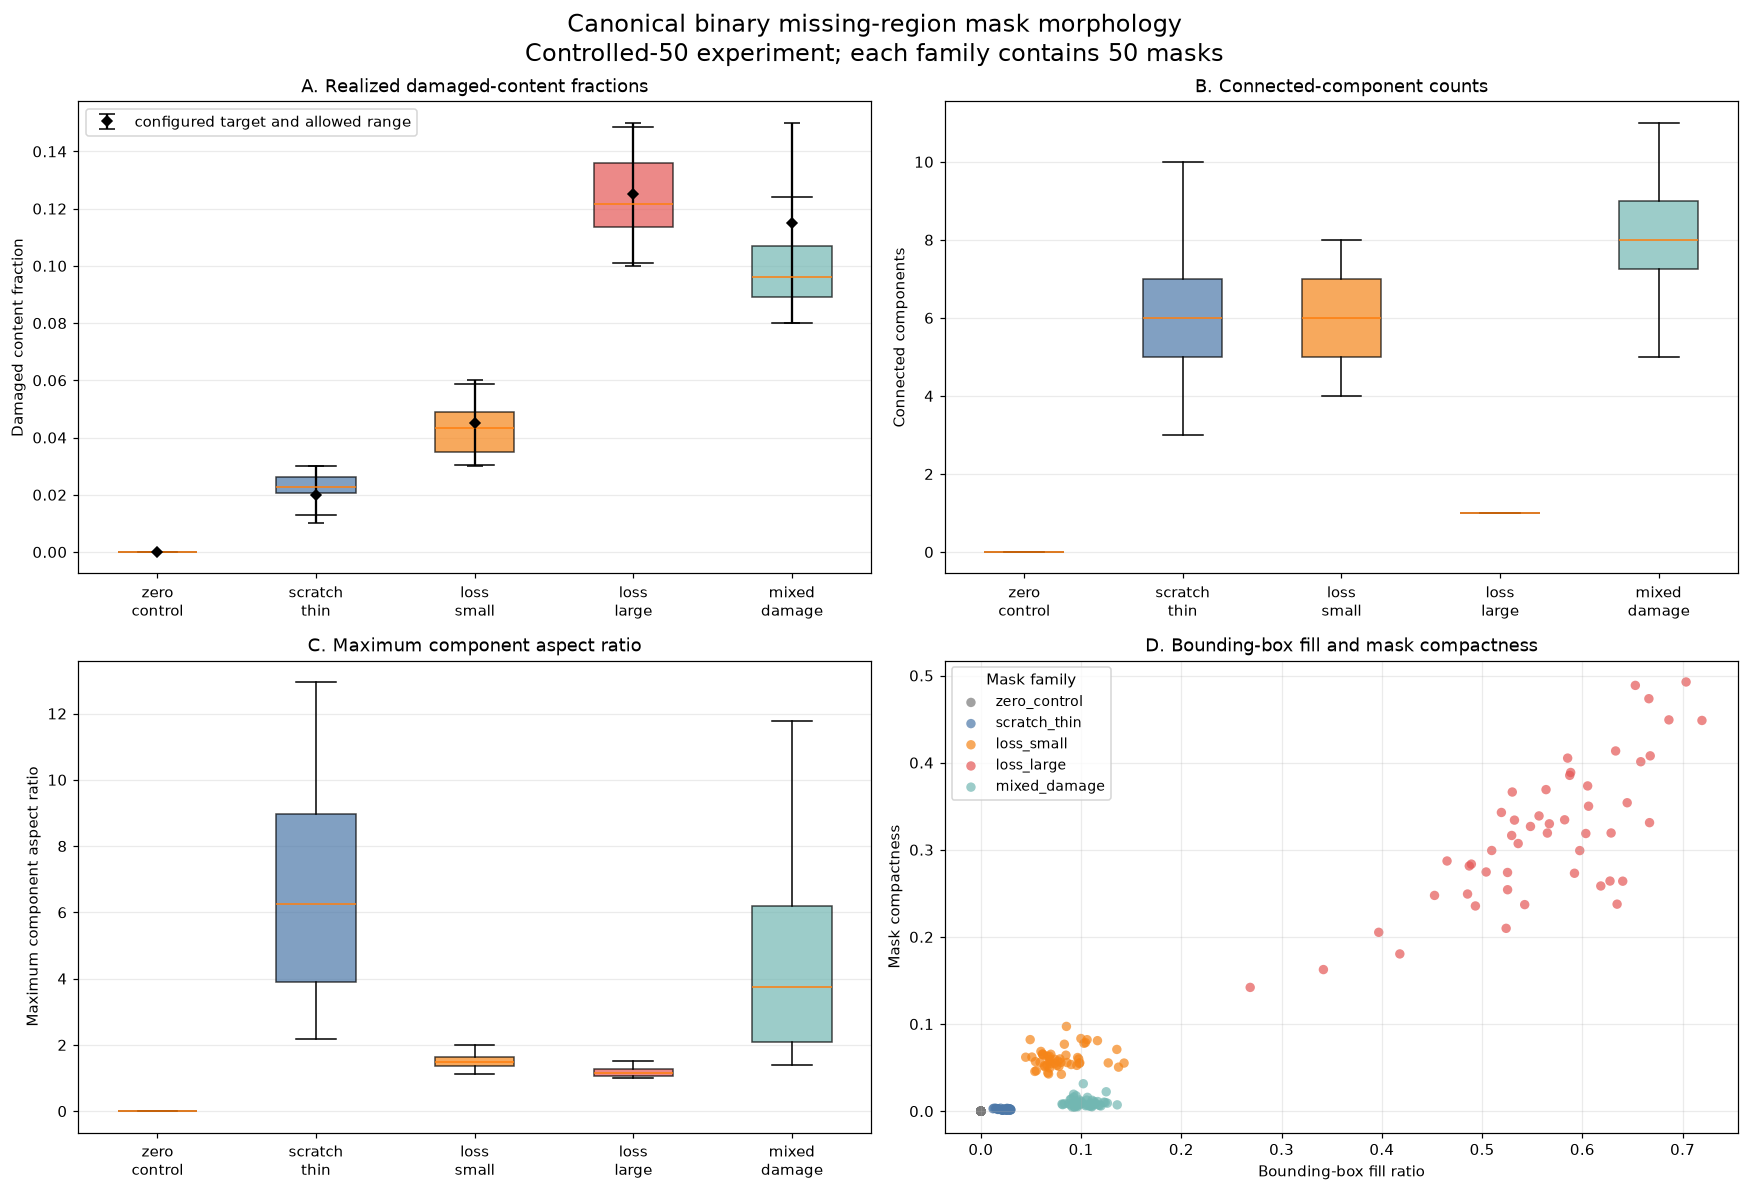

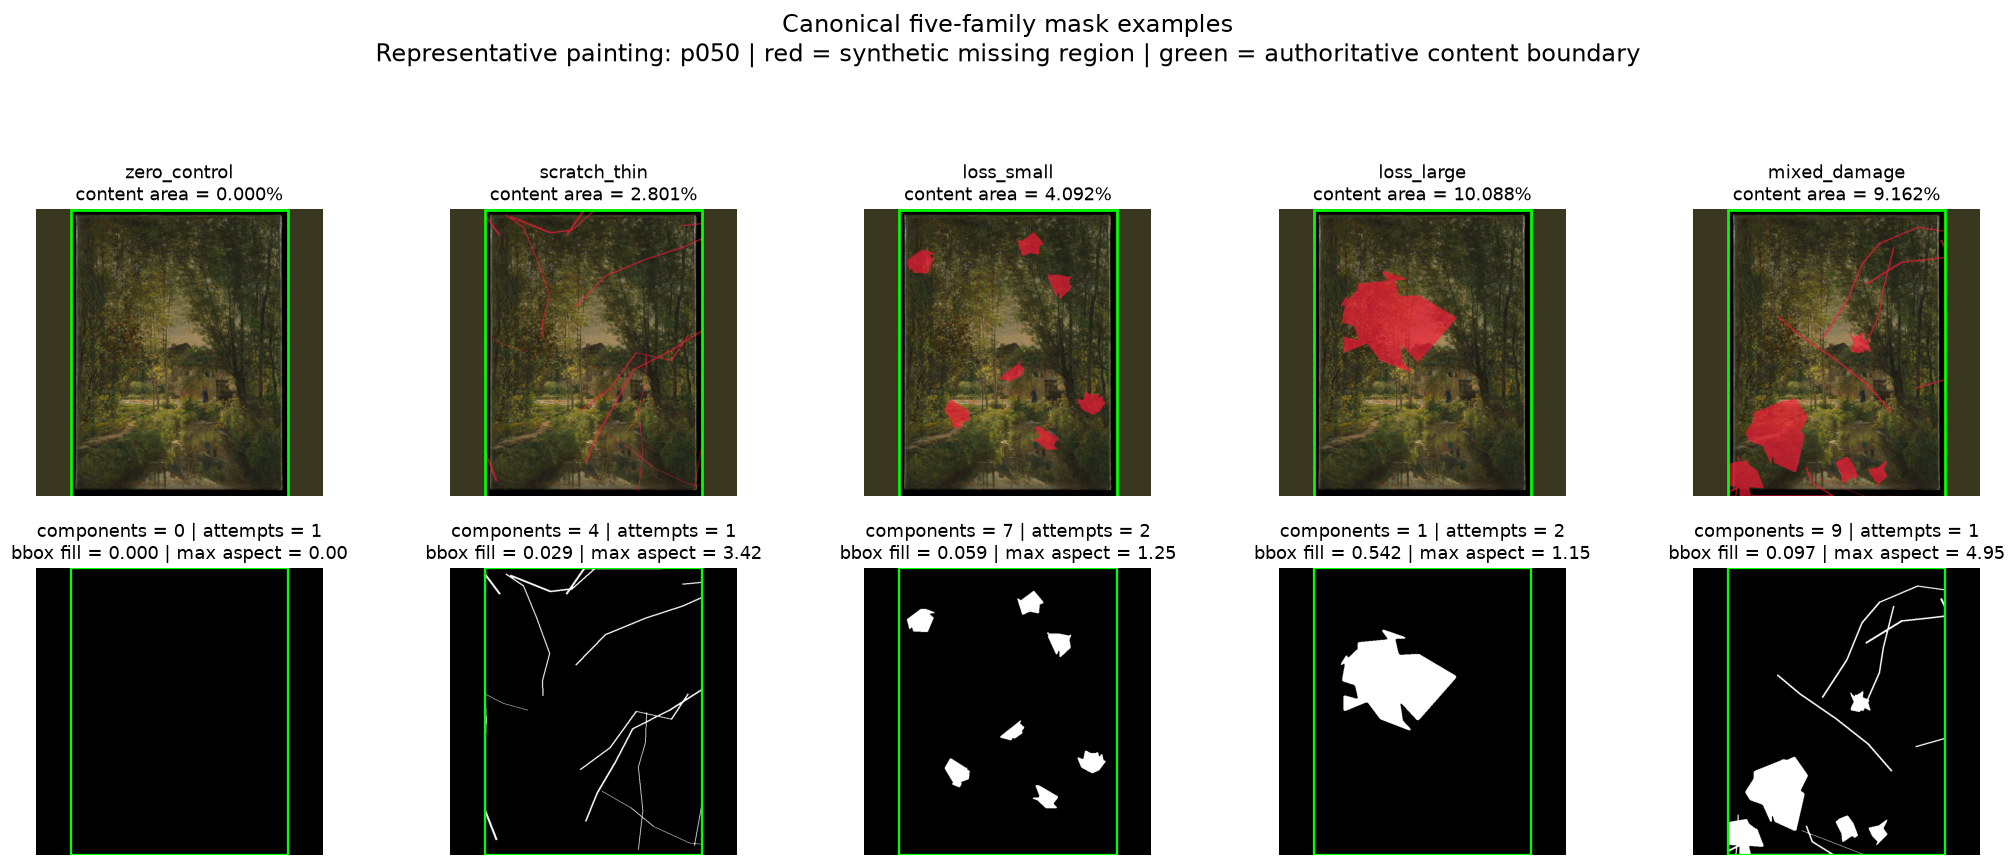

In [13]:
# ---------------------------------------------------------------------------
# Canonical morphology figure
# ---------------------------------------------------------------------------

family_palette = {
    "zero_control": "#7A7A7A",
    "scratch_thin": "#4C78A8",
    "loss_small": "#F58518",
    "loss_large": "#E45756",
    "mixed_damage": "#72B7B2",
}

family_display_labels = [
    mask_type.replace(
        "_",
        "\n",
    )
    for mask_type in SUPPORTED_MASK_TYPES
]

morphology_figure, morphology_axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 11),
    dpi=110,
    squeeze=False,
)

family_positions = np.arange(
    1,
    EXPECTED_FAMILY_COUNT + 1,
)

content_fraction_data = [
    canonical_masks_df.loc[
        canonical_masks_df[
            "mask_type"
        ] == mask_type,
        "damaged_content_fraction",
    ].astype(float).to_numpy()
    for mask_type in SUPPORTED_MASK_TYPES
]

component_count_data = [
    canonical_masks_df.loc[
        canonical_masks_df[
            "mask_type"
        ] == mask_type,
        "connected_component_count",
    ].astype(float).to_numpy()
    for mask_type in SUPPORTED_MASK_TYPES
]

maximum_aspect_data = [
    canonical_masks_df.loc[
        canonical_masks_df[
            "mask_type"
        ] == mask_type,
        "maximum_component_aspect_ratio",
    ].astype(float).to_numpy()
    for mask_type in SUPPORTED_MASK_TYPES
]


# A. Damaged-content fractions and configured ranges

fraction_axis = morphology_axes[0, 0]

fraction_boxplot = fraction_axis.boxplot(
    content_fraction_data,
    positions=family_positions,
    tick_labels=family_display_labels,
    patch_artist=True,
    showfliers=False,
)

for patch, mask_type in zip(
    fraction_boxplot["boxes"],
    SUPPORTED_MASK_TYPES,
):
    patch.set_facecolor(
        family_palette[mask_type]
    )
    patch.set_alpha(0.70)

configured_targets = np.array(
    [
        float(
            mask_config[
                "families"
            ][mask_type][
                "target_damaged_content_fraction"
            ]
        )
        for mask_type in SUPPORTED_MASK_TYPES
    ]
)

configured_lowers = np.array(
    [
        float(
            mask_config[
                "families"
            ][mask_type][
                "lower_damaged_content_fraction"
            ]
        )
        for mask_type in SUPPORTED_MASK_TYPES
    ]
)

configured_uppers = np.array(
    [
        float(
            mask_config[
                "families"
            ][mask_type][
                "upper_damaged_content_fraction"
            ]
        )
        for mask_type in SUPPORTED_MASK_TYPES
    ]
)

fraction_axis.errorbar(
    family_positions,
    configured_targets,
    yerr=np.vstack(
        [
            configured_targets
            - configured_lowers,
            configured_uppers
            - configured_targets,
        ]
    ),
    fmt="D",
    color="black",
    capsize=5,
    linewidth=1.5,
    markersize=5,
    label="configured target and allowed range",
)

fraction_axis.set_title(
    "A. Realized damaged-content fractions"
)

fraction_axis.set_ylabel(
    "Damaged content fraction"
)

fraction_axis.grid(
    axis="y",
    alpha=0.25,
)

fraction_axis.legend(
    loc="upper left"
)


# B. Connected-component counts

component_axis = morphology_axes[0, 1]

component_boxplot = component_axis.boxplot(
    component_count_data,
    positions=family_positions,
    tick_labels=family_display_labels,
    patch_artist=True,
    showfliers=False,
)

for patch, mask_type in zip(
    component_boxplot["boxes"],
    SUPPORTED_MASK_TYPES,
):
    patch.set_facecolor(
        family_palette[mask_type]
    )
    patch.set_alpha(0.70)

component_axis.set_title(
    "B. Connected-component counts"
)

component_axis.set_ylabel(
    "Connected components"
)

component_axis.grid(
    axis="y",
    alpha=0.25,
)


# C. Maximum component aspect ratio

aspect_axis = morphology_axes[1, 0]

aspect_boxplot = aspect_axis.boxplot(
    maximum_aspect_data,
    positions=family_positions,
    tick_labels=family_display_labels,
    patch_artist=True,
    showfliers=False,
)

for patch, mask_type in zip(
    aspect_boxplot["boxes"],
    SUPPORTED_MASK_TYPES,
):
    patch.set_facecolor(
        family_palette[mask_type]
    )
    patch.set_alpha(0.70)

aspect_axis.set_title(
    "C. Maximum component aspect ratio"
)

aspect_axis.set_ylabel(
    "Maximum component aspect ratio"
)

aspect_axis.grid(
    axis="y",
    alpha=0.25,
)


# D. Fill ratio and compactness relationship

compactness_axis = morphology_axes[1, 1]

for mask_type in SUPPORTED_MASK_TYPES:
    family_subset = canonical_masks_df.loc[
        canonical_masks_df[
            "mask_type"
        ] == mask_type
    ]

    compactness_axis.scatter(
        family_subset[
            "bbox_fill_ratio"
        ].astype(float),
        family_subset[
            "mask_compactness"
        ].astype(float),
        s=38,
        alpha=0.70,
        color=family_palette[
            mask_type
        ],
        label=mask_type,
        edgecolors="none",
    )

compactness_axis.set_title(
    "D. Bounding-box fill and mask compactness"
)

compactness_axis.set_xlabel(
    "Bounding-box fill ratio"
)

compactness_axis.set_ylabel(
    "Mask compactness"
)

compactness_axis.grid(
    alpha=0.25,
)

compactness_axis.legend(
    title="Mask family",
    fontsize=9,
)

morphology_figure.suptitle(
    "Canonical binary missing-region mask morphology\n"
    "Controlled-50 experiment; each family contains 50 masks",
    fontsize=16,
)

morphology_figure.tight_layout()

morphology_figure.canvas.draw()

morphology_canvas_size = (
    morphology_figure
    .canvas
    .get_width_height()
)

plt.show()


# ---------------------------------------------------------------------------
# Canonical five-family example figure
# ---------------------------------------------------------------------------

example_figure, example_axes = plt.subplots(
    nrows=2,
    ncols=EXPECTED_FAMILY_COUNT,
    figsize=(19, 8),
    dpi=110,
    squeeze=False,
)

x_min, y_min, x_max, y_max = (
    EXAMPLE_CONTENT_BBOX
)

for column_index, example_visual in enumerate(
    canonical_example_visuals
):
    mask_type = example_visual[
        "mask_type"
    ]

    mask_array = example_visual[
        "mask_array"
    ]

    mask_record = example_visual[
        "record"
    ]

    damaged_pixels = (
        mask_array > 0
    )

    overlay_array = (
        example_clean_array.astype(
            np.float32
        )
        .copy()
    )

    overlay_array[
        damaged_pixels
    ] = (
        0.35
        * overlay_array[
            damaged_pixels
        ]
        + 0.65
        * np.array(
            [
                255,
                25,
                55,
            ],
            dtype=np.float32,
        )
    )

    overlay_array = np.clip(
        overlay_array,
        0,
        255,
    ).astype(
        np.uint8
    )

    overlay_axis = example_axes[
        0,
        column_index,
    ]

    binary_axis = example_axes[
        1,
        column_index,
    ]

    overlay_axis.imshow(
        overlay_array
    )

    overlay_axis.add_patch(
        Rectangle(
            (
                x_min,
                y_min,
            ),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            edgecolor="lime",
            linewidth=1.8,
        )
    )

    overlay_axis.set_title(
        f"{mask_type}\n"
        f"content area = "
        f"{mask_record['damaged_content_fraction']:.3%}"
    )

    binary_axis.imshow(
        mask_array,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    binary_axis.add_patch(
        Rectangle(
            (
                x_min,
                y_min,
            ),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            edgecolor="lime",
            linewidth=1.5,
        )
    )

    binary_axis.set_title(
        f"components = "
        f"{mask_record['connected_component_count']} | "
        f"attempts = "
        f"{mask_record['generation_attempts']}\n"
        f"bbox fill = "
        f"{mask_record['bbox_fill_ratio']:.3f} | "
        f"max aspect = "
        f"{mask_record['maximum_component_aspect_ratio']:.2f}"
    )

    overlay_axis.set_axis_off()
    binary_axis.set_axis_off()

example_figure.suptitle(
    "Canonical five-family mask examples\n"
    f"Representative painting: {EXAMPLE_PAINTING_ID} | "
    "red = synthetic missing region | "
    "green = authoritative content boundary",
    fontsize=16,
)

example_figure.tight_layout(
    rect=(0.0, 0.0, 1.0, 0.90),
    pad=1.2,
    h_pad=3.5,
    w_pad=1.2,
)

example_figure.canvas.draw()

example_canvas_size = (
    example_figure
    .canvas
    .get_width_height()
)

plt.show()

In [14]:
# ---------------------------------------------------------------------------
# Eight final consolidated audit/reporting checks
# ---------------------------------------------------------------------------

AUDIT_REPORTING_STAGE = (
    "audit_and_reporting"
)


# 1. Exact mask_audit.v1 schema

mask_audit_schema_result = validate_dataframe(
    mask_audit_df,
    MASK_AUDIT_SCHEMA,
    allow_extra_columns=False,
)

mask_audit_schema_passed = (
    mask_audit_schema_result.passed
    and not mask_audit_schema_result.unexpected_columns
)

VALIDATION.add(
    validation_stage=AUDIT_REPORTING_STAGE,
    check_id="mask_audit_schema",
    check_description=(
        "The canonical mask audit satisfies the exact "
        "mask_audit.v1 schema."
    ),
    severity="blocking",
    expected={
        "schema_version": MASK_AUDIT_SCHEMA.version,
        "row_count": EXPECTED_AUDIT_ROW_COUNT,
        "missing_columns": [],
        "unexpected_columns": [],
        "duplicate_primary_key_rows": 0,
    },
    observed=mask_audit_schema_result.to_dict(),
    passed=mask_audit_schema_passed,
)


# 2. Exact audit structure and identifiers

expected_mask_audit_ids = [
    f"mask_audit_{index:03d}"
    for index in range(
        1,
        EXPECTED_AUDIT_ROW_COUNT + 1,
    )
]

expected_audit_section_counts = {
    "global": 30,
    "mask_family": 60,
    "family_comparison": 10,
    "morphology_expectation": 5,
}

observed_audit_section_counts = (
    mask_audit_df[
        "audit_section"
    ]
    .value_counts()
    .to_dict()
)

mask_audit_structure_passed = (
    len(mask_audit_df)
    == EXPECTED_AUDIT_ROW_COUNT
    and observed_audit_section_counts
    == expected_audit_section_counts
    and mask_audit_df[
        "audit_row_id"
    ].astype(str).tolist()
    == expected_mask_audit_ids
    and not mask_audit_df[
        "audit_row_id"
    ].duplicated().any()
)

VALIDATION.add(
    validation_stage=AUDIT_REPORTING_STAGE,
    check_id="mask_audit_structure",
    check_description=(
        "Audit cardinality, sequential identifiers, and all four "
        "approved audit sections match the 105-row design."
    ),
    severity="blocking",
    expected={
        "total_rows": EXPECTED_AUDIT_ROW_COUNT,
        "section_counts": (
            expected_audit_section_counts
        ),
        "duplicate_audit_ids": 0,
    },
    observed={
        "total_rows": len(
            mask_audit_df
        ),
        "section_counts": (
            observed_audit_section_counts
        ),
        "duplicate_audit_ids": int(
            mask_audit_df[
                "audit_row_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
    },
    passed=mask_audit_structure_passed,
)


# 3. Global audit reconciliation

observed_global_metric_names = set(
    global_mask_audit_df[
        "metric_name"
    ].astype(str)
)

expected_global_metric_names = set(
    expected_global_mask_audit_values
)

global_mask_audit_failures = []

if (
    observed_global_metric_names
    == expected_global_metric_names
):
    observed_global_values = {
        str(row.metric_name): float(
            row.metric_value
        )
        for row in (
            global_mask_audit_df.itertuples(
                index=False
            )
        )
    }

    for metric_name, expected_value in (
        expected_global_mask_audit_values.items()
    ):
        observed_value = (
            observed_global_values[
                metric_name
            ]
        )

        if not np.isclose(
            observed_value,
            float(expected_value),
            rtol=0,
            atol=1e-12,
        ):
            global_mask_audit_failures.append(
                {
                    "metric_name": metric_name,
                    "expected": float(
                        expected_value
                    ),
                    "observed": (
                        observed_value
                    ),
                }
            )
else:
    global_mask_audit_failures.append(
        {
            "missing_metric_names": sorted(
                expected_global_metric_names
                - observed_global_metric_names
            ),
            "unexpected_metric_names": sorted(
                observed_global_metric_names
                - expected_global_metric_names
            ),
        }
    )

global_mask_audit_passed = (
    not global_mask_audit_failures
    and len(global_mask_audit_df)
    == GLOBAL_AUDIT_METRIC_COUNT
    and global_mask_audit_df[
        "status"
    ].eq("passed").all()
)

VALIDATION.add(
    validation_stage=AUDIT_REPORTING_STAGE,
    check_id="global_mask_audit_reconciliation",
    check_description=(
        "All 30 global audit metrics reconcile with current "
        "generation, files, validation, replay, and runtimes."
    ),
    severity="blocking",
    expected={
        "metric_count": GLOBAL_AUDIT_METRIC_COUNT,
        "metric_failures": 0,
        "nonpassed_statuses": 0,
    },
    observed={
        "metric_count": len(
            global_mask_audit_df
        ),
        "metric_failures": len(
            global_mask_audit_failures
        ),
        "nonpassed_statuses": int(
            (
                ~global_mask_audit_df[
                    "status"
                ].eq("passed")
            ).sum()
        ),
    },
    passed=global_mask_audit_passed,
    details=global_mask_audit_failures,
)


# 4. Per-family audit reconciliation

family_reconciliation_failures = (
    family_audit_reconciliation_df.loc[
        (
            family_audit_reconciliation_df[
                "_merge"
            ] != "both"
        )
        | ~family_audit_reconciliation_df[
            "metric_value_matches"
        ]
        | ~family_audit_reconciliation_df[
            "denominator_matches"
        ]
        | (
            family_audit_reconciliation_df[
                "group_field"
            ].astype(str)
            != "mask_type"
        )
        | (
            family_audit_reconciliation_df[
                "status"
            ].astype(str)
            != "passed"
        ),
        [
            "group_value",
            "metric_name",
            "metric_value",
            "expected_metric_value",
            "denominator",
            "expected_denominator",
            "group_field",
            "status",
            "_merge",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

family_audit_passed = (
    len(family_mask_audit_df)
    == (
        EXPECTED_FAMILY_COUNT
        * len(FAMILY_AUDIT_METRICS)
    )
    and not family_reconciliation_failures
)

VALIDATION.add(
    validation_stage=AUDIT_REPORTING_STAGE,
    check_id="family_mask_audit_reconciliation",
    check_description=(
        "All 12 metrics for each canonical family reconcile "
        "with the normalized mask table."
    ),
    severity="blocking",
    expected={
        "family_count": EXPECTED_FAMILY_COUNT,
        "metrics_per_family": len(
            FAMILY_AUDIT_METRICS
        ),
        "reconciliation_failures": 0,
    },
    observed={
        "family_count": int(
            family_mask_audit_df[
                "group_value"
            ].nunique()
        ),
        "metrics_per_family": int(
            family_mask_audit_df[
                "metric_name"
            ].nunique()
        ),
        "reconciliation_failures": len(
            family_reconciliation_failures
        ),
    },
    passed=family_audit_passed,
    details=family_reconciliation_failures,
)


# 5. Pairwise and morphology-expectation evidence

pairwise_expectation_passed = (
    len(pairwise_mask_audit_df) == 10
    and pairwise_mask_audit_df[
        "metric_value"
    ].astype(float).eq(0.0).all()
    and pairwise_mask_audit_df[
        "status"
    ].eq("passed").all()
    and len(expectation_mask_audit_df)
    == EXPECTED_FAMILY_COUNT
    and expectation_mask_audit_df[
        "metric_value"
    ].astype(float).eq(1.0).all()
    and expectation_mask_audit_df[
        "status"
    ].eq("passed").all()
    and set(
        expectation_mask_audit_df[
            "metric_name"
        ].astype(str)
    )
    == set(
        family_validation_df[
            "rule_id"
        ].astype(str)
    )
)

VALIDATION.add(
    validation_stage=AUDIT_REPORTING_STAGE,
    check_id="family_comparison_expectations",
    check_description=(
        "All 10 pairwise family comparisons show zero equivalent "
        "cases and all five morphology expectations pass."
    ),
    severity="blocking",
    expected={
        "pairwise_rows": 10,
        "equivalent_cases": 0,
        "expectation_rows": EXPECTED_FAMILY_COUNT,
        "failed_expectations": 0,
    },
    observed={
        "pairwise_rows": len(
            pairwise_mask_audit_df
        ),
        "equivalent_cases": int(
            pairwise_mask_audit_df[
                "metric_value"
            ].astype(float).sum()
        ),
        "expectation_rows": len(
            expectation_mask_audit_df
        ),
        "failed_expectations": int(
            (
                ~expectation_mask_audit_df[
                    "status"
                ].eq("passed")
            ).sum()
        ),
    },
    passed=pairwise_expectation_passed,
)


# 6. Canonical morphology-figure rendering

morphology_figure_passed = (
    morphology_figure is not None
    and morphology_axes.shape == (2, 2)
    and len(
        morphology_figure.axes
    ) == 4
    and morphology_canvas_size[0] > 0
    and morphology_canvas_size[1] > 0
)

VALIDATION.add(
    validation_stage=AUDIT_REPORTING_STAGE,
    check_id="mask_morphology_figure",
    check_description=(
        "The canonical four-panel morphology figure renders "
        "with a positive canvas and the expected axes."
    ),
    severity="blocking",
    expected={
        "rows": 2,
        "columns": 2,
        "axes": 4,
        "positive_canvas_dimensions": True,
    },
    observed={
        "rows": (
            morphology_axes.shape[0]
        ),
        "columns": (
            morphology_axes.shape[1]
        ),
        "axes": len(
            morphology_figure.axes
        ),
        "canvas_size": (
            morphology_canvas_size
        ),
    },
    passed=morphology_figure_passed,
)


# 7. Deterministic canonical examples and rendering

canonical_examples_passed = (
    len(example_selection_df) == 1
    and example_selection_deterministic
    and len(canonical_example_records_df)
    == EXPECTED_FAMILY_COUNT
    and canonical_example_records_df[
        "mask_type"
    ].nunique()
    == EXPECTED_FAMILY_COUNT
    and canonical_example_records_df[
        "reload_passed"
    ].all()
    and canonical_example_records_df[
        "checksum_passed"
    ].all()
    and example_figure is not None
    and example_axes.shape
    == (
        2,
        EXPECTED_FAMILY_COUNT,
    )
    and len(
        example_figure.axes
    )
    == 2 * EXPECTED_FAMILY_COUNT
    and example_canvas_size[0] > 0
    and example_canvas_size[1] > 0
)

VALIDATION.add(
    validation_stage=AUDIT_REPORTING_STAGE,
    check_id="mask_examples_figure",
    check_description=(
        "The deterministic representative reloads all five masks "
        "and renders the canonical overlay/binary example figure."
    ),
    severity="blocking",
    expected={
        "selection_rows": 1,
        "repeat_selection_matches": True,
        "mask_rows": EXPECTED_FAMILY_COUNT,
        "reload_failures": 0,
        "checksum_failures": 0,
        "figure_rows": 2,
        "figure_columns": EXPECTED_FAMILY_COUNT,
        "axes": 2 * EXPECTED_FAMILY_COUNT,
    },
    observed={
        "selection_rows": len(
            example_selection_df
        ),
        "painting_id": (
            EXAMPLE_PAINTING_ID
        ),
        "repeat_selection_matches": (
            example_selection_deterministic
        ),
        "mask_rows": len(
            canonical_example_records_df
        ),
        "reload_failures": int(
            (
                ~canonical_example_records_df[
                    "reload_passed"
                ]
            ).sum()
        ),
        "checksum_failures": int(
            (
                ~canonical_example_records_df[
                    "checksum_passed"
                ]
            ).sum()
        ),
        "figure_shape": (
            example_axes.shape
        ),
        "axes": len(
            example_figure.axes
        ),
        "canvas_size": (
            example_canvas_size
        ),
    },
    passed=canonical_examples_passed,
)


# 8. Protocol completeness and interpretation boundary

protocol_lower = (
    mask_protocol_text.lower()
)

missing_protocol_families = [
    mask_type
    for mask_type in SUPPORTED_MASK_TYPES
    if mask_type not in mask_protocol_text
]

missing_protocol_exclusions = [
    exclusion
    for exclusion in mask_config[
        "exclusions"
    ]
    if str(exclusion).lower()
    not in protocol_lower
]

protocol_required_phrases = (
    "binary missing-region damage only",
    "never eligible for damage",
    "controlled synthetic evaluation instruments",
    "do not claim",
)

missing_protocol_phrases = [
    phrase
    for phrase in protocol_required_phrases
    if phrase not in protocol_lower
]

mask_protocol_passed = (
    bool(
        mask_protocol_text.strip()
    )
    and mask_config[
        "config_schema_version"
    ] in mask_protocol_text
    and mask_config[
        "config_version"
    ] in mask_protocol_text
    and mask_config[
        "generator"
    ]["version"]
    in mask_protocol_text
    and not missing_protocol_families
    and not missing_protocol_exclusions
    and not missing_protocol_phrases
)

VALIDATION.add(
    validation_stage=AUDIT_REPORTING_STAGE,
    check_id="mask_protocol",
    check_description=(
        "The protocol records configuration, families, exclusions, "
        "content support, and the synthetic-evaluation boundary."
    ),
    severity="blocking",
    expected={
        "missing_families": [],
        "missing_exclusions": [],
        "missing_required_phrases": [],
    },
    observed={
        "character_count": len(
            mask_protocol_text
        ),
        "missing_families": (
            missing_protocol_families
        ),
        "missing_exclusions": (
            missing_protocol_exclusions
        ),
        "missing_required_phrases": (
            missing_protocol_phrases
        ),
    },
    passed=mask_protocol_passed,
)


# ---------------------------------------------------------------------------
# Final planned consolidated validation summary
# ---------------------------------------------------------------------------

cumulative_checks_df = VALIDATION.to_dataframe()

batch6_checks_df = cumulative_checks_df.loc[
    cumulative_checks_df[
        "validation_stage"
    ] == AUDIT_REPORTING_STAGE
].reset_index(drop=True)

if len(batch6_checks_df) != 8:
    raise RuntimeError(
        "Batch 6 should add exactly eight audit/reporting checks; "
        f"found {len(batch6_checks_df)}."
    )

if len(cumulative_checks_df) != 50:
    raise RuntimeError(
        "The planned consolidated validation table should now "
        f"contain exactly 50 checks; found {len(cumulative_checks_df)}."
    )

print("Batch 6 audit and reporting checks:")
display(
    batch6_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nGlobal canonical-mask audit:")
display(
    global_mask_audit_df[
        [
            "audit_row_id",
            "metric_name",
            "metric_value",
            "metric_unit",
            "status",
        ]
    ]
)

print("\nPer-family canonical-mask audit:")
display(
    family_mask_audit_df.pivot(
        index="group_value",
        columns="metric_name",
        values="metric_value",
    )
    .reindex(
        SUPPORTED_MASK_TYPES
    )
)

print("\nPairwise family comparisons:")
display(
    pairwise_mask_audit_df[
        [
            "group_value",
            "comparison_group_value",
            "metric_name",
            "metric_value",
            "denominator",
            "status",
        ]
    ]
)

print("\nMorphology expectations:")
display(
    expectation_mask_audit_df[
        [
            "group_value",
            "metric_name",
            "metric_value",
            "status",
            "details",
        ]
    ]
)

print("\nCanonical example records:")
display(canonical_example_records_df)

print("\nCanonical mask protocol:")
display(Markdown(mask_protocol_text))

VALIDATION.raise_for_blocking()

print("\nBatch 6 completed successfully.")
print("Batch 6 checks:", len(batch6_checks_df))
print("Final consolidated checks:", len(cumulative_checks_df))
print("Separate smoke checks:", len(smoke_checks_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("Audit rows held in memory:", len(mask_audit_df))
print("Morphology figure held in memory: True")
print("Examples figure held in memory: True")
print("Protocol held in memory: True")
print("No new artifact has been persisted.")
print(
    "Next approved stage: Batch 7 - "
    "atomic canonical persistence and manifest handoff."
)

Batch 6 audit and reporting checks:


,check_id,severity,expected,observed,passed
0,mask_audit_schema,blocking,"{""duplicate_primary_key_rows"": 0, ""missing_col...","{""column_count"": 16, ""duplicate_primary_key_ro...",True
1,mask_audit_structure,blocking,"{""duplicate_audit_ids"": 0, ""section_counts"": {...","{""duplicate_audit_ids"": 0, ""section_counts"": {...",True
2,global_mask_audit_reconciliation,blocking,"{""metric_count"": 30, ""metric_failures"": 0, ""no...","{""metric_count"": 30, ""metric_failures"": 0, ""no...",True
3,family_mask_audit_reconciliation,blocking,"{""family_count"": 5, ""metrics_per_family"": 12, ...","{""family_count"": 5, ""metrics_per_family"": 12, ...",True
4,family_comparison_expectations,blocking,"{""equivalent_cases"": 0, ""expectation_rows"": 5,...","{""equivalent_cases"": 0, ""expectation_rows"": 5,...",True
5,mask_morphology_figure,blocking,"{""axes"": 4, ""columns"": 2, ""positive_canvas_dim...","{""axes"": 4, ""canvas_size"": [1760, 1210], ""colu...",True
6,mask_examples_figure,blocking,"{""axes"": 10, ""checksum_failures"": 0, ""figure_c...","{""axes"": 10, ""canvas_size"": [2090, 880], ""chec...",True
7,mask_protocol,blocking,"{""missing_exclusions"": [], ""missing_families"":...","{""character_count"": 2200, ""missing_exclusions""...",True



Global canonical-mask audit:


,audit_row_id,metric_name,metric_value,metric_unit,status
0,mask_audit_001,accepted_input_count,50.000000,count,passed
1,mask_audit_002,configured_family_count,5.000000,count,passed
2,mask_audit_003,expected_mask_count,250.000000,count,passed
3,mask_audit_004,generated_mask_count,250.000000,count,passed
4,mask_audit_005,saved_mask_file_count,250.000000,count,passed
5,mask_audit_006,failed_generation_count,0.000000,count,passed
6,mask_audit_007,missing_mask_count,0.000000,count,passed
7,mask_audit_008,stale_mask_count,0.000000,count,passed
8,mask_audit_009,orphan_mask_count,0.000000,count,passed
9,mask_audit_010,duplicate_identity_group_count,0.000000,count,passed



Per-family canonical-mask audit:


...


Canonical example records:


,painting_id,mask_type,mask_path,reload_passed,checksum_passed,damaged_content_fraction,connected_component_count,bbox_fill_ratio,maximum_component_aspect_ratio,touches_content_boundary
0,p050,zero_control,outputs/03_canonical_mask_generation/images/ma...,True,True,0.000000,0,0.000000,0.000000,False
1,p050,scratch_thin,outputs/03_canonical_mask_generation/images/ma...,True,True,0.028006,4,0.028526,3.417391,True
2,p050,loss_small,outputs/03_canonical_mask_generation/images/ma...,True,True,0.040924,7,0.059078,1.245902,False
3,p050,loss_large,outputs/03_canonical_mask_generation/images/ma...,True,True,0.100880,1,0.542474,1.148699,False
4,p050,mixed_damage,outputs/03_canonical_mask_generation/images/ma...,True,True,0.091625,9,0.097462,4.949367,True



Canonical mask protocol:


# Canonical Binary Missing-Region Mask Protocol

- Configuration schema: `canonical_mask_config.v1`
- Configuration version: `1.0.0`
- Generator: `canonical_synthetic_damage_masks` version `3.0.0`
- Seed scheme: `canonical_mask_seed.v1`
- Global seed: `20260630`
- Retry policy: `closed_range_then_nearest_range_and_target`
- Maximum attempts: 30
- Spatial convention: `xyxy_exclusive_zero_based`
- Area denominator: painting-content pixels from Notebook 02
- Saved values: grayscale PNG with exact values 0 and 255

## Canonical mask families

| Family | Lower | Target | Upper | Description |
|---|---:|---:|---:|---|
| `zero_control` | 0.000 | 0.000 | 0.000 | No missing-region damage; measures unnecessary model alteration. |
| `scratch_thin` | 0.010 | 0.020 | 0.030 | Thin elongated scratch- or crack-like missing-region damage. |
| `loss_small` | 0.030 | 0.045 | 0.060 | Several small localized irregular missing-paint regions. |
| `loss_large` | 0.100 | 0.125 | 0.150 | One or two large irregular missing regions. |
| `mixed_damage` | 0.080 | 0.115 | 0.150 | Combined scratches, scattered losses, a medium loss, and edge loss. |

## Morphology expectations

| Family | Rule | Status |
|---|---|---|
| `zero_control` | `zero_control_empty` | passed |
| `scratch_thin` | `scratch_thin_elongated` | passed |
| `loss_small` | `loss_small_multicomponent` | passed |
| `loss_large` | `loss_large_substantially_larger` | passed |
| `mixed_damage` | `mixed_damage_combined_characteristics` | passed |

## Explicit exclusions

This notebook models binary missing-region damage only. It does not model:

- `blur`
- `fading`
- `discolouration`
- `dirt`
- `dust`
- `stains`
- `partial_transparency`
- `other_non_binary_degradation`

## Interpretation boundary

These masks are controlled synthetic evaluation instruments. They do not claim to reproduce the full material, historical, chemical, or conservation complexity of real painting damage.
Padding belongs to the technical model canvas and is never eligible for damage.
Runtime, run identifiers, timestamps, and environment metadata are run-dependent; mask pixels and canonical geometry are deterministic under the recorded configuration and seeds.



Batch 6 completed successfully.
Batch 6 checks: 8
Final consolidated checks: 50
Separate smoke checks: 8
Blocking failures: 0
Audit rows held in memory: 105
Morphology figure held in memory: True
Examples figure held in memory: True
Protocol held in memory: True
No new artifact has been persisted.
Next approved stage: Batch 7 - atomic canonical persistence and manifest handoff.


## Batch 7 — Atomic Canonical Persistence and Manifest Handoff

This batch atomically persists the validated canonical outputs:

- `data/masks.csv`
- `metrics/mask_audit.csv`
- `figures/mask_morphology.png`
- `figures/mask_examples.png`
- `reports/mask_protocol.md`
- `validation/checks.csv`

It then creates:

- the normalized seven-row artifact manifest;
- the provisional reproducibility run manifest;
- immediate reload, schema, checksum, ownership, and exact-output-set evidence.

The artifact manifest records seven externally meaningful scientific,
reporting, and validation artifacts:

1. the normalized canonical-mask table;
2. the 250-image canonical binary-mask collection;
3. the normalized mask audit;
4. the mask-morphology figure;
5. the canonical-examples figure;
6. the methodology protocol;
7. the consolidated validation table.

The artifact manifest does not recursively register itself or the run
manifest.

The run manifest remains in `running` state with
`completion_gate_passed: false` until Batch 8 verifies the complete
Notebook 03 contract and updates the global project-path registry.

In [15]:
# ---------------------------------------------------------------------------
# Batch 7 helper imports
# ---------------------------------------------------------------------------

from restoration_eval.dataset_verification import (
    write_dataframe_atomic,
)

from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


# ---------------------------------------------------------------------------
# Pre-persistence gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The 50-check consolidated validation gate has not passed."
    )

if not SMOKE_VALIDATION.overall_passed:
    raise RuntimeError(
        "The separate representative smoke gate has not passed."
    )

validation_checks_df = VALIDATION.to_dataframe()

if len(validation_checks_df) != EXPECTED_VALIDATION_ROW_COUNT:
    raise RuntimeError(
        "Exactly "
        f"{EXPECTED_VALIDATION_ROW_COUNT} consolidated validation "
        f"rows are required; found {len(validation_checks_df)}."
    )

if len(canonical_masks_df) != EXPECTED_MASK_COUNT:
    raise RuntimeError(
        "The canonical mask table does not contain the expected "
        f"{EXPECTED_MASK_COUNT} rows."
    )

if len(mask_audit_df) != EXPECTED_AUDIT_ROW_COUNT:
    raise RuntimeError(
        "The mask audit does not contain the expected "
        f"{EXPECTED_AUDIT_ROW_COUNT} rows."
    )

if morphology_figure is None:
    raise RuntimeError(
        "The canonical morphology figure is not available in memory."
    )

if example_figure is None:
    raise RuntimeError(
        "The canonical examples figure is not available in memory."
    )

if not mask_protocol_text.strip():
    raise RuntimeError(
        "The canonical mask protocol is empty."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared output target
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in OUTPUT_PATHS.items():
    try:
        validated_path = require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        if validated_path != output_path.resolve():
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(output_path),
                    "issue": "resolved_path_mismatch",
                }
            )

    except Exception as exc:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(output_path),
                "issue": f"{type(exc).__name__}: {exc}",
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more output paths violate notebook ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Atomic canonical table persistence
# ---------------------------------------------------------------------------

write_dataframe_atomic(
    canonical_masks_df,
    OUTPUT_PATHS["canonical_masks"],
)

write_dataframe_atomic(
    mask_audit_df,
    OUTPUT_PATHS["mask_audit"],
)

write_dataframe_atomic(
    validation_checks_df,
    OUTPUT_PATHS["validation_checks"],
)


# ---------------------------------------------------------------------------
# Local atomic figure and text writers
# ---------------------------------------------------------------------------

def write_figure_atomic(
    figure,
    target_path,
    *,
    title,
    dpi,
):
    target_path = Path(target_path)
    target_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = target_path.with_name(
        f".{target_path.stem}.tmp{target_path.suffix}"
    )

    try:
        figure.savefig(
            temporary_path,
            dpi=int(dpi),
            bbox_inches="tight",
            facecolor="white",
            metadata={
                "Title": title,
                "Creator": NOTEBOOK_STEM,
            },
        )

        temporary_path.replace(target_path)

    finally:
        temporary_path.unlink(missing_ok=True)

    return target_path


def write_text_atomic(
    text,
    target_path,
):
    target_path = Path(target_path)
    target_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = target_path.with_name(
        f".{target_path.stem}.tmp{target_path.suffix}"
    )

    try:
        temporary_path.write_text(
            text,
            encoding="utf-8",
            newline="\n",
        )

        temporary_path.replace(target_path)

    finally:
        temporary_path.unlink(missing_ok=True)

    return target_path


figure_dpi = int(
    mask_config["examples"]["figure_dpi"]
)

write_figure_atomic(
    morphology_figure,
    OUTPUT_PATHS["mask_morphology_figure"],
    title="Notebook 03 Canonical Mask Morphology",
    dpi=figure_dpi,
)

write_figure_atomic(
    example_figure,
    OUTPUT_PATHS["mask_examples_figure"],
    title="Notebook 03 Canonical Mask Examples",
    dpi=figure_dpi,
)

normalized_protocol_text = (
    mask_protocol_text.rstrip() + "\n"
)

write_text_atomic(
    normalized_protocol_text,
    OUTPUT_PATHS["mask_protocol"],
)


# ---------------------------------------------------------------------------
# Immediate canonical reload
# ---------------------------------------------------------------------------

canonical_masks_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["canonical_masks"],
    low_memory=False,
)

mask_audit_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["mask_audit"],
    low_memory=False,
)

validation_checks_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["validation_checks"],
    low_memory=False,
)

canonical_masks_reload_schema_result = validate_dataframe(
    canonical_masks_reloaded_df,
    CANONICAL_MASKS_SCHEMA,
    allow_extra_columns=False,
)

mask_audit_reload_schema_result = validate_dataframe(
    mask_audit_reloaded_df,
    MASK_AUDIT_SCHEMA,
    allow_extra_columns=False,
)

validation_reload_schema_result = validate_dataframe(
    validation_checks_reloaded_df,
    VALIDATION_CHECKS_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Reloaded table identity evidence
# ---------------------------------------------------------------------------

expected_mask_ids = set(
    canonical_masks_df["mask_id"].astype(str)
)

reloaded_mask_ids = set(
    canonical_masks_reloaded_df[
        "mask_id"
    ].astype(str)
)

expected_mask_paths = set(
    canonical_masks_df["mask_path"].astype(str)
)

reloaded_mask_paths = set(
    canonical_masks_reloaded_df[
        "mask_path"
    ].astype(str)
)

expected_audit_ids = set(
    mask_audit_df["audit_row_id"].astype(str)
)

reloaded_audit_ids = set(
    mask_audit_reloaded_df[
        "audit_row_id"
    ].astype(str)
)

expected_validation_keys = {
    (
        str(check.validation_stage),
        str(check.check_id),
    )
    for check in VALIDATION.checks
}

reloaded_validation_keys = {
    (
        str(row.validation_stage),
        str(row.check_id),
    )
    for row in validation_checks_reloaded_df.itertuples(
        index=False
    )
}

reloaded_passed_values = (
    validation_checks_reloaded_df["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
)

all_reloaded_checks_passed = bool(
    reloaded_passed_values.eq("true").all()
)


# ---------------------------------------------------------------------------
# Reload persisted figures
# ---------------------------------------------------------------------------

persisted_figure_evidence = {}

for figure_key in (
    "mask_morphology_figure",
    "mask_examples_figure",
):
    figure_path = OUTPUT_PATHS[figure_key]

    with Image.open(figure_path) as figure_file:
        figure_file.load()

        persisted_figure_evidence[
            figure_key
        ] = {
            "format": str(figure_file.format),
            "mode": str(figure_file.mode),
            "width": int(figure_file.width),
            "height": int(figure_file.height),
            "sha256": sha256_file(figure_path),
        }

morphology_reload_evidence = (
    persisted_figure_evidence[
        "mask_morphology_figure"
    ]
)

examples_reload_evidence = (
    persisted_figure_evidence[
        "mask_examples_figure"
    ]
)

morphology_reload_passed = (
    morphology_reload_evidence["format"] == "PNG"
    and morphology_reload_evidence["mode"] in {"RGB", "RGBA"}
    and morphology_reload_evidence["width"] > 0
    and morphology_reload_evidence["height"] > 0
    and len(morphology_reload_evidence["sha256"]) == 64
)

examples_reload_passed = (
    examples_reload_evidence["format"] == "PNG"
    and examples_reload_evidence["mode"] in {"RGB", "RGBA"}
    and examples_reload_evidence["width"] > 0
    and examples_reload_evidence["height"] > 0
    and len(examples_reload_evidence["sha256"]) == 64
)


# ---------------------------------------------------------------------------
# Reload persisted methodology protocol
# ---------------------------------------------------------------------------

mask_protocol_reloaded_text = (
    OUTPUT_PATHS["mask_protocol"].read_text(
        encoding="utf-8-sig"
    )
)

mask_protocol_reload_passed = (
    mask_protocol_reloaded_text
    == normalized_protocol_text
    and bool(mask_protocol_reloaded_text.strip())
    and len(
        sha256_file(
            OUTPUT_PATHS["mask_protocol"]
        )
    )
    == 64
)


# ---------------------------------------------------------------------------
# Separate persistence-validation gate
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = ValidationCollector()

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="output_path_ownership",
    check_description=(
        "Every declared output path remains inside the exact "
        "Notebook 03 output root."
    ),
    severity="blocking",
    expected="zero ownership failures",
    observed=output_ownership_failures,
    passed=not output_ownership_failures,
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="canonical_masks_csv_reload",
    check_description=(
        "Persisted masks.csv reloads under canonical_masks.v1 "
        "with all 250 expected mask identities and paths."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_MASK_COUNT,
        "schema_passed": True,
        "mask_ids_match": True,
        "mask_paths_match": True,
    },
    observed={
        "rows": len(canonical_masks_reloaded_df),
        "schema": (
            canonical_masks_reload_schema_result.to_dict()
        ),
        "mask_ids_match": (
            reloaded_mask_ids == expected_mask_ids
        ),
        "mask_paths_match": (
            reloaded_mask_paths == expected_mask_paths
        ),
    },
    passed=(
        canonical_masks_reload_schema_result.passed
        and len(canonical_masks_reloaded_df)
        == EXPECTED_MASK_COUNT
        and reloaded_mask_ids == expected_mask_ids
        and reloaded_mask_paths == expected_mask_paths
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="mask_audit_csv_reload",
    check_description=(
        "Persisted mask_audit.csv reloads under mask_audit.v1 "
        "with all 105 expected audit identities."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_AUDIT_ROW_COUNT,
        "schema_passed": True,
        "audit_ids_match": True,
    },
    observed={
        "rows": len(mask_audit_reloaded_df),
        "schema": (
            mask_audit_reload_schema_result.to_dict()
        ),
        "audit_ids_match": (
            reloaded_audit_ids == expected_audit_ids
        ),
    },
    passed=(
        mask_audit_reload_schema_result.passed
        and len(mask_audit_reloaded_df)
        == EXPECTED_AUDIT_ROW_COUNT
        and reloaded_audit_ids == expected_audit_ids
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="validation_checks_csv_reload",
    check_description=(
        "Persisted checks.csv reloads under validation_checks.v1 "
        "with all 50 expected passing check identities."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_VALIDATION_ROW_COUNT,
        "schema_passed": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(validation_checks_reloaded_df),
        "schema": validation_reload_schema_result.to_dict(),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "all_passed": all_reloaded_checks_passed,
    },
    passed=(
        validation_reload_schema_result.passed
        and len(validation_checks_reloaded_df)
        == EXPECTED_VALIDATION_ROW_COUNT
        and reloaded_validation_keys
        == expected_validation_keys
        and all_reloaded_checks_passed
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="mask_morphology_figure_reload",
    check_description=(
        "The canonical morphology figure reloads as a readable "
        "non-empty PNG with a stable SHA-256 checksum."
    ),
    severity="blocking",
    expected={
        "format": "PNG",
        "mode": ["RGB", "RGBA"],
        "positive_dimensions": True,
        "sha256_length": 64,
    },
    observed=morphology_reload_evidence,
    passed=morphology_reload_passed,
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="mask_examples_figure_reload",
    check_description=(
        "The canonical examples figure reloads as a readable "
        "non-empty PNG with a stable SHA-256 checksum."
    ),
    severity="blocking",
    expected={
        "format": "PNG",
        "mode": ["RGB", "RGBA"],
        "positive_dimensions": True,
        "sha256_length": 64,
    },
    observed=examples_reload_evidence,
    passed=examples_reload_passed,
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="mask_protocol_reload",
    check_description=(
        "The persisted mask protocol exactly matches the approved "
        "in-memory methodology text."
    ),
    severity="blocking",
    expected={
        "exact_text_match": True,
        "nonempty": True,
        "sha256_length": 64,
    },
    observed={
        "exact_text_match": (
            mask_protocol_reloaded_text
            == normalized_protocol_text
        ),
        "character_count": len(
            mask_protocol_reloaded_text
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS["mask_protocol"]
        ),
    },
    passed=mask_protocol_reload_passed,
)

persistence_checks_df = (
    PERSISTENCE_VALIDATION.to_dataframe()
)

if len(persistence_checks_df) != 7:
    raise RuntimeError(
        "Batch 7 should produce exactly seven separate persistence "
        f"checks; found {len(persistence_checks_df)}."
    )

PERSISTENCE_VALIDATION.raise_for_blocking()

if len(VALIDATION.checks) != EXPECTED_VALIDATION_ROW_COUNT:
    raise RuntimeError(
        "Persistence checks must not modify the approved "
        f"{EXPECTED_VALIDATION_ROW_COUNT} consolidated checks; "
        f"found {len(VALIDATION.checks)}."
    )

plt.close(morphology_figure)
plt.close(example_figure)

print("Canonical tables, figures, and protocol persisted and reloaded.")
print(
    "Persistence validation passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

display(
    persistence_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Canonical tables, figures, and protocol persisted and reloaded.
Persistence validation passed: True


,check_id,severity,passed
0,output_path_ownership,blocking,True
1,canonical_masks_csv_reload,blocking,True
2,mask_audit_csv_reload,blocking,True
3,validation_checks_csv_reload,blocking,True
4,mask_morphology_figure_reload,blocking,True
5,mask_examples_figure_reload,blocking,True
6,mask_protocol_reload,blocking,True


In [16]:
# ---------------------------------------------------------------------------
# Seven externally meaningful artifact records
# ---------------------------------------------------------------------------

dataset_scope = str(
    mask_config["dataset"]["dataset_scope"]
)

experiment_id = str(
    mask_config["dataset"]["experiment_id"]
)

artifact_specifications = [
    {
        "artifact_key": "canonical_masks",
        "path": OUTPUT_PATHS["canonical_masks"],
        "artifact_type": "dataset_table",
        "artifact_role": OUTPUTS[
            "canonical_masks"
        ]["artifact_role"],
        "schema_version": CANONICAL_MASKS_SCHEMA.version,
        "row_count": len(canonical_masks_reloaded_df),
    },
    {
        "artifact_key": "mask_images",
        "path": OUTPUT_PATHS["mask_images"],
        "artifact_type": "image_collection",
        "artifact_role": OUTPUTS[
            "mask_images"
        ]["artifact_role"],
        "schema_version": OUTPUTS[
            "mask_images"
        ]["schema_version"],
        "row_count": len(canonical_masks_reloaded_df),
    },
    {
        "artifact_key": "mask_audit",
        "path": OUTPUT_PATHS["mask_audit"],
        "artifact_type": "audit_table",
        "artifact_role": OUTPUTS[
            "mask_audit"
        ]["artifact_role"],
        "schema_version": MASK_AUDIT_SCHEMA.version,
        "row_count": len(mask_audit_reloaded_df),
    },
    {
        "artifact_key": "mask_morphology",
        "path": OUTPUT_PATHS[
            "mask_morphology_figure"
        ],
        "artifact_type": "figure",
        "artifact_role": OUTPUTS[
            "mask_morphology_figure"
        ]["artifact_role"],
        "schema_version": OUTPUTS[
            "mask_morphology_figure"
        ]["schema_version"],
        "row_count": None,
    },
    {
        "artifact_key": "mask_examples",
        "path": OUTPUT_PATHS[
            "mask_examples_figure"
        ],
        "artifact_type": "figure",
        "artifact_role": OUTPUTS[
            "mask_examples_figure"
        ]["artifact_role"],
        "schema_version": OUTPUTS[
            "mask_examples_figure"
        ]["schema_version"],
        "row_count": None,
    },
    {
        "artifact_key": "mask_protocol",
        "path": OUTPUT_PATHS["mask_protocol"],
        "artifact_type": "methodology_report",
        "artifact_role": OUTPUTS[
            "mask_protocol"
        ]["artifact_role"],
        "schema_version": OUTPUTS[
            "mask_protocol"
        ]["schema_version"],
        "row_count": None,
    },
    {
        "artifact_key": "validation_checks",
        "path": OUTPUT_PATHS["validation_checks"],
        "artifact_type": "validation_table",
        "artifact_role": OUTPUTS[
            "validation_checks"
        ]["artifact_role"],
        "schema_version": VALIDATION_CHECKS_SCHEMA.version,
        "row_count": len(validation_checks_reloaded_df),
    },
]

artifact_records = [
    build_artifact_record(
        artifact_key=specification["artifact_key"],
        producer_notebook=NOTEBOOK_STEM,
        path=specification["path"],
        artifact_type=specification["artifact_type"],
        artifact_role=specification["artifact_role"],
        schema_version=specification["schema_version"],
        dataset_scope=dataset_scope,
        experiment_id=experiment_id,
        validation_status="passed",
        row_count=specification["row_count"],
        project_root=PROJECT_ROOT,
    )
    for specification in artifact_specifications
]

artifact_manifest_df = artifact_records_dataframe(
    artifact_records
)

if len(artifact_manifest_df) != EXPECTED_ARTIFACT_RECORD_COUNT:
    raise RuntimeError(
        "The normalized artifact manifest must contain exactly "
        f"{EXPECTED_ARTIFACT_RECORD_COUNT} records; "
        f"found {len(artifact_manifest_df)}."
    )

write_artifact_manifest(
    OUTPUT_PATHS["artifact_manifest"],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Reproducibility and run-state evidence
# ---------------------------------------------------------------------------

configuration_paths = [
    to_repo_relative(
        MASK_CONFIG_PATH,
        PROJECT_ROOT,
    )
]

configuration_checksums_by_path = configuration_checksums(
    [
        MASK_CONFIG_PATH,
    ],
    PROJECT_ROOT,
)

run_inputs = [
    {
        "input_key": input_key,
        **input_contract,
    }
    for input_key, input_contract in INPUTS.items()
]

run_outputs = [
    {
        "output_key": output_key,
        **output_contract,
    }
    for output_key, output_contract in OUTPUTS.items()
]

expected_run_counts = {
    "painting_rows": EXPECTED_PAINTING_COUNT,
    "mask_families": EXPECTED_FAMILY_COUNT,
    "canonical_mask_rows": EXPECTED_MASK_COUNT,
    "mask_image_files": EXPECTED_MASK_COUNT,
    "mask_audit_rows": EXPECTED_AUDIT_ROW_COUNT,
    "validation_rows": EXPECTED_VALIDATION_ROW_COUNT,
    "artifact_records": EXPECTED_ARTIFACT_RECORD_COUNT,
    "canonical_figures": 2,
    "methodology_reports": 1,
}

global_metric_values = {
    str(row.metric_name): float(row.metric_value)
    for row in global_mask_audit_df.itertuples(
        index=False
    )
}

observed_family_counts = {
    str(mask_type): int(count)
    for mask_type, count in (
        canonical_masks_reloaded_df[
            "mask_type"
        ]
        .value_counts()
        .reindex(
            SUPPORTED_MASK_TYPES,
            fill_value=0,
        )
        .items()
    )
}

observed_run_counts = {
    "painting_rows": int(
        canonical_masks_reloaded_df[
            "painting_id"
        ].nunique()
    ),
    "mask_families": int(
        canonical_masks_reloaded_df[
            "mask_type"
        ].nunique()
    ),
    "canonical_mask_rows": len(
        canonical_masks_reloaded_df
    ),
    "mask_image_files": len(
        list(
            MASK_IMAGE_DIRECTORY.rglob("*.png")
        )
    ),
    "mask_audit_rows": len(
        mask_audit_reloaded_df
    ),
    "validation_rows": len(
        validation_checks_reloaded_df
    ),
    "artifact_records": len(
        artifact_manifest_df
    ),
    "canonical_figures": 2,
    "methodology_reports": 1,
    "family_counts": observed_family_counts,
    "failed_generations": int(
        global_metric_values[
            "failed_generation_count"
        ]
    ),
    "missing_masks": int(
        global_metric_values[
            "missing_mask_count"
        ]
    ),
    "stale_masks": int(
        global_metric_values[
            "stale_mask_count"
        ]
    ),
    "orphan_masks": int(
        global_metric_values[
            "orphan_mask_count"
        ]
    ),
    "nonbinary_masks": int(
        global_metric_values[
            "nonbinary_mask_count"
        ]
    ),
    "padding_overlap_failures": int(
        global_metric_values[
            "padding_overlap_failure_count"
        ]
    ),
    "area_tolerance_failures": int(
        global_metric_values[
            "area_tolerance_failure_count"
        ]
    ),
    "family_morphology_failures": int(
        global_metric_values[
            "family_morphology_failure_count"
        ]
    ),
    "deterministic_replay_failures": int(
        global_metric_values[
            "deterministic_replay_failure_count"
        ]
    ),
    "total_runtime_seconds": float(
        global_metric_values[
            "total_runtime_seconds"
        ]
    ),
    "mean_runtime_seconds": float(
        global_metric_values[
            "mean_runtime_seconds"
        ]
    ),
    "maximum_generation_attempts_observed": int(
        global_metric_values[
            "maximum_generation_attempts_observed"
        ]
    ),
}

known_limitations = [
    str(item)
    for item in upstream_run_manifest.get(
        "known_limitations",
        [],
    )
]

known_limitations.extend(
    [
        (
            "Canonical masks are controlled synthetic missing-region "
            "evaluation instruments; they are not annotations of "
            "historically verified damage."
        ),
        (
            "The binary protocol intentionally excludes blur, fading, "
            "discolouration, dirt, dust, stains, partial transparency, "
            "and other non-binary degradation."
        ),
        (
            "Technical preprocessing padding is never eligible for "
            "damage; all generated regions are restricted to the "
            "authoritative Notebook 02 content boundary."
        ),
        (
            "Configured family morphology supports controlled "
            "comparisons and must not be interpreted as an empirical "
            "prior for the distribution of real painting damage."
        ),
        (
            "Recorded mask-generation runtimes are specific to the "
            "current CPU, storage, Python environment, and system load."
        ),
    ]
)

known_limitations = list(
    dict.fromkeys(
        limitation
        for limitation in known_limitations
        if limitation.strip()
    )
)

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run["inventory_run_id"]
    ),
    dataset_versions={
        "dataset_id": mask_config[
            "dataset"
        ]["dataset_id"],
        "dataset_version": mask_config[
            "dataset"
        ]["dataset_version"],
        "dataset_scope": dataset_scope,
        "execution_profile": mask_config[
            "dataset"
        ]["execution_profile"],
        "experiment_id": experiment_id,
        "content_fingerprint": (
            upstream_dataset_versions[
                "content_fingerprint"
            ]
        ),
        "fingerprint_version": (
            upstream_dataset_versions.get(
                "fingerprint_version",
                "",
            )
        ),
        "upstream_run_id": (
            upstream_run_manifest["run_id"]
        ),
        "upstream_preprocessed_images_sha256": (
            UPSTREAM_PREPROCESSED_SHA256
        ),
        "upstream_clean_images_sha256": (
            UPSTREAM_CLEAN_IMAGES_SHA256
        ),
        "upstream_preprocessed_images_schema": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "canonical_masks_schema": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "mask_audit_schema": (
            MASK_AUDIT_SCHEMA.version
        ),
        "canonical_mask_config_schema": (
            CANONICAL_MASK_CONFIG_SCHEMA_VERSION
        ),
        "canonical_mask_collection_schema": (
            OUTPUTS["mask_images"]["schema_version"]
        ),
        "mask_generator_name": (
            mask_config["generator"]["name"]
        ),
        "mask_generator_version": (
            mask_config["generator"]["version"]
        ),
        "seed_scheme_version": (
            mask_config[
                "generator"
            ]["seed_scheme_version"]
        ),
        "global_seed": int(
            mask_config[
                "generator"
            ]["global_seed"]
        ),
    },
    configuration_paths=configuration_paths,
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "consolidated": VALIDATION.summary(),
        "representative_smoke": (
            SMOKE_VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION.summary()
        ),
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=known_limitations,
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
    },
)

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            "02_image_preprocessing.preprocessed_images",
            "02_image_preprocessing.clean_images",
            "02_image_preprocessing.artifacts",
            "02_image_preprocessing.run_manifest",
            "canonical binary-mask configuration",
            "current inventory",
            "project paths registry",
        ],
        "applicable_dataset_scopes": [
            dataset_scope,
        ],
        "applicable_experiment_scopes": [
            experiment_id,
        ],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(run_manifest["run_id"])

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    run_manifest,
)

print(
    "Artifact manifest written:",
    to_repo_relative(
        OUTPUT_PATHS["artifact_manifest"],
        PROJECT_ROOT,
    ),
)

print(
    "Provisional run manifest written:",
    to_repo_relative(
        OUTPUT_PATHS["run_manifest"],
        PROJECT_ROOT,
    ),
)

print("Artifact records:", len(artifact_manifest_df))
print("Provisional run ID:", RUN_ID)
print("Run status:", run_manifest["run_status"])

Artifact manifest written: outputs/03_canonical_mask_generation/manifests/artifacts.csv
Provisional run manifest written: outputs/03_canonical_mask_generation/manifests/run_manifest.json
Artifact records: 7
Provisional run ID: run_16536d2f39c54081b0dd58a00b5e9f01
Run status: running


In [17]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["artifact_manifest"],
    low_memory=False,
)

with OUTPUT_PATHS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as run_manifest_file:
    run_manifest_reloaded = json.load(
        run_manifest_file
    )

artifact_manifest_reload_result = validate_dataframe(
    artifact_manifest_reloaded_df,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Artifact-manifest contract and checksum reconciliation
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "canonical_masks",
    "mask_images",
    "mask_audit",
    "mask_morphology",
    "mask_examples",
    "mask_protocol",
    "validation_checks",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)

artifact_checksum_failures = []
artifact_path_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df.itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            artifact_row.relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if observed_checksum != str(
            artifact_row.checksum
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": str(
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(run_manifest_reloaded)
)

run_manifest_matches_memory = (
    run_manifest_reloaded == run_manifest
)

run_manifest_state_passed = (
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and not run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == inventory_run["inventory_run_id"]
    and run_manifest_reloaded[
        "dataset_versions"
    ]["content_fingerprint"]
    == upstream_dataset_versions[
        "content_fingerprint"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ]["upstream_run_id"]
    == upstream_run_manifest["run_id"]
    and run_manifest_reloaded[
        "dataset_versions"
    ]["mask_generator_version"]
    == GENERATOR_VERSION
    and run_manifest_reloaded[
        "configuration_checksums"
    ]
    == configuration_checksums_by_path
)


# ---------------------------------------------------------------------------
# Exact 258-file Notebook 03 output contract
# ---------------------------------------------------------------------------

expected_mask_relative_paths = set(
    canonical_masks_reloaded_df[
        "mask_path"
    ].astype(str)
)

expected_noncollection_relative_paths = {
    str(output_contract["relative_path"])
    for output_key, output_contract in OUTPUTS.items()
    if output_key != "mask_images"
}

expected_output_relative_paths = (
    expected_mask_relative_paths
    | expected_noncollection_relative_paths
)

observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

undeclared_output_paths = sorted(
    observed_output_relative_paths
    - expected_output_relative_paths
)

missing_output_paths = sorted(
    expected_output_relative_paths
    - observed_output_relative_paths
)

expected_total_output_files = (
    EXPECTED_MASK_COUNT
    + len(expected_noncollection_relative_paths)
)

exact_output_set_passed = (
    not undeclared_output_paths
    and not missing_output_paths
    and len(observed_output_relative_paths)
    == expected_total_output_files
    and expected_total_output_files == 258
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation
# ---------------------------------------------------------------------------

HANDOFF_VALIDATION = ValidationCollector()

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_manifest_contract",
    check_description=(
        "artifacts.csv satisfies artifact_manifest.v1 and contains "
        "exactly the seven declared externally meaningful artifacts."
    ),
    severity="blocking",
    expected=sorted(expected_artifact_keys),
    observed={
        "schema": (
            artifact_manifest_reload_result.to_dict()
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
    },
    passed=(
        artifact_manifest_reload_result.passed
        and len(artifact_manifest_reloaded_df)
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and observed_artifact_keys
        == expected_artifact_keys
    ),
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_paths_and_checksums",
    check_description=(
        "Every artifact-manifest path is notebook-owned, exists, "
        "and matches its recorded file or directory checksum."
    ),
    severity="blocking",
    expected={
        "path_failures": [],
        "checksum_failures": [],
    },
    observed={
        "path_failures": artifact_path_failures,
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="provisional_run_manifest",
    check_description=(
        "run_manifest.json reloads under run_manifest.v1 with the "
        "current inventory, upstream fingerprint, generator version, "
        "configuration checksum, and pending completion-gate state."
    ),
    severity="blocking",
    expected={
        "missing_required_keys": [],
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_in_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_in_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=run_manifest_state_passed,
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="exact_output_file_set",
    check_description=(
        "The Notebook 03 output root contains exactly 250 canonical "
        "mask PNGs and eight declared non-collection files, with no "
        "temporary, stale, orphaned, or undeclared files."
    ),
    severity="blocking",
    expected={
        "file_count": 258,
        "mask_files": EXPECTED_MASK_COUNT,
        "noncollection_files": 8,
        "undeclared": [],
        "missing": [],
    },
    observed={
        "file_count": len(
            observed_output_relative_paths
        ),
        "mask_files": len(
            expected_mask_relative_paths
        ),
        "noncollection_files": len(
            expected_noncollection_relative_paths
        ),
        "undeclared": undeclared_output_paths,
        "missing": missing_output_paths,
    },
    passed=exact_output_set_passed,
)

handoff_checks_df = (
    HANDOFF_VALIDATION.to_dataframe()
)

if len(handoff_checks_df) != 4:
    raise RuntimeError(
        "Batch 7 should produce exactly four separate handoff "
        f"checks; found {len(handoff_checks_df)}."
    )

HANDOFF_VALIDATION.raise_for_blocking()

if len(VALIDATION.checks) != EXPECTED_VALIDATION_ROW_COUNT:
    raise RuntimeError(
        "Handoff checks must not modify the approved "
        f"{EXPECTED_VALIDATION_ROW_COUNT} consolidated checks; "
        f"found {len(VALIDATION.checks)}."
    )

print(
    "Manifest handoff validation passed:",
    HANDOFF_VALIDATION.overall_passed,
)

display(
    handoff_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Manifest handoff validation passed: True


,check_id,severity,passed
0,artifact_manifest_contract,blocking,True
1,artifact_paths_and_checksums,blocking,True
2,provisional_run_manifest,blocking,True
3,exact_output_file_set,blocking,True


In [18]:
# ---------------------------------------------------------------------------
# Compact artifact and provisional-run summary
# ---------------------------------------------------------------------------

artifact_manifest_display_df = (
    artifact_manifest_reloaded_df[
        [
            "artifact_key",
            "artifact_type",
            "artifact_role",
            "relative_path",
            "format",
            "dataset_scope",
            "experiment_id",
            "schema_version",
            "row_count",
            "file_count",
            "size_bytes",
            "checksum",
            "validation_status",
        ]
    ]
    .copy()
)

artifact_manifest_display_df[
    "checksum_prefix"
] = (
    artifact_manifest_display_df[
        "checksum"
    ]
    .astype(str)
    .str[:12]
)

artifact_manifest_display_df = (
    artifact_manifest_display_df.drop(
        columns=["checksum"]
    )
)

run_manifest_display_df = pd.DataFrame(
    [
        {
            "run_id": (
                run_manifest_reloaded["run_id"]
            ),
            "run_status": (
                run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "completion_gate_passed": (
                run_manifest_reloaded[
                    "completion_gate_passed"
                ]
            ),
            "dataset_scope": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["dataset_scope"]
            ),
            "experiment_id": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["experiment_id"]
            ),
            "generator_version": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["mask_generator_version"]
            ),
            "content_fingerprint_prefix": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["content_fingerprint"][:12]
            ),
            "inventory_run_id": (
                run_manifest_reloaded[
                    "inventory_run_id"
                ]
            ),
            "git_commit": (
                run_manifest_reloaded[
                    "git_commit"
                ][:12]
            ),
            "git_dirty": (
                run_manifest_reloaded[
                    "git_dirty"
                ]
            ),
            "python_version": (
                run_manifest_reloaded[
                    "python_version"
                ]
            ),
        }
    ]
)

print("Normalized artifact manifest:")
display(artifact_manifest_display_df)

print("Provisional run manifest:")
display(run_manifest_display_df)

print(
    "Persisted output files:",
    len(observed_output_relative_paths),
)

print(
    "Canonical mask PNGs:",
    len(expected_mask_relative_paths),
)

print(
    "Consolidated checks:",
    len(VALIDATION.checks),
)

print(
    "Persistence checks passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

print(
    "Handoff checks passed:",
    HANDOFF_VALIDATION.overall_passed,
)

print("\nBatch 7 completed successfully.")

print(
    "Next approved stage: Batch 8 — final completion gate, "
    "registry update, and final run-manifest completion."
)

Normalized artifact manifest:


,artifact_key,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,validation_status,checksum_prefix
0,canonical_masks,dataset_table,primary_downstream,outputs/03_canonical_mask_generation/data/mask...,csv,controlled_50,canonical_missing_region,canonical_masks.v1,250.0,1,471090,passed,b51785335881
1,mask_images,image_collection,primary_downstream,outputs/03_canonical_mask_generation/images/masks,directory,controlled_50,canonical_missing_region,canonical_mask_collection.v1,250.0,250,985721,passed,71c39b7de5fb
2,mask_audit,audit_table,audit_reporting,outputs/03_canonical_mask_generation/metrics/m...,csv,controlled_50,canonical_missing_region,mask_audit.v1,105.0,1,20023,passed,15c5ef8d848a
3,mask_morphology,figure,thesis_reporting,outputs/03_canonical_mask_generation/figures/m...,png,controlled_50,canonical_missing_region,figure.mask_morphology.v1,NaN,1,241987,passed,c61d9993d4ab
4,mask_examples,figure,qa_reporting,outputs/03_canonical_mask_generation/figures/m...,png,controlled_50,canonical_missing_region,figure.mask_examples.v1,NaN,1,1047936,passed,f3010ff41b3d
5,mask_protocol,methodology_report,methodology_reporting,outputs/03_canonical_mask_generation/reports/m...,md,controlled_50,canonical_missing_region,mask_protocol.v1,NaN,1,2200,passed,3808f8eb764f
6,validation_checks,validation_table,validation,outputs/03_canonical_mask_generation/validatio...,csv,controlled_50,canonical_missing_region,validation_checks.v1,50.0,1,24138,passed,7e154b2fbee0


Provisional run manifest:


,run_id,run_status,completion_gate_passed,dataset_scope,experiment_id,generator_version,content_fingerprint_prefix,inventory_run_id,git_commit,git_dirty,python_version
0,run_16536d2f39c54081b0dd58a00b5e9f01,running,False,controlled_50,canonical_missing_region,3.0.0,9c1717b89d6a,inventory_20260818T085309Z_86038434,e897fb5632b2,True,3.12.6


Persisted output files: 258
Canonical mask PNGs: 250
Consolidated checks: 50
Persistence checks passed: True
Handoff checks passed: True

Batch 7 completed successfully.
Next approved stage: Batch 8 — final completion gate, registry update, and final run-manifest completion.


## Batch 8 — Final Completion Gate and Registry Update

This final batch:

1. maps every approved Notebook 03 roadmap responsibility to implementation evidence;
2. independently reopens and verifies all 250 canonical mask PNGs;
3. revalidates the canonical tables, audit, figures, protocol, manifests,
   validation layers, and exact output set;
4. passes the completion gate before any global registry mutation;
5. registers the seven validated artifacts under globally unique semantic keys;
6. finalizes `run_manifest.json` with completed status;
7. revalidates the final artifact, output, manifest, and registry state.

The notebook-local artifact manifest uses concise local keys. The global
registry uses qualified semantic keys so Notebook 03 outputs cannot
overwrite artifacts from other notebooks.

Scientific rerun determinism applies to mask pixels, identities, paths,
morphology metadata, seeds, retry evidence, audit structure, and output
structure. Runtime metrics, run identifiers, timestamps, and environment
metadata are intentionally run-dependent.

The project inventory is not refreshed inside the notebook. It must be
refreshed only after the completed notebook is saved and independently
inspected.

In [19]:
# ---------------------------------------------------------------------------
# Final independent schema evidence
# ---------------------------------------------------------------------------

final_masks_schema_result = validate_dataframe(
    canonical_masks_reloaded_df,
    CANONICAL_MASKS_SCHEMA,
    allow_extra_columns=False,
)

final_audit_schema_result = validate_dataframe(
    mask_audit_reloaded_df,
    MASK_AUDIT_SCHEMA,
    allow_extra_columns=False,
)

final_validation_schema_result = validate_dataframe(
    validation_checks_reloaded_df,
    VALIDATION_CHECKS_SCHEMA,
    allow_extra_columns=False,
)

final_artifact_schema_result = validate_dataframe(
    artifact_manifest_reloaded_df,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Fresh validation-layer evidence
# ---------------------------------------------------------------------------

final_consolidated_checks_df = (
    VALIDATION.to_dataframe()
)

final_consolidated_check_status = {
    str(row.check_id): bool(row.passed)
    for row in final_consolidated_checks_df.itertuples(
        index=False
    )
}

final_validation_stage_counts = {
    str(stage): int(count)
    for stage, count in (
        final_consolidated_checks_df[
            "validation_stage"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

expected_validation_stage_counts = {
    "preflight": 10,
    "upstream_handoff": 12,
    "saved_mask_validation": 20,
    "audit_and_reporting": 8,
}

final_validation_layer_status = {
    "consolidated_validation": (
        VALIDATION.overall_passed
        and len(VALIDATION.checks)
        == EXPECTED_VALIDATION_ROW_COUNT
        and final_validation_stage_counts
        == expected_validation_stage_counts
    ),
    "representative_smoke": (
        SMOKE_VALIDATION.overall_passed
        and len(SMOKE_VALIDATION.checks) == 8
    ),
    "canonical_persistence": (
        PERSISTENCE_VALIDATION.overall_passed
        and len(PERSISTENCE_VALIDATION.checks) == 7
    ),
    "manifest_handoff": (
        HANDOFF_VALIDATION.overall_passed
        and len(HANDOFF_VALIDATION.checks) == 4
    ),
}


# ---------------------------------------------------------------------------
# Independently reopen and verify all 250 canonical masks
# ---------------------------------------------------------------------------

final_mask_failures = []
final_mask_paths = []

for mask_row in (
    canonical_masks_reloaded_df.itertuples(
        index=False
    )
):
    try:
        mask_path = resolve_repo_path(
            mask_row.mask_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            mask_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        final_mask_paths.append(mask_path)

        with Image.open(mask_path) as mask_file:
            observed_format = str(mask_file.format)
            observed_mode = str(mask_file.mode)
            observed_size = tuple(mask_file.size)

            mask_file.load()

            mask_array = np.asarray(
                mask_file,
                dtype=np.uint8,
            )

        observed_unique_values = sorted(
            int(value)
            for value in np.unique(mask_array)
        )

        observed_checksum = sha256_file(
            mask_path
        )

        observed_size_bytes = int(
            mask_path.stat().st_size
        )

        damaged_pixel_count = int(
            np.count_nonzero(mask_array == 255)
        )

        x_min = int(mask_row.content_x_min)
        y_min = int(mask_row.content_y_min)
        x_max = int(mask_row.content_x_max)
        y_max = int(mask_row.content_y_max)

        padding_nonzero_pixels = int(
            np.count_nonzero(
                mask_array[:y_min, :]
            )
            + np.count_nonzero(
                mask_array[y_max:, :]
            )
            + np.count_nonzero(
                mask_array[
                    y_min:y_max,
                    :x_min,
                ]
            )
            + np.count_nonzero(
                mask_array[
                    y_min:y_max,
                    x_max:,
                ]
            )
        )

        expected_content_fraction = (
            damaged_pixel_count
            / int(mask_row.content_area_pixels)
        )

        expected_full_fraction = (
            damaged_pixel_count
            / int(mask_row.canvas_area_pixels)
        )

        row_passed = (
            mask_path.name
            == str(mask_row.mask_filename)
            and observed_format == "PNG"
            and observed_mode == "L"
            and observed_size
            == (
                int(mask_row.mask_width),
                int(mask_row.mask_height),
            )
            and set(observed_unique_values).issubset(
                {0, 255}
            )
            and observed_checksum
            == str(mask_row.mask_sha256)
            and observed_size_bytes
            == int(mask_row.mask_size_bytes)
            and damaged_pixel_count
            == int(mask_row.damaged_pixel_count)
            and damaged_pixel_count
            == int(
                mask_row.damaged_content_pixel_count
            )
            and padding_nonzero_pixels == 0
            and int(
                mask_row.padding_overlap_pixels
            )
            == 0
            and np.isclose(
                expected_content_fraction,
                float(
                    mask_row.damaged_content_fraction
                ),
                rtol=0,
                atol=1e-9,
            )
            and np.isclose(
                expected_full_fraction,
                float(mask_row.damaged_full_fraction),
                rtol=0,
                atol=1e-9,
            )
            and (
                (
                    str(mask_row.mask_type)
                    == "zero_control"
                    and damaged_pixel_count == 0
                )
                or (
                    str(mask_row.mask_type)
                    != "zero_control"
                    and damaged_pixel_count > 0
                )
            )
        )

        if not row_passed:
            final_mask_failures.append(
                {
                    "mask_id": mask_row.mask_id,
                    "painting_id": mask_row.painting_id,
                    "mask_type": mask_row.mask_type,
                    "mask_path": mask_row.mask_path,
                    "format": observed_format,
                    "mode": observed_mode,
                    "size": observed_size,
                    "unique_values": (
                        observed_unique_values
                    ),
                    "checksum_matches": (
                        observed_checksum
                        == str(mask_row.mask_sha256)
                    ),
                    "size_bytes_matches": (
                        observed_size_bytes
                        == int(mask_row.mask_size_bytes)
                    ),
                    "damaged_pixel_count_matches": (
                        damaged_pixel_count
                        == int(
                            mask_row.damaged_pixel_count
                        )
                    ),
                    "padding_nonzero_pixels": (
                        padding_nonzero_pixels
                    ),
                }
            )

    except Exception as exc:
        final_mask_failures.append(
            {
                "mask_id": mask_row.mask_id,
                "painting_id": mask_row.painting_id,
                "mask_type": mask_row.mask_type,
                "mask_path": mask_row.mask_path,
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Fresh mask-file and output-set reconciliation
# ---------------------------------------------------------------------------

final_expected_mask_paths = {
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )
    for relative_path in (
        canonical_masks_reloaded_df[
            "mask_path"
        ].astype(str)
    )
}

final_observed_mask_paths = {
    path.resolve()
    for path in MASK_IMAGE_DIRECTORY.rglob(
        "*.png"
    )
    if path.is_file()
}

final_missing_mask_paths = sorted(
    to_repo_relative(path, PROJECT_ROOT)
    for path in (
        final_expected_mask_paths
        - final_observed_mask_paths
    )
)

final_orphan_mask_paths = sorted(
    to_repo_relative(path, PROJECT_ROOT)
    for path in (
        final_observed_mask_paths
        - final_expected_mask_paths
    )
)

final_mask_file_set_passed = (
    len(final_expected_mask_paths)
    == EXPECTED_MASK_COUNT
    and len(final_observed_mask_paths)
    == EXPECTED_MASK_COUNT
    and not final_missing_mask_paths
    and not final_orphan_mask_paths
)

final_observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_undeclared_output_paths = sorted(
    final_observed_output_relative_paths
    - expected_output_relative_paths
)

final_missing_output_paths = sorted(
    expected_output_relative_paths
    - final_observed_output_relative_paths
)

final_temporary_output_paths = sorted(
    relative_path
    for relative_path in (
        final_observed_output_relative_paths
    )
    if (
        ".tmp" in Path(relative_path).name
        or Path(relative_path).name.startswith(".")
    )
)


# ---------------------------------------------------------------------------
# Fresh artifact checksum reconciliation
# ---------------------------------------------------------------------------

pre_registry_artifact_checksum_failures = []
pre_registry_artifact_path_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df.itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            artifact_row.relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if observed_checksum != str(
            artifact_row.checksum
        ):
            pre_registry_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": (
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        pre_registry_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Persisted audit evidence
# ---------------------------------------------------------------------------

final_global_audit_df = (
    mask_audit_reloaded_df.loc[
        mask_audit_reloaded_df[
            "audit_section"
        ].eq("global")
    ]
    .copy()
)

final_family_audit_df = (
    mask_audit_reloaded_df.loc[
        mask_audit_reloaded_df[
            "audit_section"
        ].eq("mask_family")
    ]
    .copy()
)

final_pairwise_audit_df = (
    mask_audit_reloaded_df.loc[
        mask_audit_reloaded_df[
            "audit_section"
        ].eq("family_comparison")
    ]
    .copy()
)

final_expectation_audit_df = (
    mask_audit_reloaded_df.loc[
        mask_audit_reloaded_df[
            "audit_section"
        ].eq("morphology_expectation")
    ]
    .copy()
)

final_global_metric_values = {
    str(row.metric_name): float(row.metric_value)
    for row in final_global_audit_df.itertuples(
        index=False
    )
}

zero_integrity_metric_names = {
    "failed_generation_count",
    "missing_mask_count",
    "stale_mask_count",
    "orphan_mask_count",
    "duplicate_identity_group_count",
    "duplicate_nonzero_sha256_group_count",
    "cross_family_equivalent_pair_count",
    "reload_failure_count",
    "width_nonconforming_count",
    "height_nonconforming_count",
    "mode_nonconforming_count",
    "format_nonconforming_count",
    "nonbinary_mask_count",
    "zero_control_failure_count",
    "empty_nonzero_mask_count",
    "padding_overlap_failure_count",
    "area_tolerance_failure_count",
    "morphology_reconciliation_failure_count",
    "family_morphology_failure_count",
    "deterministic_replay_failure_count",
}

zero_integrity_metrics_passed = all(
    final_global_metric_values.get(
        metric_name
    )
    == 0
    for metric_name in zero_integrity_metric_names
)

final_audit_section_counts = (
    mask_audit_reloaded_df[
        "audit_section"
    ]
    .value_counts()
    .to_dict()
)

expected_audit_section_counts = {
    "global": 30,
    "mask_family": 60,
    "family_comparison": 10,
    "morphology_expectation": 5,
}

final_family_expectations_passed = (
    len(final_expectation_audit_df)
    == EXPECTED_FAMILY_COUNT
    and final_expectation_audit_df[
        "metric_value"
    ].astype(float).eq(1.0).all()
    and final_expectation_audit_df[
        "status"
    ].astype(str).eq("passed").all()
)

final_pairwise_distinctness_passed = (
    len(final_pairwise_audit_df) == 10
    and final_pairwise_audit_df[
        "metric_value"
    ].astype(float).eq(0.0).all()
    and final_pairwise_audit_df[
        "status"
    ].astype(str).eq("passed").all()
)


# ---------------------------------------------------------------------------
# Roadmap and implementation-guideline coverage
# ---------------------------------------------------------------------------

artifact_roles_by_key = {
    str(row.artifact_key): str(
        row.artifact_role
    )
    for row in artifact_manifest_reloaded_df.itertuples(
        index=False
    )
}

expected_case_pairs = {
    (
        str(painting_id),
        str(mask_type),
    )
    for painting_id in (
        normalized_preprocessed_df[
            "painting_id"
        ].astype(str)
    )
    for mask_type in SUPPORTED_MASK_TYPES
}

observed_case_pairs = {
    (
        str(row.painting_id),
        str(row.mask_type),
    )
    for row in (
        canonical_masks_reloaded_df.itertuples(
            index=False
        )
    )
}

required_morphology_columns = {
    "bbox_x_min",
    "bbox_y_min",
    "bbox_x_max",
    "bbox_y_max",
    "bbox_width",
    "bbox_height",
    "bbox_area_pixels",
    "bbox_fill_ratio",
    "bbox_aspect_ratio",
    "connected_component_count",
    "largest_component_pixels",
    "smallest_component_pixels",
    "mean_component_pixels",
    "median_component_pixels",
    "component_area_std_pixels",
    "component_area_cv",
    "largest_component_fraction",
    "component_density_per_100k_content_pixels",
    "mean_component_aspect_ratio",
    "maximum_component_aspect_ratio",
    "mask_perimeter_pixels",
    "mask_compactness",
    "touches_content_boundary",
    "minimum_distance_to_content_boundary_pixels",
}

required_seed_columns = {
    "global_seed",
    "painting_seed",
    "mask_seed",
    "retry_seed",
    "seed_scheme_version",
    "generation_attempts",
    "accepted_attempt",
    "maximum_generation_attempts",
    "retry_policy",
}

protocol_lower = (
    mask_protocol_reloaded_text.lower()
)

protocol_exclusions_present = all(
    str(exclusion).lower() in protocol_lower
    for exclusion in mask_config["exclusions"]
)

completion_requirement_records = [
    {
        "requirement_id": "explicit_contracts",
        "requirement": (
            "All Notebook 03 inputs, outputs, schemas, ownership "
            "boundaries, and expected cardinalities are explicit."
        ),
        "evidence": (
            f"inputs={len(INPUTS)}; outputs={len(OUTPUTS)}; "
            f"preflight_checks="
            f"{final_validation_stage_counts.get('preflight', 0)}"
        ),
        "passed": (
            len(INPUTS) == 8
            and len(OUTPUTS) == 9
            and final_validation_stage_counts.get(
                "preflight"
            )
            == 10
        ),
    },
    {
        "requirement_id": "upstream_handoff",
        "requirement": (
            "Notebook 02 geometry, clean images, manifests, "
            "fingerprint, checksums, and registry handoff reconcile."
        ),
        "evidence": (
            "12 upstream handoff checks passed; "
            f"upstream_run={upstream_run_manifest['run_id']}"
        ),
        "passed": (
            final_validation_stage_counts.get(
                "upstream_handoff"
            )
            == 12
            and final_consolidated_checks_df.loc[
                final_consolidated_checks_df[
                    "validation_stage"
                ].eq("upstream_handoff"),
                "passed",
            ].all()
        ),
    },
    {
        "requirement_id": "execution_profile_and_presets",
        "requirement": (
            "The controlled_50 experiment and all five descriptive "
            "mask families are versioned numerical presets."
        ),
        "evidence": (
            f"scope={dataset_scope}; experiment={experiment_id}; "
            f"families={list(SUPPORTED_MASK_TYPES)}; "
            f"config={mask_config['config_version']}"
        ),
        "passed": (
            dataset_scope == "controlled_50"
            and mask_config[
                "dataset"
            ]["execution_profile"]
            == "controlled_50"
            and experiment_id
            == "canonical_missing_region"
            and set(
                mask_config["families"]
            )
            == set(SUPPORTED_MASK_TYPES)
            and all(
                bool(
                    family_config.get(
                        "preset_version"
                    )
                )
                for family_config in (
                    mask_config["families"].values()
                )
            )
            and not mask_config_errors
        ),
    },
    {
        "requirement_id": "canonical_case_matrix",
        "requirement": (
            "Exactly one unique mask exists for every configured "
            "painting and family pair."
        ),
        "evidence": (
            f"expected_pairs={len(expected_case_pairs)}; "
            f"observed_pairs={len(observed_case_pairs)}"
        ),
        "passed": (
            len(canonical_masks_reloaded_df)
            == EXPECTED_MASK_COUNT
            and expected_case_pairs
            == observed_case_pairs
            and not canonical_masks_reloaded_df[
                [
                    "painting_id",
                    "mask_type",
                ]
            ].duplicated().any()
            and not canonical_masks_reloaded_df[
                "mask_id"
            ].duplicated().any()
        ),
    },
    {
        "requirement_id": "saved_mask_integrity",
        "requirement": (
            "All 250 masks independently reopen as readable 768 x "
            "768 grayscale PNGs with matching bytes and checksums."
        ),
        "evidence": (
            f"reopened={len(final_mask_paths)}; "
            f"failures={len(final_mask_failures)}"
        ),
        "passed": (
            len(final_mask_paths)
            == EXPECTED_MASK_COUNT
            and not final_mask_failures
            and final_mask_file_set_passed
        ),
    },
    {
        "requirement_id": "binary_and_control_semantics",
        "requirement": (
            "Masks contain only exact values 0 and 255; zero controls "
            "are empty and all non-zero families contain damage."
        ),
        "evidence": (
            "saved_binary_values=True; "
            "zero_nonzero_rule=True"
        ),
        "passed": (
            final_consolidated_check_status.get(
                "saved_binary_values",
                False,
            )
            and final_consolidated_check_status.get(
                "zero_nonzero_rule",
                False,
            )
            and final_global_metric_values[
                "nonbinary_mask_count"
            ]
            == 0
            and final_global_metric_values[
                "zero_control_failure_count"
            ]
            == 0
            and final_global_metric_values[
                "empty_nonzero_mask_count"
            ]
            == 0
        ),
    },
    {
        "requirement_id": "content_only_support",
        "requirement": (
            "Every damaged pixel remains inside the authoritative "
            "painting-content region and outside technical padding."
        ),
        "evidence": (
            "content_only_rule=True; "
            "padding_overlap_failures="
            f"{int(final_global_metric_values['padding_overlap_failure_count'])}"
        ),
        "passed": (
            final_consolidated_check_status.get(
                "content_only_rule",
                False,
            )
            and canonical_masks_reloaded_df[
                "padding_overlap_pixels"
            ].astype(int).eq(0).all()
            and final_global_metric_values[
                "padding_overlap_failure_count"
            ]
            == 0
        ),
    },
    {
        "requirement_id": "area_targets_and_tolerances",
        "requirement": (
            "Target, lower, upper, content-relative, and full-image "
            "damage fractions are recorded and satisfy configured bounds."
        ),
        "evidence": (
            "area_tolerance=True; "
            "failure_count="
            f"{int(final_global_metric_values['area_tolerance_failure_count'])}"
        ),
        "passed": (
            final_consolidated_check_status.get(
                "area_tolerance",
                False,
            )
            and canonical_masks_reloaded_df[
                "distance_to_allowed_range_fraction"
            ].astype(float).eq(0.0).all()
            and final_global_metric_values[
                "area_tolerance_failure_count"
            ]
            == 0
        ),
    },
    {
        "requirement_id": "morphology_measurement",
        "requirement": (
            "Bounding-box, component-area, elongation, compactness, "
            "density, aspect, and boundary-distance evidence is complete."
        ),
        "evidence": (
            f"required_columns={len(required_morphology_columns)}; "
            "reconciliation_failures="
            f"{int(final_global_metric_values['morphology_reconciliation_failure_count'])}"
        ),
        "passed": (
            required_morphology_columns.issubset(
                canonical_masks_reloaded_df.columns
            )
            and final_consolidated_check_status.get(
                "morphology_reconciliation",
                False,
            )
            and final_global_metric_values[
                "morphology_reconciliation_failure_count"
            ]
            == 0
        ),
    },
    {
        "requirement_id": "family_morphology_expectations",
        "requirement": (
            "Scratch, small-loss, large-loss, mixed-damage, and "
            "zero-control morphology expectations all pass."
        ),
        "evidence": (
            f"expectation_rows="
            f"{len(final_expectation_audit_df)}; "
            "failed_expectations="
            f"{int((~final_expectation_audit_df['status'].eq('passed')).sum())}"
        ),
        "passed": (
            final_family_expectations_passed
            and final_consolidated_check_status.get(
                "family_morphology",
                False,
            )
            and final_consolidated_check_status.get(
                "family_comparison_expectations",
                False,
            )
        ),
    },
    {
        "requirement_id": "family_distinctness",
        "requirement": (
            "No non-zero duplicate masks or geometrically equivalent "
            "cross-family cases are present."
        ),
        "evidence": (
            f"pairwise_rows={len(final_pairwise_audit_df)}; "
            "equivalent_cases="
            f"{int(final_pairwise_audit_df['metric_value'].sum())}"
        ),
        "passed": (
            final_pairwise_distinctness_passed
            and final_consolidated_check_status.get(
                "duplicate_nonzero_pixels",
                False,
            )
            and final_consolidated_check_status.get(
                "cross_family_equivalence",
                False,
            )
        ),
    },
    {
        "requirement_id": "deterministic_seed_and_replay",
        "requirement": (
            "Global, painting, mask, retry, preset, and generator "
            "evidence is complete and all 250 masks replay identically."
        ),
        "evidence": (
            f"seed_columns={len(required_seed_columns)}; "
            f"replay_rows={len(deterministic_replay_df)}; "
            "replay_failures="
            f"{int((~deterministic_replay_df['replay_passed']).sum())}"
        ),
        "passed": (
            required_seed_columns.issubset(
                canonical_masks_reloaded_df.columns
            )
            and final_consolidated_check_status.get(
                "generator_seed_contract",
                False,
            )
            and final_consolidated_check_status.get(
                "deterministic_replay",
                False,
            )
            and len(deterministic_replay_df)
            == EXPECTED_MASK_COUNT
            and deterministic_replay_df[
                "replay_passed"
            ].all()
        ),
    },
    {
        "requirement_id": "filesystem_integrity",
        "requirement": (
            "Missing, stale, orphaned, duplicate-identity, temporary, "
            "and undeclared mask outputs are absent."
        ),
        "evidence": (
            f"missing_masks={len(final_missing_mask_paths)}; "
            f"orphan_masks={len(final_orphan_mask_paths)}; "
            f"temporary={len(final_temporary_output_paths)}"
        ),
        "passed": (
            zero_integrity_metrics_passed
            and final_mask_file_set_passed
            and not final_undeclared_output_paths
            and not final_missing_output_paths
            and not final_temporary_output_paths
        ),
    },
    {
        "requirement_id": "normalized_audit",
        "requirement": (
            "The normalized 105-row audit contains all global, family, "
            "pairwise, and morphology-expectation sections."
        ),
        "evidence": (
            f"rows={len(mask_audit_reloaded_df)}; "
            f"sections={final_audit_section_counts}"
        ),
        "passed": (
            final_audit_schema_result.passed
            and len(mask_audit_reloaded_df)
            == EXPECTED_AUDIT_ROW_COUNT
            and final_audit_section_counts
            == expected_audit_section_counts
            and final_global_audit_df[
                "status"
            ].eq("passed").all()
        ),
    },
    {
        "requirement_id": "figures_and_visual_qa",
        "requirement": (
            "The morphology and five-family examples figures persist "
            "as readable, checksum-verified PNGs."
        ),
        "evidence": (
            "morphology="
            f"{morphology_reload_evidence['width']}x"
            f"{morphology_reload_evidence['height']}; "
            "examples="
            f"{examples_reload_evidence['width']}x"
            f"{examples_reload_evidence['height']}"
        ),
        "passed": (
            morphology_reload_passed
            and examples_reload_passed
            and final_consolidated_check_status.get(
                "mask_morphology_figure",
                False,
            )
            and final_consolidated_check_status.get(
                "mask_examples_figure",
                False,
            )
        ),
    },
    {
        "requirement_id": "protocol_and_exclusions",
        "requirement": (
            "The methodology protocol records configuration, content "
            "support, family definitions, interpretation limits, and "
            "all excluded non-binary degradations."
        ),
        "evidence": (
            f"characters={len(mask_protocol_reloaded_text)}; "
            f"exclusions={len(mask_config['exclusions'])}"
        ),
        "passed": (
            mask_protocol_reload_passed
            and protocol_exclusions_present
            and final_consolidated_check_status.get(
                "mask_protocol",
                False,
            )
            and "controlled synthetic evaluation instruments"
            in protocol_lower
            and "do not claim" in protocol_lower
        ),
    },
    {
        "requirement_id": "canonical_tables",
        "requirement": (
            "Mask, audit, and consolidated-validation tables persist "
            "and reload under their exact declared schemas."
        ),
        "evidence": (
            f"masks={len(canonical_masks_reloaded_df)}; "
            f"audit={len(mask_audit_reloaded_df)}; "
            f"validation={len(validation_checks_reloaded_df)}"
        ),
        "passed": (
            final_masks_schema_result.passed
            and final_audit_schema_result.passed
            and final_validation_schema_result.passed
            and len(canonical_masks_reloaded_df)
            == EXPECTED_MASK_COUNT
            and len(mask_audit_reloaded_df)
            == EXPECTED_AUDIT_ROW_COUNT
            and len(validation_checks_reloaded_df)
            == EXPECTED_VALIDATION_ROW_COUNT
        ),
    },
    {
        "requirement_id": "runtime_evidence",
        "requirement": (
            "Total, mean, median, and p95 CPU generation runtimes and "
            "maximum observed attempts are recorded."
        ),
        "evidence": (
            "total_seconds="
            f"{final_global_metric_values['total_runtime_seconds']:.3f}; "
            "mean_seconds="
            f"{final_global_metric_values['mean_runtime_seconds']:.3f}; "
            "max_attempts="
            f"{int(final_global_metric_values['maximum_generation_attempts_observed'])}"
        ),
        "passed": (
            all(
                final_global_metric_values.get(
                    metric_name,
                    0,
                )
                > 0
                for metric_name in (
                    "total_runtime_seconds",
                    "mean_runtime_seconds",
                    "median_runtime_seconds",
                    "p95_runtime_seconds",
                )
            )
            and final_global_metric_values[
                "maximum_generation_attempts_observed"
            ]
            <= int(
                mask_config[
                    "generator"
                ]["maximum_generation_attempts"]
            )
        ),
    },
    {
        "requirement_id": "validation_layers",
        "requirement": (
            "The 50-row consolidated validation table and all "
            "separate smoke, persistence, and handoff gates pass."
        ),
        "evidence": (
            f"layers={final_validation_layer_status}"
        ),
        "passed": all(
            final_validation_layer_status.values()
        ),
    },
    {
        "requirement_id": "normalized_manifests",
        "requirement": (
            "The normalized seven-row artifact manifest and "
            "provisional run manifest reload and reconcile."
        ),
        "evidence": (
            f"artifacts={len(artifact_manifest_reloaded_df)}; "
            f"run_id={RUN_ID}"
        ),
        "passed": (
            final_artifact_schema_result.passed
            and len(artifact_manifest_reloaded_df)
            == EXPECTED_ARTIFACT_RECORD_COUNT
            and run_manifest_state_passed
            and not pre_registry_artifact_path_failures
            and not pre_registry_artifact_checksum_failures
        ),
    },
    {
        "requirement_id": "output_ownership_and_minimization",
        "requirement": (
            "The Notebook 03 output root contains exactly 250 mask "
            "PNGs and eight declared non-collection files."
        ),
        "evidence": (
            f"files={len(final_observed_output_relative_paths)}; "
            f"undeclared={final_undeclared_output_paths}; "
            f"missing={final_missing_output_paths}"
        ),
        "passed": (
            len(final_observed_output_relative_paths)
            == 258
            and not final_undeclared_output_paths
            and not final_missing_output_paths
            and not output_ownership_failures
        ),
    },
    {
        "requirement_id": "downstream_handoff",
        "requirement": (
            "The canonical mask table and mask collection are marked "
            "as primary downstream artifacts."
        ),
        "evidence": (
            f"roles={artifact_roles_by_key}"
        ),
        "passed": (
            artifact_roles_by_key.get(
                "canonical_masks"
            )
            == "primary_downstream"
            and artifact_roles_by_key.get(
                "mask_images"
            )
            == "primary_downstream"
        ),
    },
    {
        "requirement_id": "rerun_and_idempotence",
        "requirement": (
            "Scientific identities, paths, seeds, pixels, and output "
            "structure are deterministic and atomically replaceable."
        ),
        "evidence": (
            f"replay_passes="
            f"{int(deterministic_replay_df['replay_passed'].sum())}; "
            f"temporary_files={len(final_temporary_output_paths)}"
        ),
        "passed": (
            deterministic_replay_df[
                "replay_passed"
            ].all()
            and canonical_masks_reloaded_df[
                "mask_id"
            ].nunique()
            == EXPECTED_MASK_COUNT
            and canonical_masks_reloaded_df[
                "mask_seed"
            ].nunique()
            == EXPECTED_MASK_COUNT
            and not final_temporary_output_paths
            and not final_undeclared_output_paths
        ),
    },
    {
        "requirement_id": "interpretation_boundary",
        "requirement": (
            "Limitations distinguish controlled synthetic damage from "
            "historical or conservation truth and identify padding and "
            "non-binary degradations as outside mask semantics."
        ),
        "evidence": (
            f"known_limitations={len(known_limitations)}; "
            f"protocol_characters={len(mask_protocol_reloaded_text)}"
        ),
        "passed": (
            any(
                "conservation" in limitation.lower()
                for limitation in known_limitations
            )
            and any(
                "synthetic" in limitation.lower()
                for limitation in known_limitations
            )
            and any(
                "padding" in limitation.lower()
                for limitation in known_limitations
            )
            and protocol_exclusions_present
        ),
    },
]

completion_gate_df = pd.DataFrame(
    completion_requirement_records
)

completion_gate_df["status"] = (
    completion_gate_df["passed"].map(
        {
            True: "passed",
            False: "failed",
        }
    )
)

failed_completion_requirements = (
    completion_gate_df.loc[
        ~completion_gate_df["passed"],
        [
            "requirement_id",
            "requirement",
            "evidence",
        ],
    ]
    .to_dict("records")
)


# ---------------------------------------------------------------------------
# Final pre-registry completion validation
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = ValidationCollector()

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="truth_source_coverage",
    check_description=(
        "Every approved Notebook 03 roadmap and implementation "
        "requirement has passing implementation evidence."
    ),
    severity="blocking",
    expected={
        "failed_requirements": [],
        "requirement_count": len(
            completion_gate_df
        ),
    },
    observed={
        "failed_requirements": (
            failed_completion_requirements
        ),
        "requirement_count": len(
            completion_gate_df
        ),
    },
    passed=not failed_completion_requirements,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="all_validation_layers",
    check_description=(
        "All consolidated and separate validation layers pass."
    ),
    severity="blocking",
    expected={
        layer_name: True
        for layer_name in final_validation_layer_status
    },
    observed=final_validation_layer_status,
    passed=all(
        final_validation_layer_status.values()
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="canonical_handoff_state",
    check_description=(
        "The 258-file canonical mask handoff is complete, owned, "
        "reloadable, and checksum-consistent before registry mutation."
    ),
    severity="blocking",
    expected={
        "output_files": 258,
        "mask_images": EXPECTED_MASK_COUNT,
        "artifact_records": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "checksum_failures": [],
    },
    observed={
        "output_files": len(
            final_observed_output_relative_paths
        ),
        "mask_images": len(
            final_mask_paths
        ),
        "artifact_records": len(
            artifact_manifest_reloaded_df
        ),
        "checksum_failures": (
            pre_registry_artifact_checksum_failures
        ),
    },
    passed=(
        len(final_observed_output_relative_paths)
        == 258
        and len(final_mask_paths)
        == EXPECTED_MASK_COUNT
        and not final_mask_failures
        and len(artifact_manifest_reloaded_df)
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and not pre_registry_artifact_path_failures
        and not pre_registry_artifact_checksum_failures
        and not final_undeclared_output_paths
        and not final_missing_output_paths
    ),
)

final_completion_checks_df = (
    FINAL_COMPLETION_VALIDATION.to_dataframe()
)

FINAL_COMPLETION_VALIDATION.raise_for_blocking()

PRE_REGISTRY_COMPLETION_PASSED = (
    FINAL_COMPLETION_VALIDATION.overall_passed
)

print(
    "Pre-registry completion gate passed:",
    PRE_REGISTRY_COMPLETION_PASSED,
)

print(
    "Requirements evaluated:",
    len(completion_gate_df),
)

print(
    "Failed requirements:",
    len(failed_completion_requirements),
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "status",
            "evidence",
        ]
    ]
)

Pre-registry completion gate passed: True
Requirements evaluated: 24
Failed requirements: 0


,requirement_id,status,evidence
0,explicit_contracts,passed,inputs=8; outputs=9; preflight_checks=10
1,upstream_handoff,passed,12 upstream handoff checks passed; upstream_ru...
2,execution_profile_and_presets,passed,scope=controlled_50; experiment=canonical_miss...
3,canonical_case_matrix,passed,expected_pairs=250; observed_pairs=250
4,saved_mask_integrity,passed,reopened=250; failures=0
5,binary_and_control_semantics,passed,saved_binary_values=True; zero_nonzero_rule=True
6,content_only_support,passed,content_only_rule=True; padding_overlap_failur...
7,area_targets_and_tolerances,passed,area_tolerance=True; failure_count=0
8,morphology_measurement,passed,required_columns=24; reconciliation_failures=0
9,family_morphology_expectations,passed,expectation_rows=5; failed_expectations=0


In [20]:
# ---------------------------------------------------------------------------
# Registry helper imports
# ---------------------------------------------------------------------------

from restoration_eval.paths import (
    render_project_paths_markdown,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Guard the sole global write in this notebook
# ---------------------------------------------------------------------------

if not PRE_REGISTRY_COMPLETION_PASSED:
    raise RuntimeError(
        "The project-path registry cannot be updated before "
        "the Notebook 03 completion gate passes."
    )


# ---------------------------------------------------------------------------
# Globally unique semantic registry keys
# ---------------------------------------------------------------------------

GLOBAL_REGISTRY_KEY_BY_LOCAL = {
    "canonical_masks": "masks.canonical",
    "mask_images": "masks.canonical_images",
    "mask_audit": "masks.audit",
    "mask_morphology": (
        "masks.figure_morphology"
    ),
    "mask_examples": (
        "masks.figure_examples"
    ),
    "mask_protocol": "masks.protocol",
    "validation_checks": (
        "validation.03_canonical_mask_generation"
    ),
}

if set(GLOBAL_REGISTRY_KEY_BY_LOCAL) != (
    expected_artifact_keys
):
    raise RuntimeError(
        "The local-to-global registry mapping does not cover "
        "the exact seven Notebook 03 artifact keys."
    )

registry_artifact_records = []

for artifact_row in (
    artifact_manifest_reloaded_df.itertuples(
        index=False
    )
):
    local_artifact_key = str(
        artifact_row.artifact_key
    )

    global_artifact_key = (
        GLOBAL_REGISTRY_KEY_BY_LOCAL[
            local_artifact_key
        ]
    )

    registry_artifact_records.append(
        {
            "artifact_key": global_artifact_key,
            "producer_notebook": str(
                artifact_row.producer_notebook
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_scope": str(
                artifact_row.experiment_id
            ),
            "validation_status": str(
                artifact_row.validation_status
            ),
            "row_count": (
                ""
                if pd.isna(artifact_row.row_count)
                else int(artifact_row.row_count)
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )

current_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        current_project_paths_registry,
        registry_artifact_records,
    )
)

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths_registry,
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Reload and validate both registry representations
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_contract_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

with registry_markdown_path.open(
    "r",
    encoding="utf-8-sig",
) as registry_markdown_file:
    registry_markdown_text = (
        registry_markdown_file.read()
    )

expected_registry_markdown = (
    render_project_paths_markdown(
        final_project_paths_registry
    )
)

registry_markdown_matches = (
    registry_markdown_text
    == expected_registry_markdown
)

registered_artifacts_by_key = {
    str(record["artifact_key"]): record
    for record in final_project_paths_registry[
        "artifacts"
    ]
}

expected_global_registry_keys = set(
    GLOBAL_REGISTRY_KEY_BY_LOCAL.values()
)

registry_reconciliation_failures = []

for registry_record in registry_artifact_records:
    registry_key = str(
        registry_record["artifact_key"]
    )

    observed_record = (
        registered_artifacts_by_key.get(
            registry_key
        )
    )

    if observed_record is None:
        registry_reconciliation_failures.append(
            {
                "artifact_key": registry_key,
                "issue": "missing_registry_record",
            }
        )
        continue

    for field in (
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "experiment_scope",
        "validation_status",
        "row_count",
        "file_count",
        "checksum",
    ):
        if str(
            observed_record.get(field, "")
        ) != str(
            registry_record.get(field, "")
        ):
            registry_reconciliation_failures.append(
                {
                    "artifact_key": registry_key,
                    "field": field,
                    "expected": (
                        registry_record.get(field, "")
                    ),
                    "observed": (
                        observed_record.get(field, "")
                    ),
                }
            )


# ---------------------------------------------------------------------------
# Post-gate registry validation
# ---------------------------------------------------------------------------

REGISTRY_VALIDATION = ValidationCollector()

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_schema",
    check_description=(
        "The reloaded global project-path registry satisfies "
        "project_paths.v1."
    ),
    severity="blocking",
    expected="zero registry contract errors",
    observed=registry_contract_errors,
    passed=not registry_contract_errors,
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="notebook_artifact_registration",
    check_description=(
        "All seven Notebook 03 artifacts are registered under "
        "globally unique semantic keys with matching evidence."
    ),
    severity="blocking",
    expected=sorted(
        expected_global_registry_keys
    ),
    observed={
        "registered_keys": sorted(
            expected_global_registry_keys
            & set(registered_artifacts_by_key)
        ),
        "reconciliation_failures": (
            registry_reconciliation_failures
        ),
    },
    passed=(
        expected_global_registry_keys.issubset(
            registered_artifacts_by_key
        )
        and not registry_reconciliation_failures
    ),
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_markdown_view",
    check_description=(
        "project_paths.md exactly reflects the authoritative "
        "project_paths.json registry."
    ),
    severity="blocking",
    expected=True,
    observed=registry_markdown_matches,
    passed=registry_markdown_matches,
)

registry_checks_df = (
    REGISTRY_VALIDATION.to_dataframe()
)

REGISTRY_VALIDATION.raise_for_blocking()

project_paths_registry = (
    final_project_paths_registry
)

print(
    "Project-path registry updated:",
    to_repo_relative(
        registry_json_path,
        PROJECT_ROOT,
    ),
)

print(
    "Markdown registry updated:",
    to_repo_relative(
        registry_markdown_path,
        PROJECT_ROOT,
    ),
)

print(
    "Notebook 03 registry artifacts:",
    len(expected_global_registry_keys),
)

print(
    "Registry validation passed:",
    REGISTRY_VALIDATION.overall_passed,
)

display(
    registry_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Project-path registry updated: outputs/inventory/project_paths.json
Markdown registry updated: outputs/inventory/project_paths.md
Notebook 03 registry artifacts: 7
Registry validation passed: True


,check_id,severity,passed
0,registry_schema,blocking,True
1,notebook_artifact_registration,blocking,True
2,registry_markdown_view,blocking,True


In [21]:
# ---------------------------------------------------------------------------
# Final completed run manifest
# ---------------------------------------------------------------------------

if not REGISTRY_VALIDATION.overall_passed:
    raise RuntimeError(
        "The run manifest cannot be finalized before the "
        "post-gate registry validation passes."
    )

RUN_COMPLETED_AT_UTC = utc_now_iso()

final_run_manifest = json.loads(
    json.dumps(run_manifest)
)

final_validation_summary = dict(
    final_run_manifest[
        "validation_summary"
    ]
)

final_validation_summary.update(
    {
        "manifest_handoff": (
            HANDOFF_VALIDATION.summary()
        ),
        "final_completion_gate": (
            FINAL_COMPLETION_VALIDATION.summary()
        ),
        "registry_update": (
            REGISTRY_VALIDATION.summary()
        ),
        "completion_gate": {
            "status": "passed",
            "passed": True,
            "requirement_count": len(
                completion_gate_df
            ),
            "failed_requirement_ids": [],
        },
    }
)

final_run_manifest.update(
    {
        "run_status": "completed",
        "completed_at_utc": (
            RUN_COMPLETED_AT_UTC
        ),
        "validation_summary": (
            final_validation_summary
        ),
        "refactor_status": "complete",
        "validation_status": "passed",
        "completion_gate_passed": True,
    }
)

final_run_manifest[
    "observed_counts"
][
    "registered_project_artifacts"
] = len(expected_global_registry_keys)

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    final_run_manifest,
)


# ---------------------------------------------------------------------------
# Reload final manifest and canonical state
# ---------------------------------------------------------------------------

with OUTPUT_PATHS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as final_run_manifest_file:
    final_run_manifest_reloaded = json.load(
        final_run_manifest_file
    )

final_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(final_run_manifest_reloaded)
)

final_manifest_state_passed = (
    not final_manifest_missing_keys
    and final_run_manifest_reloaded
    == final_run_manifest
    and final_run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and final_run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and final_run_manifest_reloaded[
        "run_status"
    ]
    == "completed"
    and final_run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and final_run_manifest_reloaded[
        "refactor_status"
    ]
    == "complete"
    and final_run_manifest_reloaded[
        "validation_status"
    ]
    == "passed"
    and bool(
        final_run_manifest_reloaded[
            "completed_at_utc"
        ]
    )
)

final_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_output_set_passed = (
    final_output_relative_paths
    == expected_output_relative_paths
    and len(final_output_relative_paths) == 258
)

artifact_checksum_failures_after_completion = []

for artifact_row in (
    artifact_manifest_reloaded_df.itertuples(
        index=False
    )
):
    artifact_path = resolve_repo_path(
        artifact_row.relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_checksum = sha256_path(
        artifact_path
    )

    if observed_checksum != str(
        artifact_row.checksum
    ):
        artifact_checksum_failures_after_completion.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected_checksum": (
                    artifact_row.checksum
                ),
                "observed_checksum": (
                    observed_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final post-write validation
# ---------------------------------------------------------------------------

FINALIZATION_VALIDATION = ValidationCollector()

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="completed_run_manifest",
    check_description=(
        "The final run manifest reloads with completed status, "
        "the original run ID, and a passed completion gate."
    ),
    severity="blocking",
    expected={
        "run_id": RUN_ID,
        "run_status": "completed",
        "completion_gate_passed": True,
        "missing_required_keys": [],
    },
    observed={
        "run_id": (
            final_run_manifest_reloaded.get(
                "run_id"
            )
        ),
        "run_status": (
            final_run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            final_run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            final_manifest_missing_keys
        ),
    },
    passed=final_manifest_state_passed,
)

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_artifact_integrity",
    check_description=(
        "All seven artifact checksums remain valid after finalizing "
        "the run manifest."
    ),
    severity="blocking",
    expected="zero artifact checksum failures",
    observed=(
        artifact_checksum_failures_after_completion
    ),
    passed=not (
        artifact_checksum_failures_after_completion
    ),
)

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_output_set",
    check_description=(
        "The finalized Notebook 03 output root still contains "
        "exactly 250 mask PNGs and eight canonical non-collection files."
    ),
    severity="blocking",
    expected={
        "file_count": 258,
        "paths": sorted(
            expected_output_relative_paths
        ),
    },
    observed={
        "file_count": len(
            final_output_relative_paths
        ),
        "paths": sorted(
            final_output_relative_paths
        ),
    },
    passed=final_output_set_passed,
)

finalization_checks_df = (
    FINALIZATION_VALIDATION.to_dataframe()
)

FINALIZATION_VALIDATION.raise_for_blocking()

NOTEBOOK_COMPLETION_PASSED = (
    FINAL_COMPLETION_VALIDATION.overall_passed
    and REGISTRY_VALIDATION.overall_passed
    and FINALIZATION_VALIDATION.overall_passed
    and VALIDATION.overall_passed
    and len(VALIDATION.checks)
    == EXPECTED_VALIDATION_ROW_COUNT
)

if not NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 03 did not satisfy its final completion state."
    )

run_manifest = final_run_manifest
run_manifest_reloaded = (
    final_run_manifest_reloaded
)

print(
    "Final run manifest status:",
    final_run_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Final completion gate:",
    final_run_manifest_reloaded[
        "completion_gate_passed"
    ],
)

print(
    "Finalization validation passed:",
    FINALIZATION_VALIDATION.overall_passed,
)

display(
    finalization_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Final run manifest status: completed
Final completion gate: True
Finalization validation passed: True


,check_id,severity,passed
0,completed_run_manifest,blocking,True
1,final_artifact_integrity,blocking,True
2,final_output_set,blocking,True


In [22]:
# ---------------------------------------------------------------------------
# Registered Notebook 03 artifacts
# ---------------------------------------------------------------------------

registered_notebook_artifacts_df = pd.DataFrame(
    [
        record
        for record in final_project_paths_registry[
            "artifacts"
        ]
        if record["artifact_key"]
        in expected_global_registry_keys
    ]
).sort_values(
    "artifact_key",
    kind="stable",
).reset_index(
    drop=True
)


# ---------------------------------------------------------------------------
# Final notebook status
# ---------------------------------------------------------------------------

final_status_df = pd.DataFrame(
    [
        {
            "notebook_id": NOTEBOOK_ID,
            "notebook_stem": NOTEBOOK_STEM,
            "refactor_status": (
                final_run_manifest_reloaded[
                    "refactor_status"
                ]
            ),
            "validation_status": (
                final_run_manifest_reloaded[
                    "validation_status"
                ]
            ),
            "completion_gate_passed": (
                final_run_manifest_reloaded[
                    "completion_gate_passed"
                ]
            ),
            "run_status": (
                final_run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "run_id": (
                final_run_manifest_reloaded[
                    "run_id"
                ]
            ),
            "dataset_scope": dataset_scope,
            "experiment_scope": experiment_id,
            "dataset_version": (
                mask_config[
                    "dataset"
                ]["dataset_version"]
            ),
            "config_version": (
                mask_config["config_version"]
            ),
            "generator_version": (
                mask_config[
                    "generator"
                ]["version"]
            ),
            "content_fingerprint_prefix": (
                upstream_dataset_versions[
                    "content_fingerprint"
                ][:12]
            ),
            "canonical_output_files": len(
                final_output_relative_paths
            ),
            "canonical_mask_files": len(
                final_observed_mask_paths
            ),
            "canonical_mask_rows": len(
                canonical_masks_reloaded_df
            ),
            "mask_audit_rows": len(
                mask_audit_reloaded_df
            ),
            "artifact_manifest_records": len(
                artifact_manifest_reloaded_df
            ),
            "consolidated_validation_rows": len(
                VALIDATION.checks
            ),
            "completion_requirements": len(
                completion_gate_df
            ),
            "registered_project_artifacts": len(
                registered_notebook_artifacts_df
            ),
            "total_generation_runtime_seconds": (
                final_global_metric_values[
                    "total_runtime_seconds"
                ]
            ),
            "completed_at_utc": (
                final_run_manifest_reloaded[
                    "completed_at_utc"
                ]
            ),
        }
    ]
)

print("Final Notebook 03 status:")
display(final_status_df)

print("Registered project-path artifacts:")
display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "producer_notebook",
            "relative_path",
            "artifact_role",
            "schema_version",
            "dataset_scope",
            "experiment_scope",
            "validation_status",
            "row_count",
            "file_count",
            "checksum",
        ]
    ]
)

print(
    "Completion requirements passed:",
    int(completion_gate_df["passed"].sum()),
    "/",
    len(completion_gate_df),
)

print(
    "Consolidated validation passed:",
    VALIDATION.overall_passed,
)

print(
    "Notebook completion passed:",
    NOTEBOOK_COMPLETION_PASSED,
)

print(
    "\nNotebook 03 is ready for independent final inspection "
    "and project-inventory refresh."
)


# ---------------------------------------------------------------------------
# Final completion-gate table
# ---------------------------------------------------------------------------

post_gate_completion_rows = pd.DataFrame(
    [
        {
            "requirement_id": (
                "post_gate_registry_update"
            ),
            "status": (
                "passed"
                if REGISTRY_VALIDATION.overall_passed
                else "failed"
            ),
            "evidence": (
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}; "
                f"registry_checks="
                f"{len(REGISTRY_VALIDATION.checks)}"
            ),
        },
        {
            "requirement_id": (
                "completed_run_manifest"
            ),
            "status": (
                "passed"
                if final_manifest_state_passed
                else "failed"
            ),
            "evidence": (
                f"run_status="
                f"{final_run_manifest_reloaded['run_status']}; "
                f"completion_gate="
                f"{final_run_manifest_reloaded['completion_gate_passed']}"
            ),
        },
        {
            "requirement_id": (
                "final_artifact_and_output_integrity"
            ),
            "status": (
                "passed"
                if FINALIZATION_VALIDATION.overall_passed
                else "failed"
            ),
            "evidence": (
                f"output_files="
                f"{len(final_output_relative_paths)}; "
                f"artifact_checksum_failures="
                f"{len(artifact_checksum_failures_after_completion)}"
            ),
        },
        {
            "requirement_id": (
                "notebook_completion"
            ),
            "status": (
                "passed"
                if NOTEBOOK_COMPLETION_PASSED
                else "failed"
            ),
            "evidence": (
                f"consolidated_checks="
                f"{len(VALIDATION.checks)}; "
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}"
            ),
        },
    ]
)

final_completion_summary_df = pd.concat(
    [
        completion_gate_df[
            [
                "requirement_id",
                "status",
                "evidence",
            ]
        ],
        post_gate_completion_rows,
    ],
    ignore_index=True,
)

display(final_completion_summary_df)

Final Notebook 03 status:


,notebook_id,notebook_stem,refactor_status,validation_status,completion_gate_passed,run_status,run_id,dataset_scope,experiment_scope,dataset_version,...,canonical_output_files,canonical_mask_files,canonical_mask_rows,mask_audit_rows,artifact_manifest_records,consolidated_validation_rows,completion_requirements,registered_project_artifacts,total_generation_runtime_seconds,completed_at_utc
0,03,03_canonical_mask_generation,complete,passed,True,completed,run_16536d2f39c54081b0dd58a00b5e9f01,controlled_50,canonical_missing_region,1.0.0,...,258,250,250,105,7,50,24,7,159.799673,2026-08-18T11:19:24.263197Z


Registered project-path artifacts:


,artifact_key,producer_notebook,relative_path,artifact_role,schema_version,dataset_scope,experiment_scope,validation_status,row_count,file_count,checksum
0,masks.audit,03_canonical_mask_generation,outputs/03_canonical_mask_generation/metrics/m...,audit_reporting,mask_audit.v1,controlled_50,canonical_missing_region,passed,105,1,15c5ef8d848ad9c501ac960e12181ac9ebf74674b5672e...
1,masks.canonical,03_canonical_mask_generation,outputs/03_canonical_mask_generation/data/mask...,primary_downstream,canonical_masks.v1,controlled_50,canonical_missing_region,passed,250,1,b517853358812f8f378a7d6bbaba8ffa0582ff5083a9eb...
2,masks.canonical_images,03_canonical_mask_generation,outputs/03_canonical_mask_generation/images/masks,primary_downstream,canonical_mask_collection.v1,controlled_50,canonical_missing_region,passed,250,250,71c39b7de5fb530c39188d3fd00d6a37c1954a960ec6bc...
3,masks.figure_examples,03_canonical_mask_generation,outputs/03_canonical_mask_generation/figures/m...,qa_reporting,figure.mask_examples.v1,controlled_50,canonical_missing_region,passed,,1,f3010ff41b3d187d5f71eb443c28c3d94d90b12335eb77...
4,masks.figure_morphology,03_canonical_mask_generation,outputs/03_canonical_mask_generation/figures/m...,thesis_reporting,figure.mask_morphology.v1,controlled_50,canonical_missing_region,passed,,1,c61d9993d4ababd53c6c3abde0b973f1e6e604ad5ca730...
5,masks.protocol,03_canonical_mask_generation,outputs/03_canonical_mask_generation/reports/m...,methodology_reporting,mask_protocol.v1,controlled_50,canonical_missing_region,passed,,1,3808f8eb764f3279135000f20090e7547cd6bd6b9d5ebc...
6,validation.03_canonical_mask_generation,03_canonical_mask_generation,outputs/03_canonical_mask_generation/validatio...,validation,validation_checks.v1,controlled_50,canonical_missing_region,passed,50,1,7e154b2fbee0e5d2d94e0f96c6bc160ae7b5348ad81a55...


Completion requirements passed: 24 / 24
Consolidated validation passed: True
Notebook completion passed: True

Notebook 03 is ready for independent final inspection and project-inventory refresh.


,requirement_id,status,evidence
0,explicit_contracts,passed,inputs=8; outputs=9; preflight_checks=10
1,upstream_handoff,passed,12 upstream handoff checks passed; upstream_ru...
2,execution_profile_and_presets,passed,scope=controlled_50; experiment=canonical_miss...
3,canonical_case_matrix,passed,expected_pairs=250; observed_pairs=250
4,saved_mask_integrity,passed,reopened=250; failures=0
5,binary_and_control_semantics,passed,saved_binary_values=True; zero_nonzero_rule=True
6,content_only_support,passed,content_only_rule=True; padding_overlap_failur...
7,area_targets_and_tolerances,passed,area_tolerance=True; failure_count=0
8,morphology_measurement,passed,required_columns=24; reconciliation_failures=0
9,family_morphology_expectations,passed,expectation_rows=5; failed_expectations=0
